<center style="color:#888">Alejandro Barriel</center>

#  **Ranking de exoplanetas potencialmente habitables**

### **Objetivo del proyecto**

El objetivo de este proyecto es construir un criterio cuantitativo, reproducible y físicamente interpretable que permita comparar exoplanetas potencialmente habitables a partir de variables físicas observables.

Dado que la habitabilidad no puede medirse directamente ni existe una variable objetivo verificable, el problema no se plantea como una tarea de predicción, clasificación o estimación supervisada. Tampoco se formula como una búsqueda abierta de patrones en los datos, sino como un problema de comparación física respecto a una referencia conocida: la Tierra.

En este trabajo se adopta esta formulación porque permite operar con una noción de habitabilidad defendible incluso en ausencia de etiquetas reales, evita introducir categorías artificiales de “habitable/no habitable” y mantiene una interpretación física directa de cada decisión metodológica. A partir de este planteamiento, se construye un índice de similitud con la Tierra y se utiliza como criterio para generar un ranking de exoplanetas.


### **Decisiones clave del proyecto**

Para poder construir un índice de habitabilidad, primero es necesario definir cómo se va a modelar el problema. Dado que no existe una variable objetivo directa que indique si un planeta es habitable o no, el proyecto se basa en la construcción de un modelo de similitud con la Tierra.

Este punto es importante porque no todas las formulaciones posibles conducen al mismo tipo de resultado. Un enfoque predictivo exigiría etiquetas fiables de habitabilidad que no existen; un enfoque puramente no supervisado devolvería agrupaciones internas del dataset, pero no una medida interpretable de cercanía a condiciones terrestres; y una formulación excesivamente abstracta podría reducir la complejidad matemática a costa de perder trazabilidad física. Por ello, las siguientes decisiones no son solo elecciones técnicas, sino decisiones de modelado que determinan cómo se define y cómo se interpreta el índice de habitabilidad.

El proyecto adopta deliberadamente un enfoque físico–geométrico porque permite comparar exoplanetas en un espacio interpretable de variables físicas y, al mismo tiempo, descarta alternativas que introducirían supuestos menos defendibles para este problema. En particular:

* No se emplean modelos supervisados, ya que no existe una variable objetivo real que represente “habitabilidad” verificable.
* No se aplican métodos de clustering ni aprendizaje no supervisado, dado que el objetivo no es descubrir grupos latentes sino medir similitud explícita con un estado de referencia conocido (la Tierra).
* No se realiza reducción de dimensionalidad matemática (como PCA), ya que se prioriza la interpretabilidad física de cada variable. Las dimensiones se seleccionan explícitamente en función de su significado astrofísico, agrupadas en familias conceptuales.
* No se introducen ponderaciones arbitrarias entre variables. Todas las dimensiones físicas contribuyen de forma equivalente al cálculo del índice, evitando subjetividad en la asignación de pesos.
* No se aplica una normalización estadística clásica (por ejemplo, Z-score o StandardScaler), ya que el objetivo no es entrenar un modelo predictivo, sino cuantificar la similitud física de cada exoplaneta respecto a la Tierra. Este tipo de normalización centraría las variables alrededor de la media del conjunto de datos, perdiendo el significado físico del valor terrestre como referencia. 

En su lugar, se adopta un escalado relativo basado en percentiles y desviaciones respecto al vector Tierra, lo que permite conservar la interpretación física de cada variable y expresar directamente cuánto se aleja cada planeta de las condiciones terrestres en cada dimensión.

Con este conjunto de decisiones, el proyecto evita depender de etiquetas inexistentes, agrupaciones difíciles de interpretar o transformaciones que rompan el significado físico de las variables. El índice resultante se basa exclusivamente en la distancia conjunta al vector Tierra y pretende ofrecer un criterio objetivo, reproducible y físicamente interpretable para priorizar exoplanetas.


### **Estructura**

El proyecto se estructura como un proceso de selección, depuración y modelización física orientado a construir un índice de habitabilidad interpretable.


**Preparación del dataset**

1. Carga del Dataset
2. Selección de variables físicas relevantes
3. Tratamiento de valores NaN: Imputaciones según tipo de variable

**Análisis inicial exploratorio, descriptivo y tratamiento de outliers**

4. Exploración inicial de distribuciones y detección de outliers
5. Tratamiento de outliers
6. Construcción y Caracterización estadística del dataset final

**Construcción del marco de comparación con la Tierra**

7. Análisis de correlaciones
8. Definición formal del índice de habitabilidad
9. Construcción del vector Tierra

**Construcción del índice de habitabilidad**

10. Escalado relativo de variables (basado en percentiles)
11. Cálculo de la desviación por variable
12. Agregación de desviaciones (distancia euclídea)
13. Cálculo del índice de habitabilidad

**Resultados y validación**

14. Generación del ranking de exoplanetas
15. Interpretación del Top
16. Coherencia interna y plausibilidad empírica del índice
17. Análisis de sensibilidad del esquema de reescalado
18. Conclusiones
19. Posibles mejoras y líneas de ampliación


## Exportación de gráficas y tablas para la aplicación y la web

En este proyecto, algunas de las gráficas y tablas generadas en el notebook no se utilizan únicamente para el análisis exploratorio, sino que también forman parte del producto final del proyecto (aplicación en Streamlit y página web del portfolio).

Para garantizar que el proyecto sea reproducible en cualquier ordenador y que las rutas funcionen correctamente independientemente de dónde se clone el repositorio, no se utilizan rutas absolutas (por ejemplo, `C:\Users\...`), sino rutas dinámicas construidas a partir de la carpeta base del proyecto.

En el siguiente bloque se obtiene automáticamente la ruta base del proyecto y se define la carpeta `Images`, donde se guardarán las imágenes exportadas (gráficas y tablas) que posteriormente se utilizarán en la aplicación y en la página web del proyecto.

In [59]:
import os

# Carpeta actual del notebook (ahora está dentro de PythonCode)
ruta_notebook = os.getcwd()

# Carpeta raíz del proyecto (subimos un nivel)
ruta_base = os.path.dirname(ruta_notebook)

# Rutas correctas dentro del proyecto
ruta_imagenes = os.path.join(ruta_base, "Images")
ruta_datasets = os.path.join(ruta_base, "DataSets")

print("Ruta notebook:", ruta_notebook)
print("Ruta base proyecto:", ruta_base)
print("Ruta imágenes:", ruta_imagenes)
print("Ruta datasets:", ruta_datasets)

Ruta notebook: c:\Users\aleja\OneDrive - Conselleria d'Educació\Proyectos DS\exoplanet-habitability\PythonCode
Ruta base proyecto: c:\Users\aleja\OneDrive - Conselleria d'Educació\Proyectos DS\exoplanet-habitability
Ruta imágenes: c:\Users\aleja\OneDrive - Conselleria d'Educació\Proyectos DS\exoplanet-habitability\Images
Ruta datasets: c:\Users\aleja\OneDrive - Conselleria d'Educació\Proyectos DS\exoplanet-habitability\DataSets


## **1. Carga del Dataset**

En esta primera fase se carga el catálogo base de exoplanetas procedente del NASA Exoplanet Archive, que constituye el punto de partida del proyecto. Aunque este paso es técnico, su función dentro del trabajo es fijar el catálogo inicial de candidatos sobre el que después se aplicará todo el proceso de selección, depuración y construcción del índice de similitud con la Tierra.

In [60]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.stats import spearmanr

# Carga el archivo CSV
df_nasa = pd.read_csv("../DataSets/exoplanetas_nasa.csv")
df_nasa.shape


(6028, 683)

In [61]:
df_nasa.head(3)

,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,disc_pubdate,disc_year,...,cb_flag,pl_angsep,pl_angseperr1,pl_angseperr2,pl_angseplim,pl_angsepformat,pl_angsepstr,pl_angsepsymerr,pl_angsep_reflink,pl_ndispec
0,3.10209,K2-178 b,b,2.146336,K2-178,NaN,NaN,TIC 26078330,2018-03,2018,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,3.19225,HD 74698 c,c,2.578884,HD 74698,HD 74698,HIP 42532,TIC 308087983,2023-06,2023,...,0,86.400,NaN,NaN,0.0,NaN,86.400,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0
2,3.12241,KMT-2016-BLG-1397L b,b,2.103944,KMT-2016-BLG-1397L,NaN,NaN,NaN,2018-11,2018,...,0,0.773,NaN,NaN,0.0,NaN,0.773,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0


## **2. Selección de variables físicas relevantes**

El dataset utilizado en este proyecto procede del NASA Exoplanet Archive, un repositorio científico oficial que recopila información observacional y derivada sobre miles de exoplanetas confirmados.

El catálogo original contiene cientos de variables de naturaleza muy heterogénea: identificadores, parámetros físicos, propiedades orbitales, características estelares, errores de medida, flags y metadatos. En este proyecto, la selección de variables no se plantea como una reducción automática de dimensionalidad ni como un filtrado técnico del dataset, sino como una decisión de modelado: definir qué dimensiones físicas van a utilizarse para representar la habitabilidad relativa.

Dado que el objetivo del trabajo es construir una métrica interpretable de similitud con la Tierra, el primer paso consiste en seleccionar de forma explícita aquellas variables que, desde un punto de vista astrofísico, pueden contribuir de manera más directa a describir condiciones relacionadas con la órbita, las propiedades intrínsecas del planeta y las características de la estrella anfitriona.

Esta elección también implica descartar alternativas plausibles. No se recurre a técnicas automáticas como PCA u otros métodos de reducción porque, aunque permiten condensar información, generan componentes difíciles de interpretar físicamente y rompen la trazabilidad entre cada dimensión del modelo y la propiedad astrofísica que representa. Tampoco se conserva un conjunto amplio de variables “por si acaso”, ya que eso introduciría ruido, redundancia y menor control sobre el significado de la comparación posterior con la Tierra.

Por este motivo, se prioriza una selección basada en conocimiento de dominio. La selección final se organiza en tres familias de variables físicas —variables orbitales, variables planetarias y variables estelares, lo que permite construir un espacio de comparación coherente y mantener trazabilidad física sobre cada dimensión utilizada posteriormente en el índice de habitabilidad.

La selección no es exhaustiva pero sí deliberada. Dentro de las propiedades orbitales, se incluyen periodo orbital, semieje mayor y excentricidad porque determinan directamente la energía recibida y la estabilidad climática del planeta. Se descarta la inclinación orbital porque no aporta información sobre las condiciones energéticas del sistema y su valor está condicionado por el método de detección, introduciendo un sesgo observacional que distorsionaría la comparación con la Tierra. Dentro de las propiedades planetarias, se incluyen radio, masa y densidad como descriptores de la estructura física, junto con temperatura de equilibrio e insolación como proxies energéticos directos. Se descarta el logaritmo de la gravedad superficial planetaria porque es una magnitud derivada de radio y masa, y su inclusión introduciría redundancia sin añadir información independiente. Dentro de las propiedades estelares, se seleccionan temperatura efectiva, luminosidad, masa, radio, metalicidad, gravedad superficial y edad porque caracterizan el entorno energético, la composición química y la estabilidad del sistema a largo plazo. Se descartan variables de actividad estelar como la emisión en rayos X o el índice de rotación porque no están disponibles de forma sistemática en el catálogo y su ausencia mayoritaria comprometería la integridad del dataset.

Las variables seleccionadas se agrupan en familias según su papel físico dentro del sistema planeta–estrella. Esta organización no solo ordena el dataset, sino que hace explícito qué dimensiones del problema se incorporan al modelo y por qué se consideran relevantes para evaluar similitud con la Tierra.

**VARIABLES DE IDENTIFICACIÓN  (Familia A)**
* `objectid`: ID numérico interno NASA 
* `pl_name`: nombre completo del planeta
* `hostname`: nombre de la estrella anfitriona

**PROPIEDADES DE LA ÓRBITA (Familia B)**
* `pl_orbper`: **periodo orbital del planeta** (en días). Cuántos días tarda el planeta en dar una vuelta completa a su estrella
* `pl_orbsmax`: **Distancia media a su estrella** (semieje mayor). A qué distancia está el planeta de su estrella.
* `pl_orbeccen`: **Excentricidad orbital**. Qué tan circular o alargada es la órbita (alta excentricidad = clima muy extremo)

**PROPIEDADES DEL PLANETA (Familia C)**
* `pl_rade`: Radio del planeta (tamaño)
* `pl_bmasse`: Masa del planeta
* `pl_dens`: Densidad del planeta
* `pl_eqt`: Temperatura de equilibrio 
* `pl_insol`: Radiación recibida

**PROPIEDADES DE LA ESTRELLA (Familia D)**
* `st_teff`: **Temperatura superficial de la estrella**. Qué caliente es la estrella (Más caliente = más radiación agresiva)
* `st_lum`: **Luminosidad de la estrella**. Cuánta luz emite la estrella en total (No es temperatura, es potencia)
* `st_mass`: **Masa de la estrella**. Qué grande es el Sol del planeta (Importa para estabilidad: Estrellas pequeñas viven millones de años.)
* `st_rad`: **Radio de la estrella**. Tamaño físico de la estrella (Sol grande: zona habitable más lejos)
* `st_met`: **Metallicidad**. Cuántos elementos “pesados” tiene la estrella (Baja metallicidad: difícil crear planetas tipo Tierra)
* `st_logg`: **Gravedad superficial de la estrella**. Qué tan “compacta” es la estrella (estrella normal - gigante roja)
* `st_age`: **Cuántos miles de millones de años tiene**. Edad de la estrella (estrellas jóvenes son violentas)

En conjunto, esta selección no pretende agotar toda la información disponible del catálogo, sino delimitar un conjunto de variables con significado físico directo y utilidad clara dentro del modelo. El criterio seguido no es conservar más información, sino conservar aquella que permite construir una comparación interpretable y defendible con la Tierra.

Una vez definidas las familias de variables relevantes, el siguiente paso consiste en construir un dataset reducido que conserve únicamente las columnas de identificación y las variables físicas seleccionadas para el modelo. Esta operación traduce la selección conceptual realizada en el apartado anterior a una estructura de datos concreta sobre la que se desarrollará el resto del análisis.

En este punto tampoco se opta por mantener el dataset original completo ni por retrasar la reducción para fases posteriores. La razón es que el modelo ya ha quedado definido en términos de variables físicas seleccionadas, y continuar trabajando con columnas ajenas a ese marco solo añadiría complejidad y ruido interpretativo.

A continuación, se genera `df_reduced`, se comprueba su estructura básica y se obtienen sus primeros estadísticos descriptivos sin aplicar todavía imputaciones ni tratamiento de outliers. El objetivo en esta fase no es transformar los datos, sino verificar que el subconjunto seleccionado mantiene coherencia interna y constituye una base válida para las etapas posteriores del proyecto.

In [62]:
num_cols = [
    
     # Familia B - Órbita
    "pl_orbper",
    "pl_orbsmax",
    "pl_orbeccen",

    # Familia C - Planeta
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_eqt",
    "pl_insol",

    # Familia D - Estrella
    "st_teff",
    "st_lum",
    "st_mass",
    "st_rad",
    "st_met",
    "st_logg",
    "st_age"
]

# Columnas de identificación 
id_cols = ["objectid", "pl_name", "hostname"]

# Creamos un nuevo DataFrame con IDs + variables físicas
df_reduced = df_nasa[id_cols + num_cols].copy()

df_reduced["objectid"] = df_reduced["objectid"].astype(str) # para evitar que objectid (float) entre en análisis numérico (corr/describe/etc.)

df_reduced.head(), df_reduced.shape


(  objectid               pl_name            hostname    pl_orbper  pl_orbsmax  \
 0  3.10209              K2-178 b              K2-178     8.747818         NaN   
 1  3.19225            HD 74698 c            HD 74698  3449.000000     4.50000   
 2  3.12241  KMT-2016-BLG-1397L b  KMT-2016-BLG-1397L          NaN     5.10000   
 3  3.12499             GJ 1061 b             GJ 1061     3.204000     0.02100   
 4   3.2527          Kepler-102 b          Kepler-102     5.286965     0.05521   
 
    pl_orbeccen   pl_rade  pl_bmasse  pl_dens  pl_eqt  pl_insol  st_teff  \
 0          NaN   3.55791      12.40    1.510  840.29   117.826   5525.0   
 1         0.20  14.00000     126.00    0.252     NaN     0.088   5783.0   
 2          NaN  12.70000    2200.00    5.900     NaN       NaN      NaN   
 3         0.31   1.10000       1.37    5.660     NaN     3.800   2953.0   
 4         0.10   0.46000       1.10   62.000  857.00    90.000   4909.0   
 
     st_lum  st_mass    st_rad  st_met  st_logg 

In [63]:
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6028 entries, 0 to 6027
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   objectid     6028 non-null   object 
 1   pl_name      6028 non-null   object 
 2   hostname     6028 non-null   object 
 3   pl_orbper    5720 non-null   float64
 4   pl_orbsmax   5726 non-null   float64
 5   pl_orbeccen  5142 non-null   float64
 6   pl_rade      6004 non-null   float64
 7   pl_bmasse    5997 non-null   float64
 8   pl_dens      5920 non-null   float64
 9   pl_eqt       4506 non-null   float64
 10  pl_insol     4240 non-null   float64
 11  st_teff      5759 non-null   float64
 12  st_lum       5743 non-null   float64
 13  st_mass      6021 non-null   float64
 14  st_rad       5737 non-null   float64
 15  st_met       5505 non-null   float64
 16  st_logg      5732 non-null   float64
 17  st_age       4757 non-null   float64
dtypes: float64(15), object(3)
memory usage: 847.8+ K

In [64]:
df_reduced.head(3)

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,8.747818,NaN,NaN,3.55791,12.4,1.510,840.29,117.826,5525.0,-0.28382,0.95109,0.887267,0.09,4.55,NaN
1,3.19225,HD 74698 c,HD 74698,3449.000000,4.5,0.2,14.00000,126.0,0.252,NaN,0.088,5783.0,0.25285,1.03900,1.333000,0.07,4.12,7.847
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,NaN,5.1,NaN,12.70000,2200.0,5.900,NaN,NaN,NaN,NaN,0.45000,NaN,NaN,NaN,NaN


In [65]:
 # estadisticos basicos sin tratar NaN ni outliers
df_reduced[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pl_orbper,5720.0,74814.176141,5.317788e+06,0.090706,4.341330,11.087324,39.762740,4.020000e+08
pl_orbsmax,5726.0,15.659613,3.521056e+02,0.004400,0.052300,0.101450,0.300337,1.900000e+04
pl_orbeccen,5142.0,0.078610,1.519684e-01,0.000000,0.000000,0.000000,0.091000,9.500000e-01
pl_rade,6004.0,5.809699,5.345519e+00,0.309800,1.820000,2.830000,11.951596,7.734210e+01
pl_bmasse,5997.0,388.935858,1.111771e+03,0.020000,4.130000,9.100000,182.433506,1.265150e+04
pl_dens,5920.0,4.922865,3.480170e+01,0.005100,1.300000,2.560000,4.600000,2.000000e+03
pl_eqt,4506.0,916.354672,4.651374e+02,34.000000,569.000000,823.000000,1166.750000,4.050000e+03
pl_insol,4240.0,423.569356,1.322632e+03,0.000300,24.047250,99.786000,382.082000,4.490000e+04
st_teff,5759.0,5410.571891,1.753620e+03,415.000000,4917.500000,5554.000000,5902.000000,5.700000e+04
st_lum,5743.0,-0.135212,7.770618e-01,-6.090000,-0.464655,-0.071600,0.313145,3.800000e+00


## **3. Tratamiento de valores NaN: Imputaciones según tipo de variable**

En este apartado se aborda el tratamiento de los valores faltantes (NaN) de las variables físicas seleccionadas. En este proyecto, la imputación no se plantea como una operación de limpieza estándar, sino como una decisión de modelado necesaria para poder construir un índice de habitabilidad sin perder coherencia física.

Eliminar de forma general los registros incompletos reduciría en exceso la muestra disponible y, además, descartaría exoplanetas potencialmente útiles por ausencia parcial de información. Tampoco sería adecuado aplicar una única regla de imputación a todas las variables, ya que no todas responden al mismo tipo de ausencia ni mantienen el mismo tipo de relación física con el resto del sistema planeta–estrella.

Por este motivo, se adopta una estrategia de imputación diferenciada según el tipo de variable y el tipo de relación física que mantiene con el resto del modelo. La lógica del bloque es la siguiente: cuando no existe una relación física clara, se recurre a una imputación estadística robusta; cuando existe un valor físico conservador razonable, se utiliza ese supuesto; y cuando la variable puede reconstruirse a partir de otras magnitudes mediante relaciones físicas explícitas, se calcula condicionalmente. Operativamente, se distinguen tres tipos de estrategia:


**Tipo A (estadística robusta – mediana)**: para variables donde no existe una relación física directa simple que permita reconstruir el valor faltante con otras columnas disponibles, se utiliza la mediana como estimador robusto. Matemáticamente, la mediana minimiza el error absoluto medio y es menos sensible a colas largas y valores extremos, por lo que es adecuada cuando hay asimetría y outliers.

**Tipo B (supuesto físico simple)**: para variables donde la imputación puede hacerse con una regla física directa o una hipótesis simple y estable, se aplica una reconstrucción determinista.

**Tipo C (condicional por relaciones físicas explícitas)**: para variables vinculadas por ecuaciones conocidas (p. ej., relaciones orbitales/energéticas), se imputan solo cuando faltan y solo si existen las variables necesarias para mantener coherencia dimensional. Además, estas imputaciones se validan comprobando que, cuando existe el valor real, el valor reconstruido queda en el mismo orden de magnitud.

Con este enfoque se busca un equilibrio: maximizar el aprovechamiento del dataset sin inventar información, manteniendo consistencia física y minimizando el impacto de los NaN en los análisis posteriores y en el cálculo del índice.

Antes de aplicar las imputaciones, se crea una copia específica del dataset reducido para trabajar sobre ella sin modificar la versión seleccionada en el bloque anterior. Esta separación permite conservar el subconjunto original de variables seleccionadas y, al mismo tiempo, desarrollar sobre una copia el proceso completo de completado del dataset.

A continuación, se cuantifica el número de valores faltantes por variable numérica con el fin de identificar qué magnitudes presentan mayor problema de incompletitud. Esta revisión inicial no solo sirve para describir el estado del dataset, sino para anticipar qué variables requerirán una estrategia más simple, cuáles admitirán supuestos físicos razonables y cuáles solo podrán abordarse mediante reconstrucción condicional.

In [66]:
# Creamos un nuevo dataset para realizar las imputaciones sin modificar la versión reducida
df_imputed  = df_reduced.copy()

Se cuantifica el número de valores nulos de cada variable numérica para obtener una primera visión del patrón de ausencia y orientar la estrategia de imputación.

In [67]:
df_imputed[num_cols].isna().sum()


pl_orbper       308
pl_orbsmax      302
pl_orbeccen     886
pl_rade          24
pl_bmasse        31
pl_dens         108
pl_eqt         1522
pl_insol       1788
st_teff         269
st_lum          285
st_mass           7
st_rad          291
st_met          523
st_logg         296
st_age         1271
dtype: int64

La primera estrategia se aplica a variables físicas relevantes para el modelo cuya ausencia no puede resolverse mediante una reconstrucción directa a partir de otras columnas. En estos casos, la imputación busca preservar la estabilidad del dataset sin introducir relaciones no justificadas.

No se opta aquí por una reconstrucción física forzada ni por técnicas más complejas de imputación multivariante, porque no existe una relación determinista suficientemente clara que permita hacerlo con garantías. Por ello, la mediana se utiliza como criterio robusto y conservador: permite completar la variable sin imponer supuestos adicionales difíciles de defender desde el punto de vista físico.

### **`Imputación Tipo A – Mediana`** (variables físicas sin relación determinista directa)

En este grupo entran variables para las que no existe una fórmula clara que permita calcular su valor a partir de otras columnas del dataset.

Se usa la mediana porque:

* Representa bien un valor “típico”.
* No se ve afectada por valores extremos, que son muy frecuentes en datos astronómicos.
* Evita introducir números artificiales que no tengan sentido físico.

Con esta estrategia simplemente se rellenan los huecos con un valor razonable, manteniendo la escala original de cada variable y sin asumir relaciones que no están demostradas.

In [68]:
# Definimos las columnas tipo A (imputación por mediana)
cols_type_A = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "st_teff",
    "st_lum",
    "st_mass",
    "st_rad",
    "st_met",
    "st_logg",
    "st_age"
]

# Para cada variable tipo A, se calcula su mediana y se usa ese valor para imputar los NaN de esa misma columna.
for col in cols_type_A:
    median_value = df_imputed[col].median() 
    df_imputed[col] = df_imputed[col].fillna(median_value) 


La segunda estrategia se reserva para casos en los que existe un valor físicamente neutro o conservador que puede asumirse sin forzar reconstrucciones más complejas.

En este bloque, el caso paradigmático es la excentricidad orbital. En lugar de imputar con una estadística global o intentar reconstruirla a partir de otras variables, se adopta el valor 0 como supuesto físico simple. Esta decisión se apoya en que una órbita circular constituye una referencia conservadora y físicamente interpretable, mientras que una imputación estadística introduciría un valor promedio cuya lectura física sería mucho menos clara.

### **`Imputación Tipo B – Supuesto físico simple (excentricidad orbital)`**

La excentricidad orbital (pl_orbeccen) se imputa asignando valor cero cuando no está disponible, asumiendo órbita circular por defecto.

Esta decisión se basa en que:

* Muchos exoplanetas detectados presentan órbitas aproximadamente circulares, especialmente en sistemas compactos.
* En ausencia de medición directa, asumir excentricidad nula constituye la hipótesis física más conservadora.
* Evita introducir variabilidad artificial en parámetros orbitales que impactan directamente en magnitudes derivadas (temperatura de equilibrio, insolación).

En este caso, no usamos mediana porque la excentricidad tiene un valor físico neutro claro: cero. Asumimos órbita circular cuando no hay medida.

Este enfoque prioriza estabilidad del modelo frente a reconstrucciones especulativas cuando no existen datos suficientes.

In [69]:
# Si falta la excentricidad, asumimos órbita circular (e = 0)
df_imputed["pl_orbeccen"] = df_imputed["pl_orbeccen"].fillna(0)


La tercera estrategia corresponde a variables que pueden reconstruirse condicionalmente a partir de otras magnitudes del sistema planeta–estrella mediante relaciones físicas explícitas. Aquí la imputación no introduce un valor típico ni un supuesto neutro, sino una estimación coherente con la estructura física del modelo.

Esta alternativa se elige precisamente porque, en estos casos, imputar por mediana o asumir un valor fijo implicaría desaprovechar relaciones físicas conocidas y reducir el contenido explicativo del modelo. Cuando la variable puede deducirse razonablemente a partir de otras magnitudes disponibles, la reconstrucción condicional resulta más coherente que cualquier imputación puramente estadística.

### **``Imputación Tipo C – Reconstrucción condicional mediante relaciones físicas explícitas``**

En este bloque se trabajan variables que no se imputan de forma estadística, porque están conectadas entre sí por relaciones físicas conocidas.

Por eso, estos valores solo se reconstruyen cuando:

* El dato original falta.
* Existen todas las variables necesarias para poder calcularlo.

Si alguna de ellas no está disponible, el valor se deja como NaN.

Las variables tratadas en este bloque son:

* Semieje mayor (pl_orbsmax)
* Periodo orbital (pl_orbper)
* Temperatura de equilibrio (pl_eqt)
* Insolación (pl_insol)

Cada una se reconstruye mediante fórmulas físicas simplificadas (ley de Kepler, balance radiativo, relación inversa con la distancia, etc.).

Estas fórmulas no buscan una precisión astrofísica completa: se utilizan como aproximaciones razonables para obtener valores coherentes cuando no hay medidas directas.

El objetivo es mantener consistencia física entre variables, evitando introducir números arbitrarios.


### **Semieje mayor (pl_orbsmax)** a partir de pl_orbper 

Para reconstruir el semieje mayor orbital (`pl_orbsmax`) cuando no está disponible, se utiliza una versión simplificada de la 3ª ley de Kepler, válida en unidades astronómicas:

$$
a = (P^2 \cdot M_*)^{1/3}
$$

donde:

- \( a \) es el semieje mayor (AU)  
- \( P \) es el periodo orbital (en años)  
- \( M_* \) es la masa de la estrella (en masas solares)

Esta expresión es equivalente a:

$$
a = P^{2/3} \cdot M_*^{1/3}
$$

que es la forma implementada directamente en el código.

En el dataset, el periodo orbital está expresado en días, por lo que primero se convierte a años usando:

$$
P_{años} = \frac{P_{días}}{365.25}
$$

Esta reconstrucción solo se aplica cuando:

- `pl_orbsmax` es NaN  
- existen `pl_orbper` y `st_mass`

El objetivo no es obtener precisión astrofísica completa, sino valores físicamente coherentes para completar datos faltantes sin introducir números arbitrarios.


In [70]:
DAYS_PER_YEAR = 365.25  # Conversión de días a años (Kepler requiere P en años)

# Filtramos filas donde pl_orbsmax es NaN y sí existen pl_orbper y st_mass (condición mínima para aplicar Kepler)
mask_orbsmax = (
    df_imputed["pl_orbsmax"].isna() &
    df_imputed["pl_orbper"].notna() &
    df_imputed["st_mass"].notna()
)

# Convertimos el periodo orbital de días a años (unidad necesaria en la fórmula)
P_years = df_imputed.loc[mask_orbsmax, "pl_orbper"] / DAYS_PER_YEAR

# Aplicamos Kepler
df_imputed.loc[mask_orbsmax, "pl_orbsmax"] = (
    (P_years ** (2/3)) *
    (df_imputed.loc[mask_orbsmax, "st_mass"] ** (1/3))
)


### **Periodo orbital (pl_orbper)** a partir de pl_orbsmax 

Imputación del periodo orbital mediante la 3ª ley de Kepler (forma inversa)

En este paso reconstruimos el **periodo orbital** (`pl_orbper`) cuando falta, usando de nuevo la **3ª ley de Kepler** en su forma simplificada (unidades astronómicas):

$$
P^2 = \frac{a^3}{M_*}
$$

donde:

- \(P\) es el periodo orbital (en **años**)  
- \(a\) es el semieje mayor (en **AU**)  
- \(M_*\) es la masa de la estrella (en **masas solares**)  

Despejando \(P\):

$$
P = \sqrt{\frac{a^3}{M_*}}
$$

y, escribiéndolo en forma de potencias (que es lo que implementa el código):

$$
P = \frac{a^{3/2}}{M_*^{1/2}}
$$

Como el dataset guarda `pl_orbper` en **días**, primero calculamos \(P\) en **años** y luego lo convertimos a días:

$$
P_{días} = P_{años}\cdot 365.25
$$

La reconstrucción **solo se aplica** cuando:

- `pl_orbper` es NaN  
- existen `pl_orbsmax` y `st_mass`  

El objetivo es obtener valores **físicamente coherentes** para completar datos faltantes sin introducir números arbitrarios.


In [71]:
# Reconstruimos pl_orbper solo cuando falta y existen pl_orbsmax y st_mass
mask_orbper = (
    df_imputed["pl_orbper"].isna() &
    df_imputed["pl_orbsmax"].notna() &
    df_imputed["st_mass"].notna()
)

# Calculamos el periodo orbital en AÑOS usando la 3ª ley de Kepler:
P_years = (
    (df_imputed.loc[mask_orbper, "pl_orbsmax"] ** (3/2)) /
    (df_imputed.loc[mask_orbper, "st_mass"] ** (1/2))
)

# Convertimos el periodo de años a días (formato del dataset)
df_imputed.loc[mask_orbper, "pl_orbper"] = P_years * DAYS_PER_YEAR

### **Temperatura de equilibrio (pl_eqt)**

Cuando `pl_eqt` no está disponible, la estimamos con una aproximación de balance radiativo (modelo simple), que relaciona la temperatura del planeta con la temperatura de la estrella y la distancia orbital:

$$
T_{eq} \approx T_\star \sqrt{\frac{R_\star}{2a}}
$$

donde:

- $T_\star$ es `st_teff` (K)  
- $R_\star$ es `st_rad` (en radios solares, $R_\odot$)  
- $a$ es `pl_orbsmax` (en AU)

**Importante (unidades):** la fórmula requiere que $R_\star$ y $a$ estén en las mismas unidades de distancia.  
Como en el dataset `st_rad` viene en $R_\odot$ y `pl_orbsmax` en AU, convertimos primero:

$$
R_\star(\mathrm{AU}) = R_\star(R_\odot)\times 0.00465047
$$

Esta imputación se aplica solo cuando falta `pl_eqt` y existen `st_teff`, `st_rad` y `pl_orbsmax`.


In [72]:
# Constante de conversión de unidades (R_sun a AU) 
RSUN_TO_AU = 0.00465047  # 1 R☉ ≈ 0.00465047 AU (para poner R_star y a en la misma unidad)

# Máscara: Solo imputamos si pl_eqt es NaN y tenemos los inputs necesarios (st_teff, st_rad, pl_orbsmax)
mask_eqt = (
    df_imputed["pl_eqt"].isna() &
    df_imputed["st_teff"].notna() &
    df_imputed["st_rad"].notna() &
    df_imputed["pl_orbsmax"].notna()
)

# Conversión de radio estelar a AU (mismas unidades que pl_orbsmax)
R_star_AU = df_imputed.loc[mask_eqt, "st_rad"] * RSUN_TO_AU

# Cálculo e imputación: Teq = T_star * sqrt( R_star / (2*a) )
df_imputed.loc[mask_eqt, "pl_eqt"] = (
    df_imputed.loc[mask_eqt, "st_teff"] *
    np.sqrt(R_star_AU / (2 * df_imputed.loc[mask_eqt, "pl_orbsmax"]))
)

### **Insolación (pl_insol)**

Cuando `pl_insol` no está disponible, la estimamos usando una relación física básica del flujo radiativo estelar, que depende de la luminosidad de la estrella y de la distancia orbital:

$$
S \propto \frac{L_\star}{a^2}
$$

donde:

- $S$ es la insolación recibida por el planeta (`pl_insol`)
- $L_\star$ es la luminosidad estelar (`st_lum`)
- $a$ es el semieje mayor orbital (`pl_orbsmax`, en AU)

En el dataset, `st_lum` viene en escala logarítmica:

$$
st\_lum = \log_{10}\left(\frac{L_\star}{L_\odot}\right)
$$

por lo que primero se convierte a escala lineal como:

$$
L_\star = 10^{st\_lum}
$$

y después se aplica la relación inversa con el cuadrado de la distancia:

$$
pl\_insol \approx \frac{10^{st\_lum}}{a^2}
$$

Esta imputación se aplica solo cuando falta `pl_insol` y existen `st_lum` y `pl_orbsmax`.

El objetivo no es obtener una insolación astrofísicamente exacta, sino una aproximación coherente que preserve la relación física básica:
más luminosidad implica más energía recibida, y mayor distancia implica menos insolación.


In [73]:
# Creamos una máscara para los planetas donde falta pl_insol pero existen st_lum y pl_orbsmax 
mask_insol = (
    df_imputed["pl_insol"].isna() &
    df_imputed["st_lum"].notna() &
    df_imputed["pl_orbsmax"].notna()
)
# Calculamos la insolación usando S ≈ L / a²:
df_imputed.loc[mask_insol, "pl_insol"] = (
    (10 ** df_imputed.loc[mask_insol, "st_lum"]) /  # Convertimos st_lum de log10 a escala lineal con 10**st_lum
    (df_imputed.loc[mask_insol, "pl_orbsmax"] ** 2) # Dividimos por el cuadrado del semieje mayor (pl_orbsmax²)
)

Tras aplicar las tres estrategias de imputación, conviene comprobar hasta qué punto se ha reducido la incompletitud inicial del dataset y en qué variables persisten todavía valores faltantes. 

Esta revisión final permite evaluar no solo el resultado técnico del proceso, sino también hasta dónde era razonable completar el dataset sin abandonar el criterio físico adoptado en el bloque.

In [74]:
df_imputed[num_cols].isna().sum()

pl_orbper      7
pl_orbsmax     7
pl_orbeccen    0
pl_rade        0
pl_bmasse      0
pl_dens        0
pl_eqt         7
pl_insol       7
st_teff        0
st_lum         0
st_mass        0
st_rad         0
st_met         0
st_logg        0
st_age         0
dtype: int64

Tras el proceso completo de imputación, únicamente permanecen valores nulos residuales en un conjunto muy reducido de variables reconstruidas físicamente: `pl_orbper`, `pl_orbsmax`, `pl_eqt` y `pl_insol`.

Estos casos corresponden a sistemas en los que faltan simultáneamente varias magnitudes orbitales y estelares necesarias para aplicar las relaciones físicas utilizadas en el bloque. Al no disponerse de la información mínima requerida, los valores se mantienen como NaN para evitar introducir estimaciones arbitrarias o físicamente inconsistentes.

Este resultado es coherente con el enfoque adoptado: completar el dataset siempre que exista una base razonable para hacerlo, pero conservar la ausencia de dato cuando la reconstrucción dejaría de ser defendible desde el punto de vista físico. Frente a la alternativa de forzar un completado total del dataset a cualquier coste, el proyecto prioriza aquí la coherencia del modelo sobre la eliminación artificial de todos los valores nulos.

In [75]:
df_imputed.shape

(6028, 18)

#### **Identificación de registros con valores faltantes residuales**

Tras completar las imputaciones, ya sabemos cuántos valores nulos quedan en cada variable. El siguiente paso es traducir esos NaN a “registros afectados”: es decir, contar cuántas filas tienen al menos un valor faltante en el bloque de variables orbitales y energéticas clave (``pl_orbper``, ``pl_orbsmax``, ``pl_eqt``, ``pl_insol``). 

Esto permite cuantificar cuántos planetas no pueden caracterizarse completamente en estas dimensiones por falta simultánea de información mínima.




In [76]:
# Definimos las columnas problemáticas: donde aún pueden quedar NaN residuales
cols_problem = ["pl_orbper", "pl_orbsmax", "pl_eqt", "pl_insol"]

# Nº de filas afectadas: al menos un NaN en cualquiera de esas variables
n_incomplete = df_imputed[cols_problem].isna().any(axis=1).sum()
print("Registros incompletos:", n_incomplete)

Registros incompletos: 7


El resultado muestra que únicamente 7 registros presentan todavía valores faltantes en alguna de las variables orbitales o energéticas clave. Estos casos corresponden a planetas para los que no existe información mínima suficiente de forma simultánea, por lo que no ha sido posible completar su reconstrucción física.

In [77]:
# Vemos que sigue habiendo 6028 registros tras las imputaciones realizadas en el apartado anterior
df_imputed.shape

(6028, 18)

Dado que únicamente 7 registros presentan valores faltantes residuales sobre un total de 6028 planetas (0,012 %), se trata de una fracción completamente despreciable del dataset.

Por este motivo, se eliminan del conjunto de datos para garantizar consistencia física y comparabilidad entre todos los planetas analizados.

In [78]:
# Eliminamos los 7 registros con valores faltantes residuales y creamos df_work sin NaN en las variables 
df_work = df_imputed.dropna(subset=cols_problem)

In [79]:
# Comprobación de que no hay regisros con valores NaN en las variables numéricas

print(df_work[num_cols].isna().sum())
print(df_work.shape) 


pl_orbper      0
pl_orbsmax     0
pl_orbeccen    0
pl_rade        0
pl_bmasse      0
pl_dens        0
pl_eqt         0
pl_insol       0
st_teff        0
st_lum         0
st_mass        0
st_rad         0
st_met         0
st_logg        0
st_age         0
dtype: int64
(6021, 18)


Una vez eliminados los registros incompletos, el dataset final (df_work) queda compuesto por 6021 exoplanetas sin valores NaN en ninguna de las variables. 

A partir de este punto se dispone de un conjunto de datos listo para las fase de exploración y análisis inicial.

## **4. Exploración inicial de distribuciones y detección de outliers**

Una vez finalizado el proceso de imputación y eliminación de los pocos registros residuales con valores nulos, disponemos de un dataset de trabajo (`df_work`) completo en las variables físicas clave. Antes de avanzar hacia la construcción del índice de habitabilidad, es necesario comprobar cómo han quedado distribuidas estas variables y qué implicaciones tiene su forma para las etapas posteriores del proyecto.

Este bloque no tiene como objetivo realizar un análisis exploratorio general del dataset, sino verificar si el espacio físico definido en los bloques anteriores presenta distribuciones razonables y detectar la posible presencia de valores extremos que puedan condicionar la comparación con la Tierra.

Tampoco se pasa directamente a la construcción del índice. Hacerlo implicaría asumir que todas las variables, una vez imputadas, pueden compararse sin revisar antes su escala, asimetría y sensibilidad a valores extremos. Por ello, este bloque funciona como una comprobación intermedia del modelo antes de traducirlo a distancias relativas respecto a la referencia terrestre.

Con este fin, se trabaja en dos niveles:

* Comparar de forma global cómo han quedado las distribuciones tras las imputaciones, observando los estadísticos básicos antes y después del proceso.
* Analizar visualmente la distribución de cada variable mediante histogramas, agrupándolas por familias físicas (orbitales, planetarias y estelares), y detectar posibles valores extremos antes de construir el índice.

Antes de analizar distribuciones concretas, se verifica la estructura básica del dataset de trabajo resultante. Esta comprobación permite confirmar que el conjunto mantiene las variables esperadas y que puede utilizarse como base para la exploración descriptiva previa a la construcción del índice.

No se trata todavía de interpretar resultados físicos ni de extraer conclusiones sobre habitabilidad, sino de asegurar que el dataset final sobre el que se construirá la comparación conserva la estructura definida en los bloques anteriores.

In [80]:
# Estructura general de df_work
df_work.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6021 entries, 0 to 6027
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   objectid     6021 non-null   object 
 1   pl_name      6021 non-null   object 
 2   hostname     6021 non-null   object 
 3   pl_orbper    6021 non-null   float64
 4   pl_orbsmax   6021 non-null   float64
 5   pl_orbeccen  6021 non-null   float64
 6   pl_rade      6021 non-null   float64
 7   pl_bmasse    6021 non-null   float64
 8   pl_dens      6021 non-null   float64
 9   pl_eqt       6021 non-null   float64
 10  pl_insol     6021 non-null   float64
 11  st_teff      6021 non-null   float64
 12  st_lum       6021 non-null   float64
 13  st_mass      6021 non-null   float64
 14  st_rad       6021 non-null   float64
 15  st_met       6021 non-null   float64
 16  st_logg      6021 non-null   float64
 17  st_age       6021 non-null   float64
dtypes: float64(15), object(3)
memory usage: 893.7+ KB


In [81]:
# Primeras filas para inspección visual de df_work (antes del tratamiento de outliers)
df_work.head(10)

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,8.747818,0.081711,0.000,3.557910,12.40000,1.510,840.290000,117.826000,5525.00,-0.28382,0.95109,0.887267,0.0900,4.55000,3.980
1,3.19225,HD 74698 c,HD 74698,3449.000000,4.500000,0.200,14.000000,126.00000,0.252,151.773321,0.088000,5783.00,0.25285,1.03900,1.333000,0.0700,4.12000,7.847
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,6271.035104,5.100000,0.000,12.700000,2200.00000,5.900,115.771234,0.032603,5554.00,-0.07160,0.45000,0.953000,0.0200,4.45300,3.980
3,3.12499,GJ 1061 b,GJ 1061,3.204000,0.021000,0.310,1.100000,1.37000,5.660,388.105256,3.800000,2953.00,-2.76955,0.12000,0.156000,-0.0800,5.15856,7.000
4,3.2527,Kepler-102 b,Kepler-102,5.286965,0.055210,0.100,0.460000,1.10000,62.000,857.000000,90.000000,4909.00,-0.58436,0.80300,0.724000,0.1100,4.60000,1.100
5,3.4873,Kepler-1446 b,Kepler-1446,0.689968,0.014050,0.000,0.820000,0.47700,4.750,1539.000000,1213.333000,4865.00,-0.65135,0.81000,0.750000,0.1100,4.60000,2.630
6,3.11632,HD 13908 b,HD 13908,19.382000,0.154000,0.020,13.900000,274.91000,0.562,993.250094,168.639210,6255.00,0.60200,1.29000,1.670000,0.0100,4.11000,2.900
7,3.1432,HIP 9618 b,HIP 9618,20.772858,0.145000,0.000,3.828381,8.30000,0.810,640.880000,40.300000,5649.00,-0.07160,0.94200,0.959300,-0.0180,4.44500,5.600
8,3.12288,HD 202696 c,HD 202696,946.600000,2.342000,0.028,2.830000,592.43512,2.560,402.694783,4.266249,5040.00,1.36922,1.91000,6.430000,0.0200,3.11000,1.320
9,3.5818,Kepler-1697 b,Kepler-1697,33.496900,0.200800,0.000,1.259548,2.12000,5.830,630.000000,37.300000,4681.53,-0.58813,0.74700,0.772344,0.0341,4.53577,3.980


Para evaluar el efecto global de la imputación sobre el espacio de variables seleccionado, se comparan las estadísticas descriptivas de **df_reduced** (antes de imputar) y **df_work** (después de imputar). El objetivo no es solo comprobar que el dataset queda completo, sino observar hasta qué punto la imputación modifica las medidas de centralidad y dispersión de las variables que posteriormente entrarán en el índice.

Esta comparación también permite descartar una lectura simplista del proceso de imputación como mero “rellenado de huecos”. Si la imputación altera de forma apreciable la distribución de determinadas variables, esa modificación debe tenerse en cuenta antes de construir cualquier medida de distancia o similitud respecto a la Tierra.

In [82]:
# Antes del tratamiento de NaN
desc_before = df_reduced[num_cols].describe().T

# Despues del tratamiento de NaN
desc_after  = df_work[num_cols].describe().T

pd.concat({"df_reduced (antes imputación)": desc_before, "df_work (después imputación)": desc_after}, axis=1)


df_reduced (antes imputación)                              \
                                    count          mean           std   
pl_orbper                          5720.0  74814.176141  5.317788e+06   
pl_orbsmax                         5726.0     15.659613  3.521056e+02   
pl_orbeccen                        5142.0      0.078610  1.519684e-01   
pl_rade                            6004.0      5.809699  5.345519e+00   
pl_bmasse                          5997.0    388.935858  1.111771e+03   
pl_dens                            5920.0      4.922865  3.480170e+01   
pl_eqt                             4506.0    916.354672  4.651374e+02   
pl_insol                           4240.0    423.569356  1.322632e+03   
st_teff                            5759.0   5410.571891  1.753620e+03   
st_lum                             5743.0     -0.135212  7.770618e-01   
st_mass                            6021.0      0.941696  4.213179e-01   
st_rad                             5737.0      1.508969  3.956330e+00   
st_met                             5505.0      0.015257  1.882720e-01   
st_logg                            5732.0      4.383067  4.403833e-01   
st_age                             4757.0      4.364686  2.987781e+00   

                                                                              \
                    min          25%          50%          75%           max   
pl_orbper      0.090706     4.341330    11.087324    39.762740  4.020000e+08   
pl_orbsmax     0.004400     0.052300     0.101450     0.300337  1.900000e+04   
pl_orbeccen    0.000000     0.000000     0.000000     0.091000  9.500000e-01   
pl_rade        0.309800     1.820000     2.830000    11.951596  7.734210e+01   
pl_bmasse      0.020000     4.130000     9.100000   182.433506  1.265150e+04   
pl_dens        0.005100     1.300000     2.560000     4.600000  2.000000e+03   
pl_eqt        34.000000   569.000000   823.000000  1166.750000  4.050000e+03   
pl_insol       0.000300    24.047250    99.786000   382.082000  4.490000e+04   
st_teff      415.000000  4917.500000  5554.000000  5902.000000  5.700000e+04   
st_lum        -6.090000    -0.464655    -0.071600     0.313145  3.800000e+00   
st_mass        0.009400     0.777000     0.940000     1.090000  1.094000e+01   
st_rad         0.011500     0.772344     0.953000     1.250000  8.847500e+01   
st_met        -1.000000    -0.080000     0.020000     0.130000  6.000000e-01   
st_logg        0.541000     4.293000     4.453000     4.577000  8.070000e+00   
st_age         0.000000     2.330000     3.980000     5.620000  1.610000e+01   

            df_work (después imputación)                               \
                                   count           mean           std   
pl_orbper                         6021.0  506801.176508  1.493297e+07   
pl_orbsmax                        6021.0      14.905010  3.433862e+02   
pl_orbeccen                       6021.0       0.067133  1.431533e-01   
pl_rade                           6021.0       5.793161  5.337645e+00   
pl_bmasse                         6021.0     385.408151  1.106467e+03   
pl_dens                           6021.0       4.879719  3.450930e+01   
pl_eqt                            6021.0     812.477240  5.229454e+02   
pl_insol                          6021.0     782.286152  1.648455e+04   
st_teff                           6021.0    5417.099583  1.715163e+03   
st_lum                            6021.0      -0.132183  7.589986e-01   
st_mass                           6021.0       0.942274  4.208073e-01   
st_rad                            6021.0       1.482720  3.863681e+00   
st_met                            6021.0       0.015664  1.800273e-01   
st_logg                           6021.0       4.386424  4.299426e-01   
st_age                            6021.0       4.284589  2.659702e+00   

                                                                                
                      min          25%          50%          75%           max  
pl_or

Tras el proceso, todas las variables quedan con `count = 6021`, lo que indica que el dataset pasa a estar completo y listo para los análisis posteriores.

Sin embargo, esta completitud no debe interpretarse como una simple mejora técnica del dataset. Los cambios más relevantes se concentran en las variables con mayor número de NaN en el conjunto original —especialmente `pl_insol`, `pl_eqt`, `pl_orbper` y `pl_orbsmax`—, donde la imputación introduce valores adicionales que modifican tanto la tendencia central como la dispersión.

En otras palabras, no basta con disponer de un dataset completo: también es necesario comprobar si ese dataset sigue siendo razonable como base para una comparación física con la Tierra y si existen magnitudes cuya forma distribucional pueda influir de manera desproporcionada en el cálculo posterior del índice.

La exploración visual se organiza siguiendo la misma lógica física utilizada en la selección de variables. En lugar de analizar todas las magnitudes de forma indiferenciada, se examinan por familias —órbita, planeta y estrella— para comprobar si cada bloque del sistema planeta–estrella presenta patrones distribucionales que deban tenerse en cuenta en la construcción del índice.

Esta elección también evita una lectura plana del dataset. Analizar todas las variables mezcladas dificultaría ver qué parte del modelo concentra la mayor asimetría, qué magnitudes presentan colas más largas y en qué familias pueden aparecer valores extremos con mayor capacidad de distorsión.

### **Visualizaciones de las variables por familias**

In [83]:
vars_b = ['pl_orbper','pl_orbsmax','pl_orbeccen']
vars_c = ['pl_rade','pl_bmasse','pl_dens','pl_eqt','pl_insol']
vars_d = ['st_teff','st_lum','st_mass','st_rad','st_met','st_logg','st_age']

**VISUALIZACIÓN FAMILIA B — PROPIEDADES DE LA ÓRBITA**

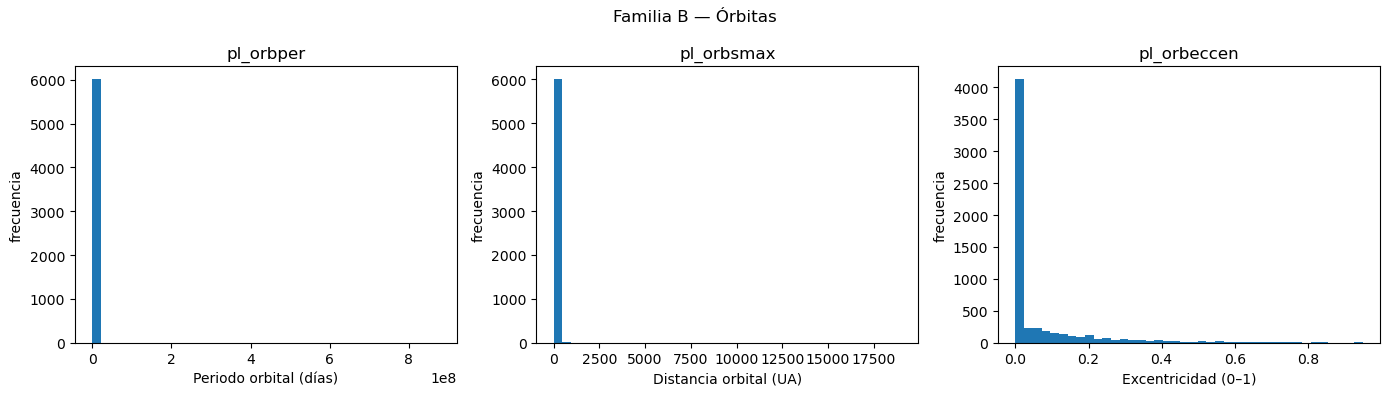

In [84]:
vars_b = ['pl_orbper','pl_orbsmax','pl_orbeccen']

units_b = {
    'pl_orbper': 'Periodo orbital (días)',
    'pl_orbsmax': 'Distancia orbital (UA)',
    'pl_orbeccen': 'Excentricidad (0–1)'
}

# Histogramas
plt.figure(figsize=(14,4))

i = 1
for col in vars_b:
    plt.subplot(1,3,i)
    plt.hist(df_work[col], bins=40)
    plt.title(col)
    plt.xlabel(units_b[col]) 
    plt.ylabel("frecuencia")
    i = i + 1

plt.suptitle("Familia B — Órbitas")
plt.tight_layout()
plt.show()


* `pl_orbper (periodo orbital)`: La distribución muestra una fuerte concentración de planetas con periodos orbitales muy cortos, lo que indica que la mayoría de exoplanetas detectados orbitan muy cerca de su estrella.

* `pl_orbsmax (distancia a la estrella)`: La distancia orbital presenta un comportamiento similar, con una gran acumulación de planetas a distancias pequeñas y algunos casos extremos a distancias muy grandes.

* `pl_orbeccen (excentricidad orbital)`: La mayor parte de los planetas presenta excentricidades bajas, concentradas cerca de cero, aunque existe una cola hacia valores altos, indicando la presencia de sistemas con órbitas significativamente elípticas.

En conjunto, las variables orbitales presentan asimetrías marcadas y escalas muy abiertas, lo que anticipa la necesidad de evitar comparaciones directas en valores brutos.

Es importante señalar que esta concentración en periodos cortos y distancias pequeñas no refleja la distribución real de exoplanetas en el universo, sino el sesgo observacional de los métodos de detección dominantes: el tránsito fotométrico y la velocidad radial favorecen la detección de planetas cercanos a su estrella. Este sesgo debe tenerse en cuenta al interpretar el ranking final

**VISUALIZACIÓN FAMILIA D — PROPIEDADES DEL PLANETA**

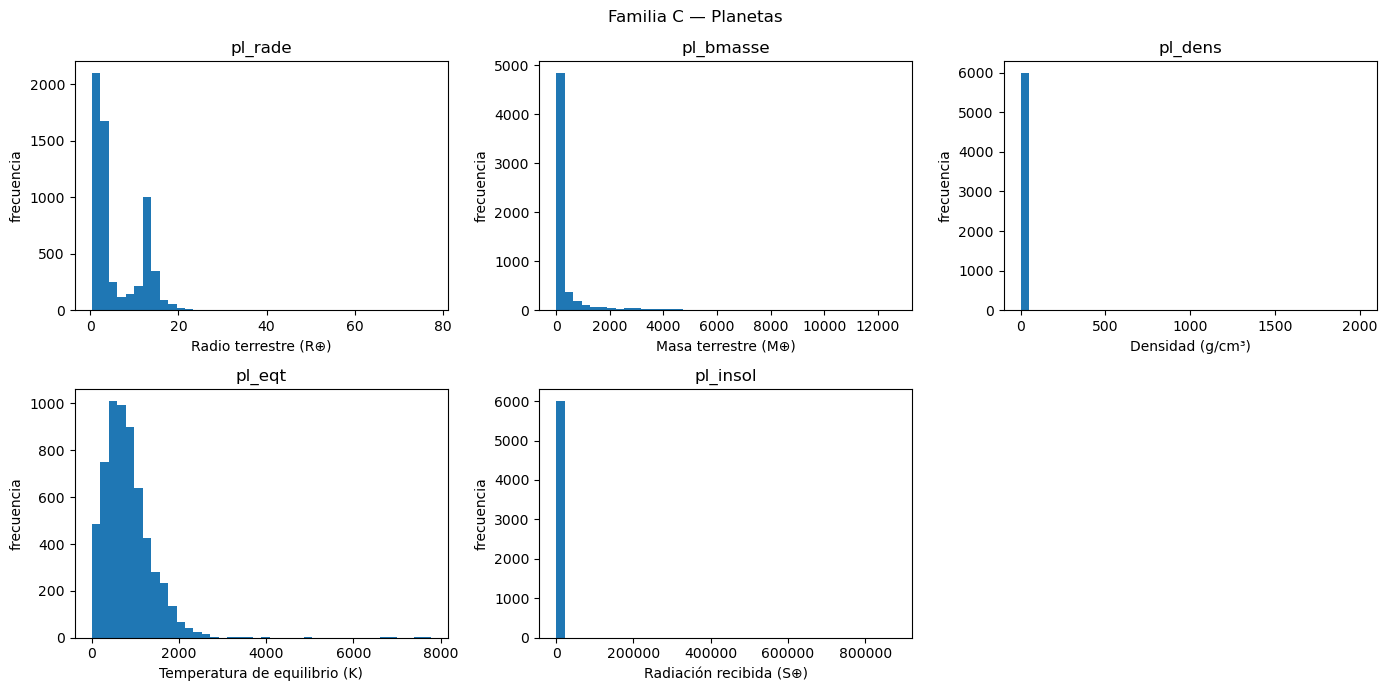

In [85]:
vars_c = ['pl_rade','pl_bmasse','pl_dens','pl_eqt','pl_insol']

units_c = {
    'pl_rade': 'Radio terrestre (R⊕)',
    'pl_bmasse': 'Masa terrestre (M⊕)',
    'pl_dens': 'Densidad (g/cm³)',
    'pl_eqt': 'Temperatura de equilibrio (K)',
    'pl_insol': 'Radiación recibida (S⊕)'
}

# Histogramas
plt.figure(figsize=(14,7))

i = 1
for col in vars_c:
    plt.subplot(2,3,i)
    plt.hist(df_work[col], bins=40)
    plt.title(col)
    plt.xlabel(units_c[col]) 
    plt.ylabel("frecuencia")
    i = i + 1

plt.suptitle("Familia C — Planetas")
plt.tight_layout()
plt.show()

* `pl_rade (radio del planeta)`: La distribución muestra una fuerte concentración de planetas con radios pequeños, lo que indica que la mayoría de exoplanetas detectados tienen tamaños comparables o moderadamente superiores al de la Tierra.

* `pl_bmasse (masa del planeta)`: La mayoría de masas se agrupan en valores bajos, lo que es coherente con un conjunto dominado por planetas pequeños/medios y con la dificultad de detectar planetas muy masivos en todos los rangos.

* `pl_dens (densidad del planeta)`: La densidad muestra una distribución muy concentrada en valores bajos, con la mayoría de planetas agrupados en un rango reducido.

* `pl_eqt (temperatura de equilibrio)`: La distribución muestra un pico en temperaturas bajas–moderadas y una cola hacia valores muy altos, lo que sugiere que la mayoría de planetas se encuentran en entornos térmicos extremos, lejos de condiciones templadas tipo Tierra.

* `pl_insol (radiación recibida)`: Se aprecia una concentración fuerte en valores bajos de insolación y una cola extremadamente larga hacia valores muy altos, indicando que muchos planetas reciben poca energía mientras que unos pocos están sometidos a irradiaciones extremas.

En conjunto, las variables planetarias combinan concentraciones fuertes en rangos bajos con colas largas hacia valores elevados, lo que obliga a tratar con cuidado la comparabilidad entre magnitudes de distinto orden.



**VISUALIZACIÓN FAMILIA E — PROPIEDADES DE LA ESTRELLA**

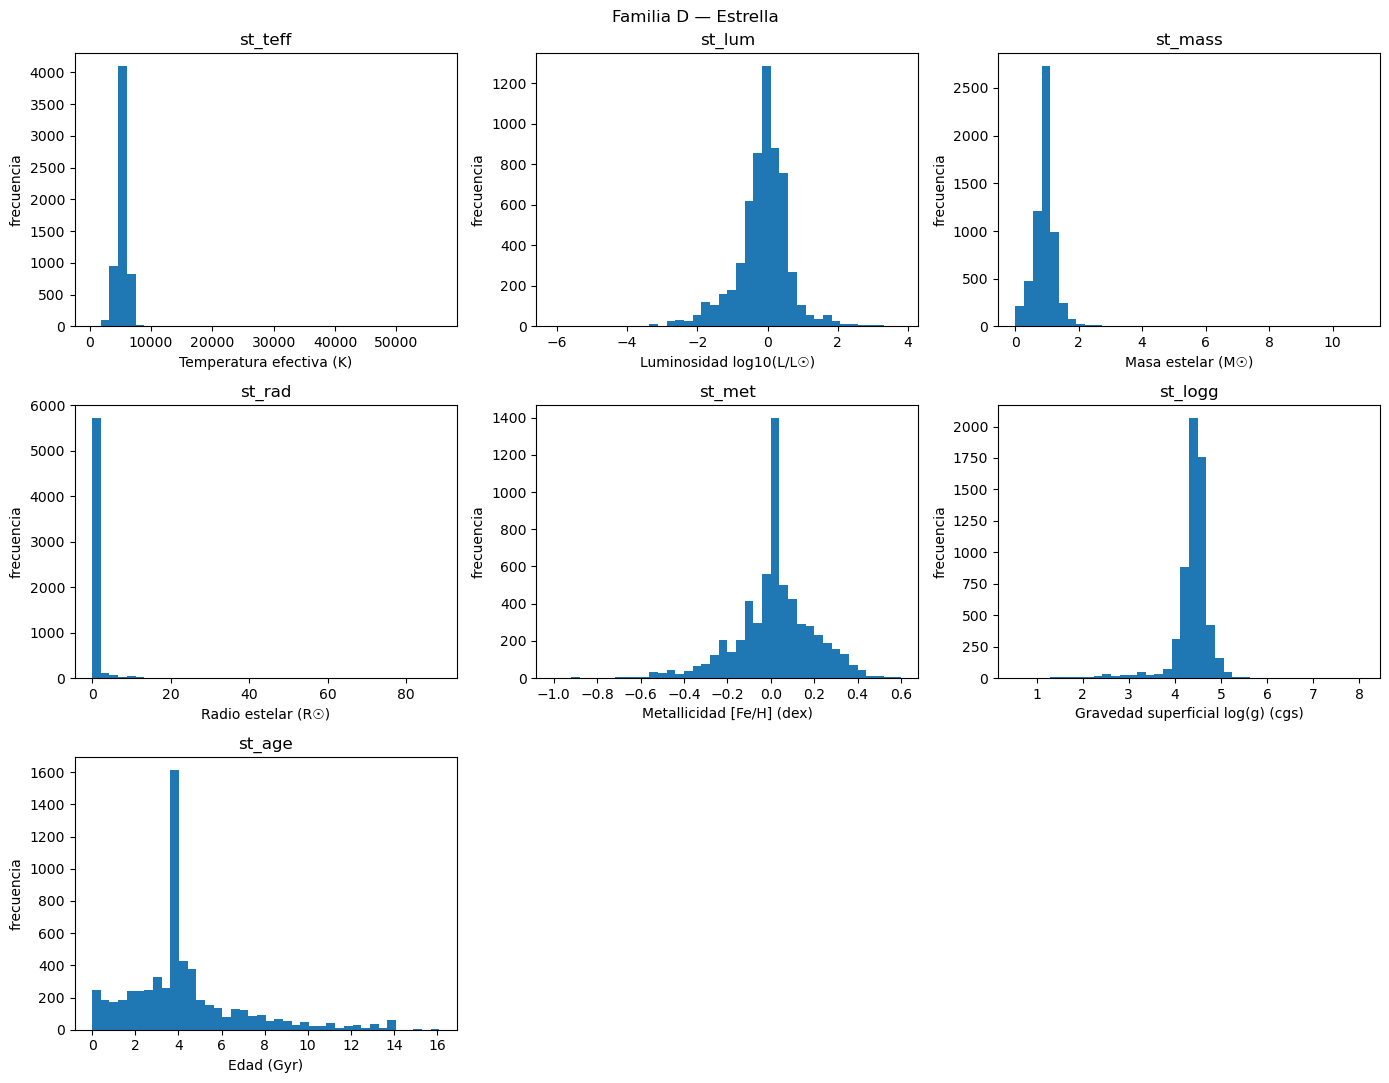

In [86]:
vars_d = ['st_teff','st_lum','st_mass','st_rad','st_met','st_logg','st_age']

units_d = {
    'st_teff': 'Temperatura efectiva (K)',
    'st_lum': 'Luminosidad log10(L/L☉)',
    'st_mass': 'Masa estelar (M☉)',
    'st_rad': 'Radio estelar (R☉)',
    'st_met': 'Metallicidad [Fe/H] (dex)',
    'st_logg': 'Gravedad superficial log(g) (cgs)',
    'st_age': 'Edad (Gyr)'
}


# Histogramas
plt.figure(figsize=(14,11))

i = 1
for col in vars_d:
    plt.subplot(3,3,i)
    plt.hist(df_work[col], bins=40)
    plt.title(col)
    plt.ylabel("frecuencia")
    plt.xlabel(units_d[col]) 
    i = i + 1

plt.suptitle("Familia D — Estrella")
plt.tight_layout()
plt.show()


* ``st_teff (temperatura efectiva)``: La distribución está fuertemente concentrada en temperaturas moderadas, indicando que la mayoría de estrellas anfitrionas son de tipo solar o más frías, con pocos casos extremos de estrellas muy calientes.

* ``st_lum (luminosidad)``: La distribución se agrupa cerca de valores centrales (en escala logarítmica), indicando que predominan estrellas con luminosidades moderadas, cercanas al orden de magnitud del Sol.

* ``st_mass (masa estelar)``: La masa se concentra alrededor de valores cercanos a 1 (en masas solares), lo que es coherente con una mayor presencia de estrellas parecidas al Sol en la muestra.

* ``st_rad (radio estelar)``: El radio muestra una fuerte concentración en valores bajos, indicando que muchas estrellas son de tamaño relativamente pequeño o moderado.

* ``st_met (metallicidad)``: La metallicidad se concentra alrededor de 0 (similar al Sol), lo que sugiere que muchas estrellas del conjunto tienen composiciones comparables a la solar.

* ``st_logg (gravedad superficial)``: La distribución se concentra en valores altos (típicos de estrellas compactas de secuencia principal), lo que apunta a un predominio de estrellas “estables” en el conjunto.

* ``st_age (edad)``: La edad muestra una distribución amplia, con concentración en edades intermedias, lo que indica una mezcla de sistemas relativamente jóvenes y maduros.

En conjunto, las variables estelares muestran distribuciones menos extremas que algunas magnitudes orbitales o planetarias, pero siguen presentando heterogeneidad suficiente como para justificar una comparación posterior basada en escalado relativo y no en valores absolutos.

#### **Visualización de Outliers**

Además de la forma general de las distribuciones, interesa comprobar si existen valores extremos con capacidad de distorsionar la comparación relativa entre exoplanetas y la referencia terrestre. La representación conjunta mediante boxplots en **escala lineal** permite detectar de forma preliminar esa presencia de valores atípicos, aunque la fuerte diferencia de rangos entre variables comprime visualmente el núcleo de muchas distribuciones.

En esta fase todavía no se toma una decisión correctiva sobre los outliers. El objetivo es primero identificarlos y valorar su peso potencial dentro del espacio de variables antes de decidir cómo tratarlos en el bloque siguiente.

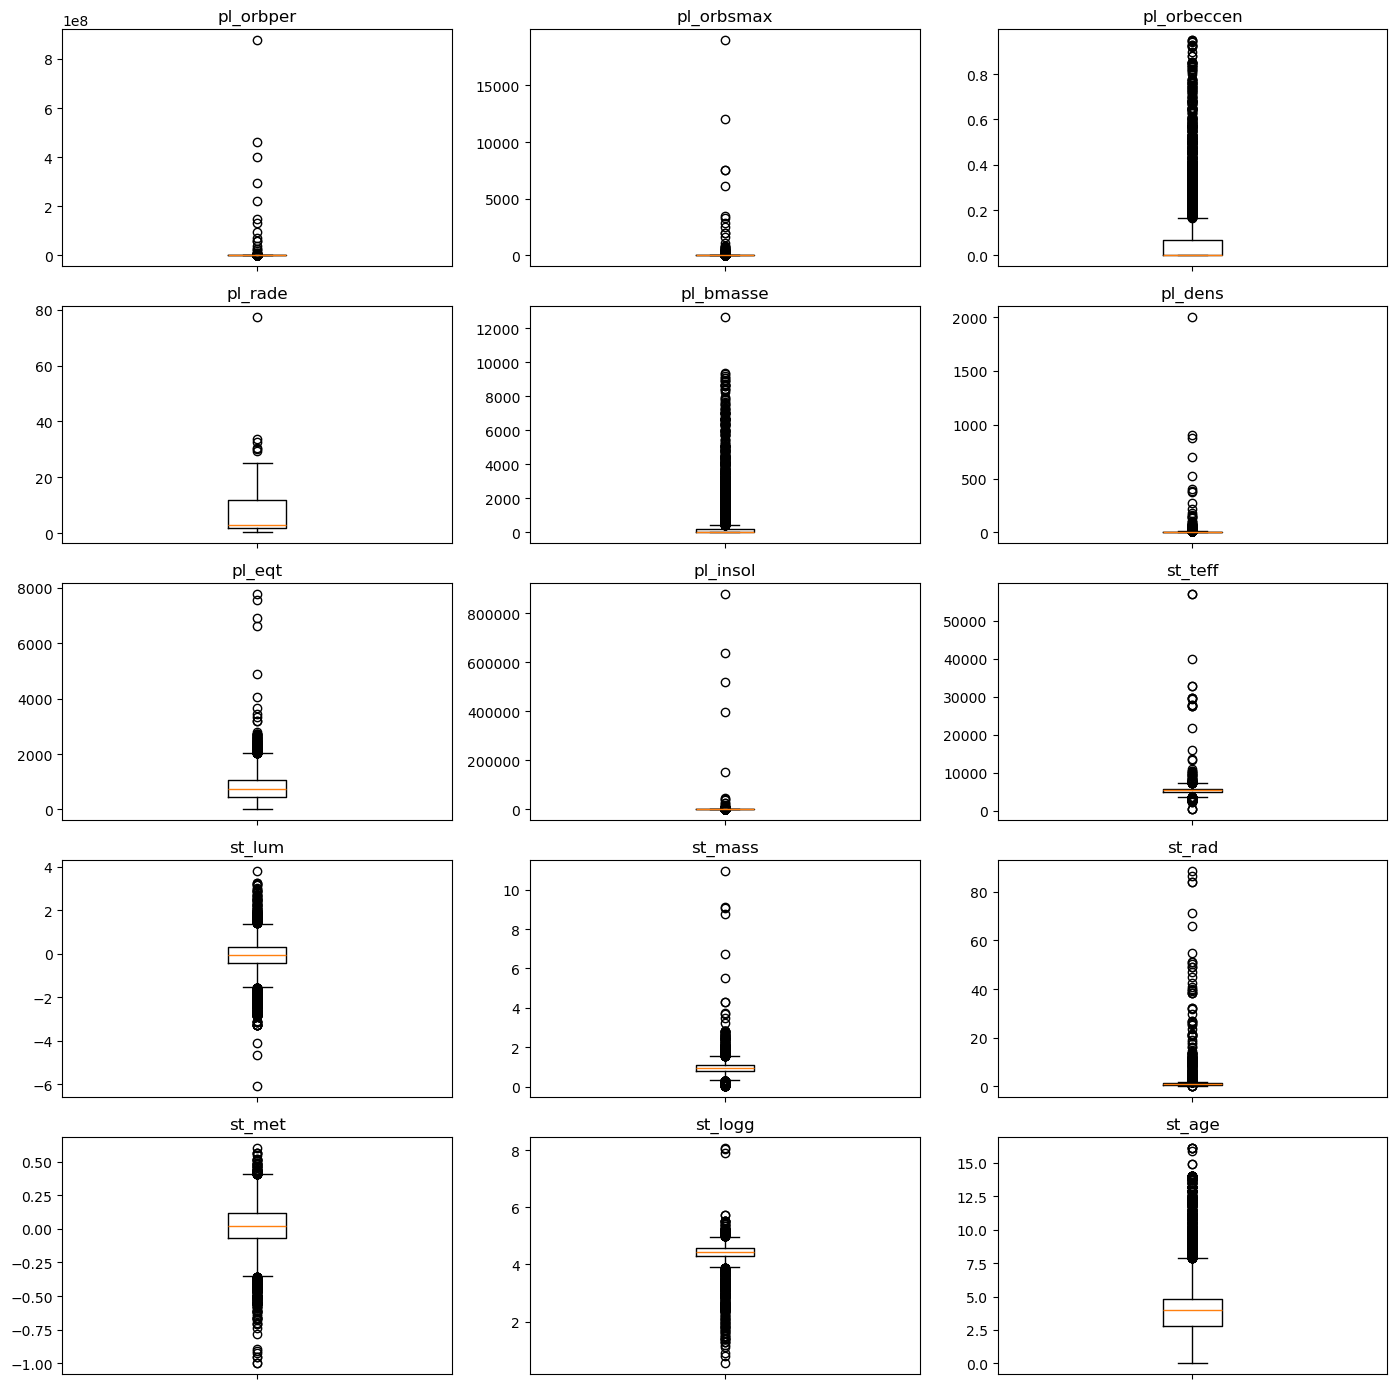

In [87]:
# Creamos una cuadrícula de subplots (5 filas x 3 columnas) para visualizar todas las variables numéricas
fig, axes = plt.subplots(5, 3, figsize=(14, 14))

# Convertimos la matriz de ejes en un array plano para poder recorrerlos fácilmente en un bucle
axes = axes.flatten()

# Índice para ir asignando cada variable a un subplot distinto
i = 0

# Recorremos todas las columnas numéricas del dataset
for col in num_cols:
    axes[i].boxplot(df_work[col]) # # Dibujamos el boxplot de cada variable
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
    i += 1

plt.tight_layout()
plt.show()


Para mejorar la legibilidad del gráfico, se utiliza una escala logarítmica simétrica (symlog) en el eje vertical. Esta escala combina un comportamiento lineal alrededor del cero con un comportamiento logarítmico para valores de mayor magnitud, permitiendo visualizar simultáneamente la distribución central y los outliers sin que el boxplot quede aplastado.

Este ajuste se emplea exclusivamente con fines de visualización y no altera los datos originales ni el pipeline posterior del análisis.

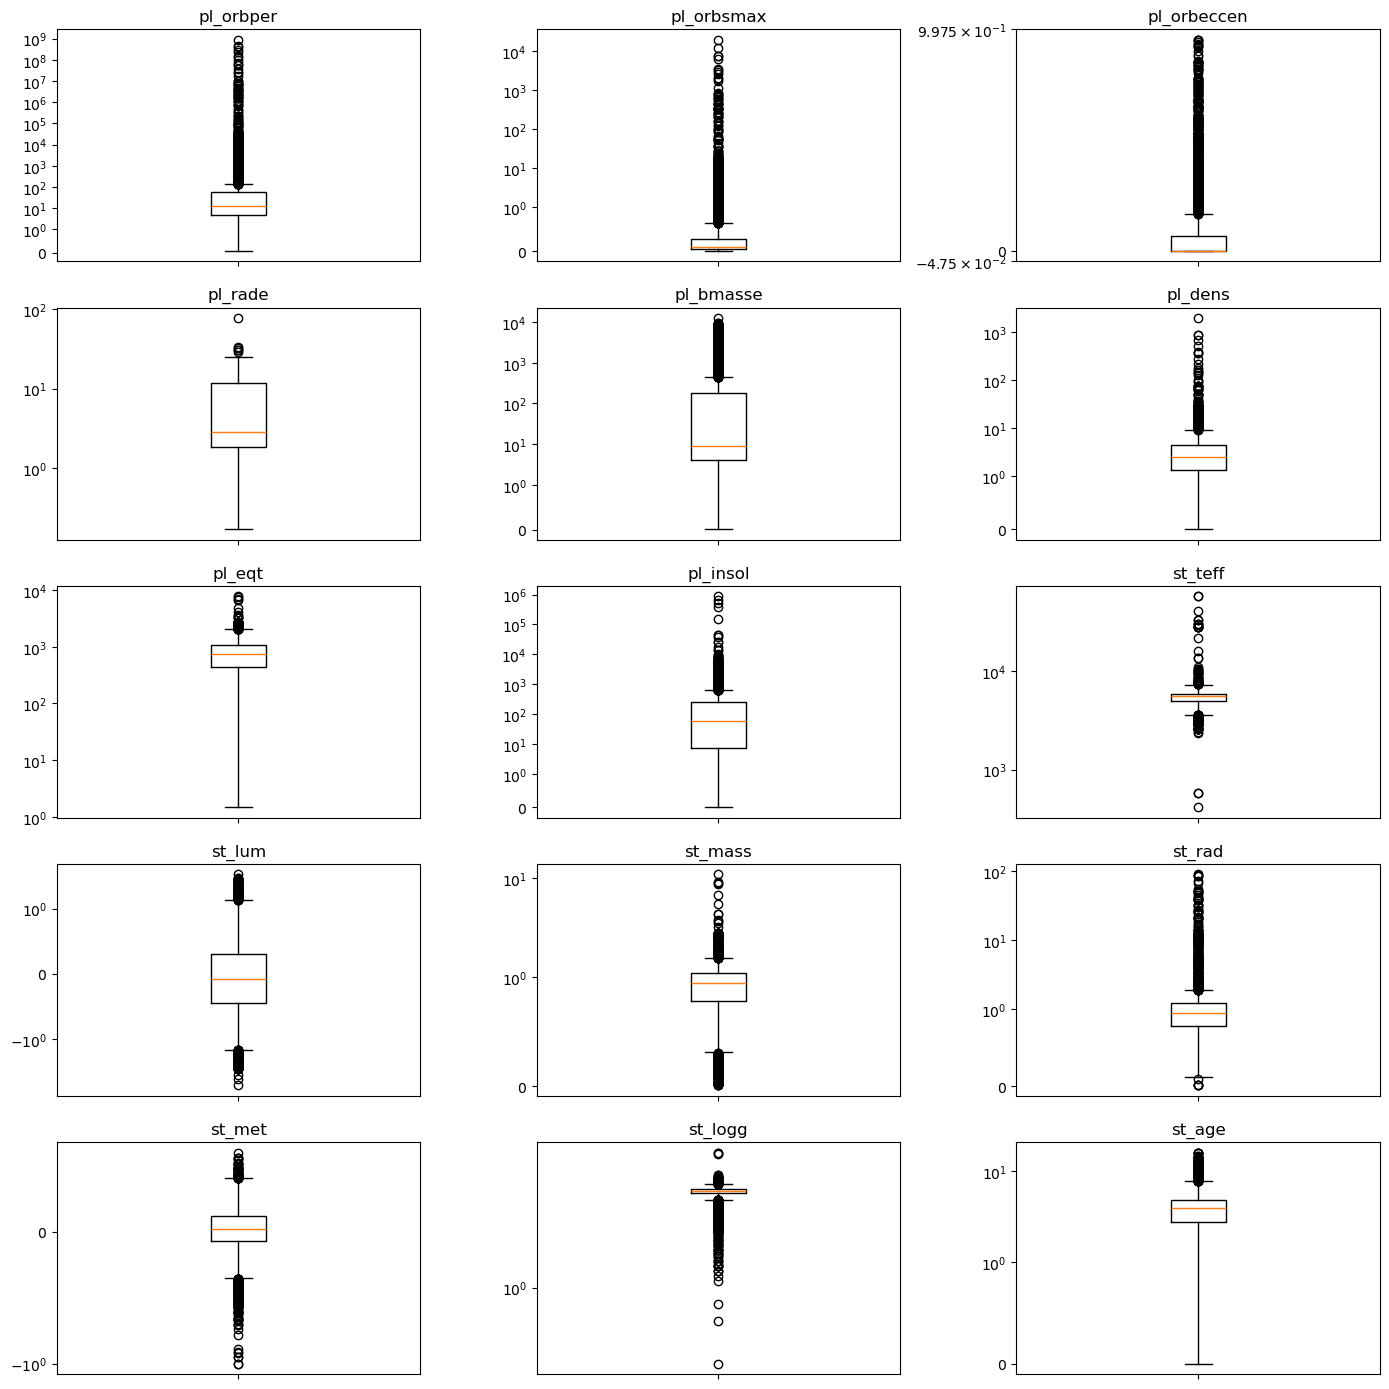

In [88]:
fig, axes = plt.subplots(5, 3, figsize=(14, 14))
axes = axes.flatten()

i = 0
for col in num_cols:
    axes[i].boxplot(df_work[col])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
    axes[i].set_yscale('symlog', linthresh=1) # Escala logarítmica simétrica en el eje Y para visualizar mejor colas largas sin aplastar la caja central
    i += 1

plt.tight_layout()
plt.show()


La representación mediante boxplots en escala logarítmica simétrica permite visualizar simultáneamente el núcleo central de las distribuciones y la presencia de valores extremos en todas las variables físicas.

La lectura conjunta de estas distribuciones confirma que el dataset no presenta un comportamiento homogéneo: varias variables muestran asimetrías marcadas, colas largas y valores extremos, especialmente en magnitudes orbitales y en algunas propiedades físicas del planeta y de la estrella. Este patrón no invalida el modelo, pero sí condiciona la forma en que debe construirse la comparación con la Tierra.

La alternativa habría sido ignorar esta heterogeneidad y pasar directamente al cálculo del índice, pero eso habría supuesto tratar como comparables variables con comportamientos distribucionales muy distintos y con diferente sensibilidad a valores extremos. En este sentido, la exploración realizada en este bloque refuerza dos decisiones metodológicas del proyecto: por un lado, la necesidad de trabajar posteriormente con un escalado relativo que haga comparables variables con órdenes de magnitud muy distintos; por otro, la conveniencia de formular el índice a partir de desviaciones relativas respecto a la referencia terrestre, en lugar de operar directamente con valores brutos.

## **5. Tratamiento de outliers**

Tras la exploración del bloque anterior, se observa un patrón común en gran parte de las magnitudes analizadas: distribuciones fuertemente asimétricas, concentradas en rangos bajos y acompañadas de colas largas hacia valores elevados. Esta estructura sugiere la presencia de observaciones extremas con capacidad de distorsionar comparaciones posteriores entre exoplanetas y la referencia terrestre.

En este punto, no basta con constatar que existen outliers: es necesario decidir cómo tratarlos dentro del modelo. Mantenerlos sin intervención implicaría permitir que unas pocas observaciones muy alejadas del grueso de la muestra condicionen escalas, dispersiones y futuras distancias relativas. Pero eliminarlos de forma directa también sería problemático, ya que supondría perder una fracción relevante del dataset y reducir la representatividad del espacio físico construido hasta ahora.

Por ello, este bloque se divide en dos pasos. Primero, se realiza un diagnóstico sistemático del fenómeno mediante el criterio de Tukey (IQR), no como método definitivo de corrección, sino como herramienta para identificar qué variables concentran más observaciones extremas. Después, a partir de ese diagnóstico, se justifica y aplica una estrategia de tratamiento que permita limitar la influencia de esos extremos sin romper la coherencia del modelo.

Antes de aplicar cualquier tratamiento, se genera una copia específica del dataset de trabajo para realizar el diagnóstico de outliers sin modificar `df_work`. El objetivo en esta fase no es corregir todavía los valores extremos, sino identificar su magnitud y distribución por variable.

In [89]:
# Creamos una copia del dataset para realizar el diagnóstico de outliers (se mantiene df_work intacto)
df_outlier_diag = df_work.copy()

# Definición de la función basada en el método de Tukey (IQR) para identificar valores atípicos en una variable numérica
def filtrar_outlier_tukey(x, threshold=1.5):

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    # Rango intercuartílico (IQR)
    iqr = q3 - q1
    print(f'[q1={q1}, q3={q3}, iqr={iqr}]')

    # Definición de los límites inferior y superior según Tukey
    floor = q1 - threshold * iqr
    ceiling = q3 + threshold * iqr
    print(f'[floor={floor}, ceiling={ceiling}]')

    # Identificación de índices cuyos valores quedan fuera de estos límites
    outlier_indices = list(x.index[(x < floor) | (x > ceiling)])
    
    # Recuperamos los valores correspondientes a dichos índices
    outlier_values = list(x[outlier_indices])

    return outlier_indices, outlier_values


In [90]:
# Diccionario para almacenar el número de outliers detectados en cada variable
n_outliers = {}

# Aplicamos el método de Tukey a todas las columnas numéricas
for col in num_cols:
    outlier_indices, outlier_values = filtrar_outlier_tukey(df_outlier_diag[col])
    
    # Guardar el número total de outliers por variable
    n_outliers[col] = len(outlier_indices)

# Convertimos el resultado en una Serie y ordenamos de mayor a menor número de outliers
pd.Series(n_outliers).sort_values(ascending=False)

[q1=4.55139967, q3=56.35850143, iqr=51.807101759999995]
[floor=-73.15925297, ceiling=134.06915407]
[q1=0.052, q3=0.286, iqr=0.23399999999999999]
[floor=-0.299, ceiling=0.637]
[q1=0.0, q3=0.066, iqr=0.066]
[floor=-0.099, ceiling=0.165]
[q1=1.82, q3=11.9, iqr=10.08]
[floor=-13.3, ceiling=27.020000000000003]
[q1=4.16, q3=179.89178, iqr=175.73178000000001]
[floor=-259.43766999999997, ceiling=443.48945000000003]
[q1=1.32, q3=4.54, iqr=3.2199999999999998]
[floor=-3.51, ceiling=9.370000000000001]
[q1=443.66768868882133, q3=1075.0, iqr=631.3323113111787]
[floor=-503.33077827794676, ceiling=2021.998466966768]
[q1=7.13, q3=261.628, iqr=254.498]
[floor=-374.61699999999996, ceiling=643.375]
[q1=4952.0, q3=5885.38, iqr=933.3800000000001]
[floor=3551.93, ceiling=7285.450000000001]
[q1=-0.43985, q3=0.297, iqr=0.73685]
[floor=-1.545125, ceiling=1.402275]
[q1=0.778, q3=1.09, iqr=0.31200000000000006]
[floor=0.30999999999999994, ceiling=1.5580000000000003]
[q1=0.781, q3=1.23, iqr=0.44899999999999995]
[fl

pl_orbper      1176
pl_orbsmax     1082
pl_bmasse       988
pl_orbeccen     872
pl_insol        826
st_age          580
st_lum          462
st_mass         441
st_logg         436
st_rad          411
st_teff         356
pl_dens         309
st_met          274
pl_eqt          136
pl_rade           6
dtype: int64

El recuento obtenido muestra que el número de registros clasificados como outliers es elevado en varias variables. Este resultado confirma que no estamos ante casos aislados o anecdóticos, sino ante un rasgo estructural del dataset que debe tratarse de forma explícita antes de construir el índice.

En este contexto, una **eliminación directa** de observaciones no resulta adecuada, ya que implicaría descartar una fracción sustancial del dataset y comprometer su representatividad global. Tampoco sería conveniente mantener intactos todos los valores extremos, porque eso permitiría que unas pocas observaciones condicionaran de forma desproporcionada las escalas y las comparaciones posteriores. También se ha considerado la **imputación directa mediante la mediana**, pero este enfoque alteraría artificialmente las distribuciones originales y homogeneizaría registros que, aun siendo extremos, siguen conteniendo información física relevante.


Para su tratamiento, se adopta una estrategia de `winsorización` basada en los límites definidos por Tukey. Este procedimiento consiste en identificar, para cada variable, un umbral inferior y superior (a partir del rango intercuartílico) y sustituir únicamente los valores que quedan fuera de dichos límites por el propio valor del umbral correspondiente. Es decir, los valores extremadamente bajos se elevan hasta el límite inferior y los extremadamente altos se reducen hasta el límite superior.

Se utiliza el umbral estándar de 1.5 veces el IQR, que en distribuciones aproximadamente normales captura más del 99% de la población dentro de los límites. Aunque las distribuciones del dataset presentan asimetrías marcadas, este umbral ofrece un punto de referencia robusto y ampliamente reconocido, sin depender de supuestos más restrictivos sobre la forma de la distribución.

Esta elección no se hace por inercia ni por comodidad técnica. Frente a la alternativa de eliminar registros, la winsorización conserva el tamaño muestral y evita empobrecer el espacio físico del modelo. Frente a la alternativa de imputar por valores centrales, preserva mejor la posición relativa de cada observación dentro de su variable. Y frente a la opción de no intervenir, limita la capacidad de unos pocos extremos para dominar escalas y comparaciones posteriores.

De este modo, no se eliminan observaciones ni se reemplazan por valores centrales, sino que se conserva cada registro dentro de su variable limitando únicamente la influencia de magnitudes extremas. La información estructural del dataset se mantiene, pero se evita que unos pocos valores muy alejados del rango típico distorsionen las métricas posteriores.

La winsorización resulta especialmente adecuada en este trabajo por tres motivos principales:

1) **Robustez y estabilidad**: al recortar solo los extremos, se reduce la sensibilidad de estadísticas como la media, la desviación típica o ciertas correlaciones frente a valores muy altos o muy bajos, estabilizando el análisis sin alterar de forma significativa el comportamiento del grueso de la distribución.

2) **Conservación de información**: a diferencia del `drop`, se preserva el tamaño muestral y la representatividad del dataset. Además, a diferencia de la imputación por mediana, no se homogeneizan artificialmente observaciones muy distintas: un planeta “más caliente” que otro sigue siéndolo, aunque su valor quede acotado dentro de un rango razonable.

3) **Coherencia con el objetivo del índice de habitabilidad**: los planetas potencialmente similares a la Tierra se concentran en regiones próximas a valores moderados de masa, temperatura o insolación. Los casos extremos, aunque físicamente reales, son candidatos poco plausibles y, si no se controla su influencia, pueden dominar artificialmente el cálculo de distancias y desviar la comparación respecto a la referencia terrestre.


La winsorización permite que el ranking final esté guiado por el patrón general del conjunto de datos y no por unos pocos valores extremos aislados.

Este enfoque representa un compromiso entre robustez estadística y preservación del significado físico de las variables. El efecto del procedimiento se valida visualmente mediante boxplots, observándose una reducción clara del impacto de colas largas sin pérdida de observaciones, preparando así el dataset para las fases posteriores de análisis y construcción del índice de habitabilidad.



Una vez justificada la estrategia, se define una función de winsorización basada en el criterio de Tukey y se aplica variable a variable sobre una copia de `df_work`. El resultado será un nuevo dataset (`df_wins`) en el que las observaciones extremas se mantienen, pero acotadas dentro de un rango consistente con la distribución central de cada magnitud.

El dataset resultante (df_wins) constituye el punto de partida para la caracterización estadística del espacio de variables y para la construcción posterior del índice de habitabilidad.

In [91]:
# Definición de una función de winsorización basada en el criterio de Tukey (IQR). En lugar de eliminar los outliers, se recortan a los límites inferior y superior

def winsorizar_tukey(x, threshold=1.5):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    
    # Rango intercuartílico
    iqr = q3 - q1

    # Definición de los límites según el método de Tukey
    floor = q1 - threshold * iqr
    ceiling = q3 + threshold * iqr

    # Aplicamos recorte (winsorización): los valores fuera del rango se sustituyen por el límite correspondiente
    return x.clip(lower=floor, upper=ceiling)


In [92]:
# Hacemos una copia del df_work 
df_wins = df_work.copy()

# Aplicamos la winsorización columna a columna sobre todas las variables numéricas
for col in num_cols:
    df_wins[col] = winsorizar_tukey(df_wins[col])


Una vez aplicada la winsorización sobre las variables numéricas, se vuelven a representar los boxplots con el objetivo de comprobar visualmente el efecto del tratamiento de outliers. Esta comparación permite verificar cómo los valores extremos han sido acotados, preservando la estructura central de las distribuciones y reduciendo la influencia de casos extremos antes de continuar con las etapas posteriores del análisis.

En este sentido, el tratamiento no pretende “normalizar” artificialmente el dataset ni eliminar toda heterogeneidad, sino evitar que la comparación posterior con la Tierra quede dominada por observaciones extremas poco representativas del grueso de la muestra. El resultado es un espacio de variables más estable para las etapas siguientes, sin perder la información esencial contenida en los registros originales.

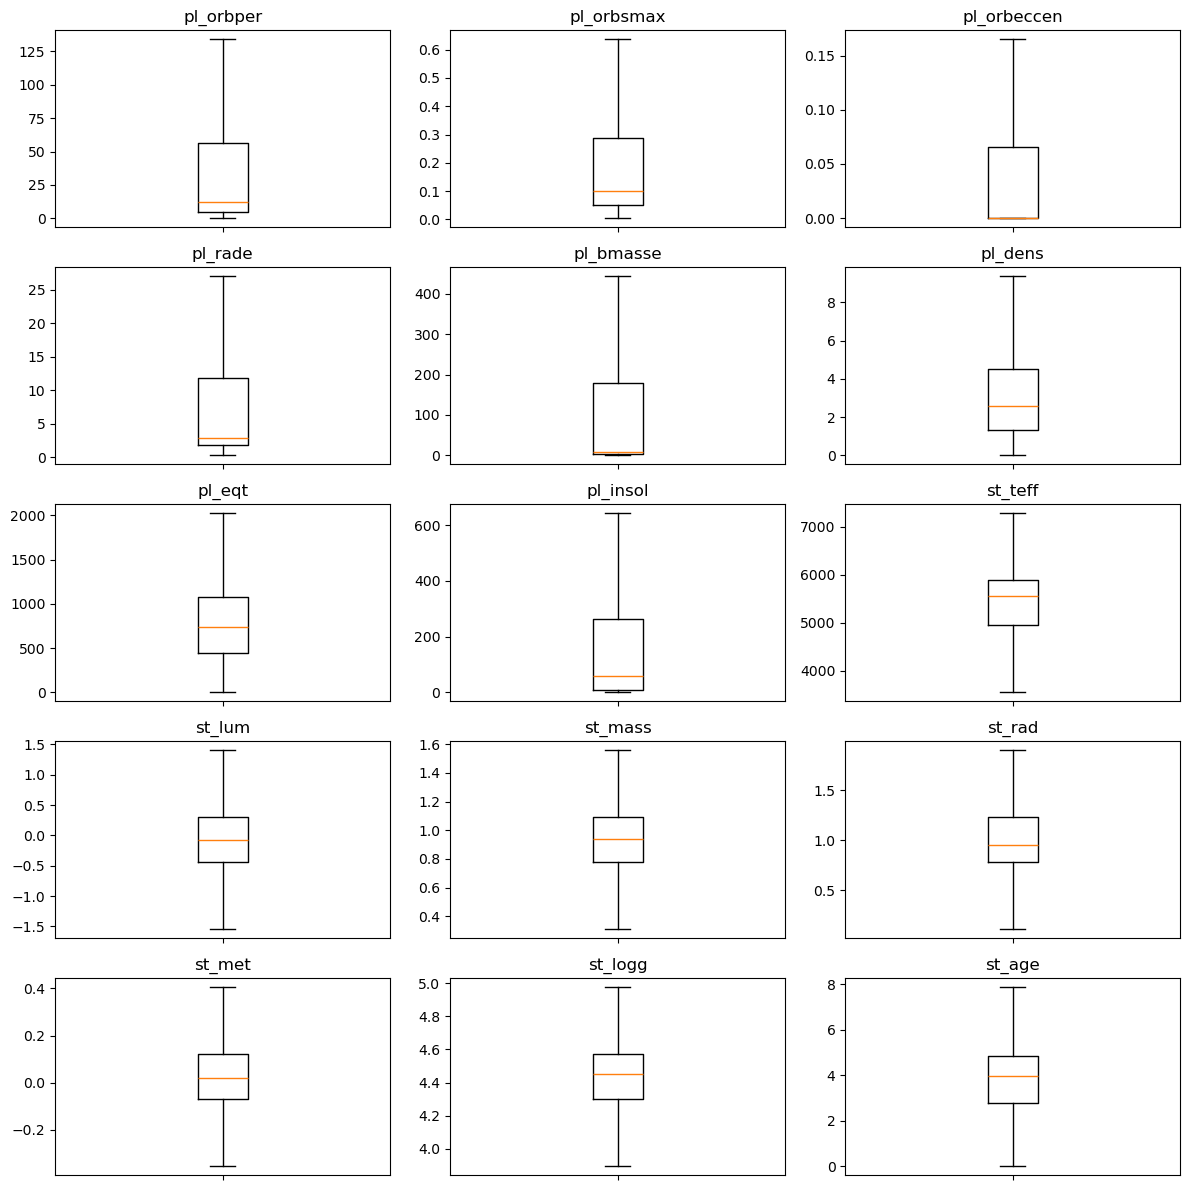

In [93]:
fig, axes = plt.subplots(5, 3, figsize=(12, 12))
axes = axes.flatten()

i = 0
for col in num_cols:
    axes[i].boxplot(df_wins[col])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
    i += 1

plt.tight_layout()
plt.show()


## **6. Construcción y Caracterización estadística del dataset final**

Una vez tratado el efecto de los valores extremos mediante winsorización, se dispone de un dataset final (`df_final`) en el que las variables físicas seleccionadas mantienen su significado original, pero con una influencia más acotada de las observaciones más extremas. En este punto, el objetivo ya no es corregir el dataset, sino caracterizar estadísticamente el espacio de variables sobre el que se construirá el índice de habitabilidad.

Este bloque cumple una función intermedia dentro del modelo. No se limita a describir el dataset por rutina, ni se introduce solo por completitud analítica: sirve para comprobar cómo ha quedado configurado el espacio físico final tras las decisiones adoptadas en los bloques anteriores y para identificar qué rasgos distribucionales siguen siendo relevantes de cara a las etapas siguientes.

Tampoco se pasa directamente al análisis de correlaciones o a la construcción del índice. Hacerlo sin esta caracterización previa dificultaría interpretar qué variables mantienen asimetrías importantes, en qué magnitudes persisten escalas muy abiertas y hasta qué punto el tratamiento de outliers ha estabilizado realmente el conjunto. Por ello, en este apartado se calculan estadísticas básicas y se comparan distribuciones clave con el fin de describir el dataset final y justificar las decisiones metodológicas posteriores.


A partir del dataset winsorizado se define `df_final`, que será el conjunto de trabajo utilizado en las siguientes etapas del proyecto. Esta copia fija explícitamente la versión final del espacio de variables tras imputación y tratamiento de outliers, evitando seguir arrastrando datasets intermedios en los análisis posteriores.

In [94]:
# Hacemos una copia con el df final 

df_final = df_wins.copy() 

In [95]:
df_final.head(5)

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,8.747818,0.081711,0.000,3.55791,12.40000,1.510,840.290000,117.826000,5525.00,-0.283820,0.95109,0.887267,0.09,4.550,3.980
1,3.19225,HD 74698 c,HD 74698,134.069154,0.637000,0.165,14.00000,126.00000,0.252,151.773321,0.088000,5783.00,0.252850,1.03900,1.333000,0.07,4.120,7.847
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,134.069154,0.637000,0.000,12.70000,443.48945,5.900,115.771234,0.032603,5554.00,-0.071600,0.45000,0.953000,0.02,4.453,3.980
3,3.12499,GJ 1061 b,GJ 1061,3.204000,0.021000,0.165,1.10000,1.37000,5.660,388.105256,3.800000,3551.93,-1.545125,0.31000,0.156000,-0.08,4.975,7.000
4,3.2527,Kepler-102 b,Kepler-102,5.286965,0.055210,0.100,0.46000,1.10000,9.370,857.000000,90.000000,4909.00,-0.584360,0.80300,0.724000,0.11,4.600,1.100


### Comparación antes y después del tratamiento de outliers

Una vez completado el proceso de tratamiento de **NaN** y **outliers**, se comparan las estadísticas descriptivas del conjunto tras la imputación (`df_work`) y del conjunto definitivo tras la winsorización (`df_final`). El objetivo de esta comparación es evaluar de forma explícita el impacto del tratamiento de valores extremos sobre las medidas de centralidad y dispersión, y verificar si dicho proceso actúa principalmente sobre las colas de las distribuciones.

Esta comparación es importante porque la winsorización no se introduce como una transformación cosmética, sino como una decisión orientada a estabilizar el espacio de variables antes de construir el índice. Frente a la alternativa de asumir que el recorte de extremos “mejora” automáticamente el dataset, aquí se comprueba de forma explícita qué cambia realmente y qué permanece estable tras el tratamiento.

In [96]:
# Antes del tratamiento de winsorizacion
desc_before = df_work[num_cols].describe().T

# Despues del tratamiento de winsorizacion
desc_after  = df_final[num_cols].describe().T

pd.concat({"df_work (antes winsorización)": desc_before, "df_final (después winsorización)": desc_after}, axis=1)

df_work (antes winsorización)                               \
                                    count           mean           std   
pl_orbper                          6021.0  506801.176508  1.493297e+07   
pl_orbsmax                         6021.0      14.905010  3.433862e+02   
pl_orbeccen                        6021.0       0.067133  1.431533e-01   
pl_rade                            6021.0       5.793161  5.337645e+00   
pl_bmasse                          6021.0     385.408151  1.106467e+03   
pl_dens                            6021.0       4.879719  3.450930e+01   
pl_eqt                             6021.0     812.477240  5.229454e+02   
pl_insol                           6021.0     782.286152  1.648455e+04   
st_teff                            6021.0    5417.099583  1.715163e+03   
st_lum                             6021.0      -0.132183  7.589986e-01   
st_mass                            6021.0       0.942274  4.208073e-01   
st_rad                             6021.0       1.482720  3.863681e+00   
st_met                             6021.0       0.015664  1.800273e-01   
st_logg                            6021.0       4.386424  4.299426e-01   
st_age                             6021.0       4.284589  2.659702e+00   

                                                                  \
                      min          25%          50%          75%   
pl_orbper    9.070629e-02     4.551400    12.309681    56.358501   
pl_orbsmax   3.856670e-03     0.052000     0.100000     0.286000   
pl_orbeccen  0.000000e+00     0.000000     0.000000     0.066000   
pl_rade      3.098000e-01     1.820000     2.830000    11.900000   
pl_bmasse    2.000000e-02     4.160000     9.100000   179.891780   
pl_dens      5.100000e-03     1.320000     2.560000     4.540000   
pl_eqt       1.481161e+00   443.667689   733.000000  1075.000000   
pl_insol     3.289901e-10     7.130000    57.630734   261.628000   
st_teff      4.150000e+02  4952.000000  5554.000000  5885.380000   
st_lum      -6.090000e+00    -0.439850    -0.071600     0.297000   
st_mass      9.400000e-03     0.778000     0.940000     1.090000   
st_rad       1.150000e-02     0.781000     0.953000     1.230000   
st_met      -1.000000e+00    -0.070000     0.020000     0.120000   
st_logg      5.410000e-01     4.300000     4.453000     4.570000   
st_age       0.000000e+00     2.800000     3.980000     4.830000   

                          df_final (después winsorización)               \
                      max                            count         mean   
pl_orbper    8.768941e+08                           6021.0    39.935950   
pl_orbsmax   1.900000e+04                           6021.0     0.210623   
pl_orbeccen  9.500000e-01                           6021.0     0.038713   
pl_rade      7.734210e+01                           6021.0     5.781285   
pl_bmasse    1.265150e+04                           6021.0   111.056395   
pl_dens      2.000000e+03                           6021.0     3.127858   
pl_eqt       7.777781e+03                           6021.0   801.980014   
pl_insol     8.782908e+05                           6021.0   176.102865   
st_teff      5.700000e+04                           6021.0  5356.568592   
st_lum       3.800000e+00                           6021.0    -0.118290   
st_mass      1.094000e+01                           6021.0     0.927113   
st_rad       8.847500e+01                           6021.0     1.026750   
st_met       6.000000e-01                           6021.0     0.019802   
st_logg      8.070000e+00                           6021.0     4.429461   
st_age       1.610000e+01                           6021.0     4.035104   

                                                                              \
                    std           min          25%          50%          75%   
pl_orbper     50.760766  9.070629e-02     4.551400    12.309681    56.358501   
pl_orbsmax     0.223685  3.856670e-03     0.052000     0.100000     0.286000   


La comparación de los estadísticos descriptivos antes y después del proceso de winsorización muestra que las medianas y los cuartiles permanecen prácticamente invariantes en la mayoría de variables. 

* pl_orbper: misma mediana ≈ 12.3
* pl_orbsmax: misma mediana = 0.1
* pl_rade: misma mediana = 2.83
* pl_bmasse: misma mediana = 9.1
* pl_eqt: misma mediana = 733
* st_mass: misma mediana = 0.94
* st_logg: misma mediana = 4.453


Esto indica que la estructura central de las distribuciones se conserva incluso después del tratamiento de outliers.

En cambio, los cambios más visibles se concentran en los valores máximos y en la desviación estándar, especialmente en variables con colas largas como el periodo orbital, la masa planetaria o la insolación. Este patrón confirma que la winsorización actúa principalmente sobre los extremos y no sobre el núcleo representativo de la muestra.

Esta lectura es importante porque descarta dos interpretaciones incorrectas: por un lado, que el tratamiento de outliers haya alterado artificialmente el comportamiento general del dataset; por otro, que dejar intactos los valores extremos fuera inocuo para el modelo. El resultado final es un conjunto de datos más estable para el cálculo posterior del índice, sin perder la estructura física central de las variables.

### Comparación media–mediana y análisis de asimetría

Con el objetivo de evaluar el grado de asimetría de las distribuciones tras el tratamiento de valores extremos mediante winsorización, se compara a continuación la media y la mediana de cada variable. Esta comparación permite identificar qué variables mantienen todavía colas largas o distribuciones sesgadas, ya que diferencias marcadas entre ambos estadísticos son indicativas de asimetría.

Este análisis no sustituye a la inspección visual realizada previamente, sino que la refuerza con una medida más sintética del sesgo distribucional. Además, permite justificar por qué en las etapas posteriores no conviene trabajar directamente con valores brutos ni asumir que todas las variables son comparables en escala y comportamiento.

Frente a la alternativa de resumir el dataset únicamente con medias o estadísticos globales, la comparación media–mediana permite detectar de forma más clara dónde persisten asimetrías relevantes para el modelo y en qué variables será especialmente importante utilizar un escalado relativo.

In [97]:
round(df_final.describe().T[["mean","50%"]], 2)

,mean,50%
pl_orbper,39.94,12.31
pl_orbsmax,0.21,0.10
pl_orbeccen,0.04,0.00
pl_rade,5.78,2.83
pl_bmasse,111.06,9.10
pl_dens,3.13,2.56
pl_eqt,801.98,733.00
pl_insol,176.10,57.63
st_teff,5356.57,5554.00
st_lum,-0.12,-0.07


Al comparar la media con la mediana se observa que, incluso después del recorte de valores extremos mediante winsorización, varias variables planetarias siguen presentando diferencias importantes entre ambos estadísticos. En particular, el **periodo orbital**, la **masa** del planeta, la **insolación** y el **radio** planetario muestran medias claramente superiores a sus medianas, lo que indica la persistencia de colas derechas largas asociadas a un pequeño número de planetas con valores muy elevados.

Esto sugiere que, aunque la winsorización ha reducido la influencia de los casos más extremos, la asimetría del conjunto de exoplanetas no desaparece, sino que sigue formando parte de la estructura física del problema. Por tanto, no sería adecuado interpretar el dataset final como un espacio homogéneo ni asumir que todas las variables pueden combinarse directamente sin una etapa posterior de reescalado.

En contraste, las **variables estelares** presentan medias mucho más próximas a sus medianas. Esta mayor homogeneidad puede relacionarse tanto con la propia física estelar —que impone relaciones más estables entre propiedades— como con el modo en que estos parámetros suelen estimarse observacionalmente. En conjunto, este patrón refuerza la idea de que el modelo combina familias de variables con comportamientos distribucionales distintos y que, por tanto, la comparación con la Tierra deberá construirse sobre desviaciones relativas y no sobre magnitudes absolutas.

## **7. Análisis de Correlaciones**

Una vez construido y caracterizado el dataset final, se analizan las relaciones entre las variables físicas seleccionadas mediante una matriz de correlación. Este análisis permite identificar patrones de co-variación coherentes con la física del sistema planeta–estrella y comprender cómo se organizan conjuntamente los distintos parámetros orbitales, planetarios y estelares.

El objetivo de este bloque no es seleccionar variables para eliminarlas ni reducir automáticamente la dimensionalidad del modelo. Tampoco se utiliza la correlación como criterio para simplificar el espacio físico antes del índice. Su función aquí es otra: verificar que las dependencias observadas son consistentes con la estructura física del problema y aportar contexto interpretativo antes de construir la medida de similitud con la Tierra.

En otras palabras, este bloque no busca “limpiar” redundancias por rutina estadística, sino comprobar si el espacio de variables definido en los bloques anteriores presenta relaciones esperables y defendibles desde el punto de vista físico.

Como primer paso, se calcula la matriz de correlación entre las variables numéricas del dataset final. Esta tabla permite inspeccionar directamente la intensidad y el signo de las relaciones lineales entre pares de variables antes de pasar a una representación visual más sintética.

In [98]:
df_final[num_cols].corr()


,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
pl_orbper,1.000000,0.992814,0.366592,0.447333,0.507963,-0.004128,-0.612182,-0.492896,0.025137,0.236470,0.048309,0.220907,-0.006439,-0.244038,-0.025003
pl_orbsmax,0.992814,1.000000,0.368408,0.455034,0.518043,-0.004315,-0.612117,-0.499696,0.060691,0.275197,0.083070,0.257459,0.001384,-0.280275,-0.029996
pl_orbeccen,0.366592,0.368408,1.000000,0.399258,0.428950,0.007249,-0.203283,-0.160815,-0.069981,0.117118,0.149788,0.194464,0.076254,-0.195919,0.082985
pl_rade,0.447333,0.455034,0.399258,1.000000,0.837581,-0.291891,0.055833,0.109561,0.188084,0.369917,0.318665,0.439589,0.190004,-0.423315,-0.035423
pl_bmasse,0.507963,0.518043,0.428950,0.837581,1.000000,0.039358,-0.023202,0.029828,0.122672,0.346021,0.298377,0.397750,0.153984,-0.377164,-0.067168
pl_dens,-0.004128,-0.004315,0.007249,-0.291891,0.039358,1.000000,0.004860,-0.009872,-0.122656,-0.081889,-0.073844,-0.102311,-0.104902,0.105347,-0.044037
pl_eqt,-0.612182,-0.612117,-0.203283,0.055833,-0.023202,0.004860,1.000000,0.874789,0.339368,0.294229,0.385216,0.304494,0.098435,-0.270234,-0.053794
pl_insol,-0.492896,-0.499696,-0.160815,0.109561,0.029828,-0.009872,0.874789,1.000000,0.361088,0.318163,0.367367,0.312891,0.138440,-0.279274,-0.014139
st_teff,0.025137,0.060691,-0.069981,0.188084,0.122672,-0.122656,0.339368,0.361088,1.000000,0.758049,0.692490,0.610936,0.141769,-0.568142,-0.121595
st_lum,0.236470,0.275197,0.117118,0.369917,0.346021,-0.081889,0.294229,0.318163,0.758049,1.000000,0.835768,0.890887,0.123723,-0.860900,-0.075210


### **Correlaciones más relevantes identificadas**

La matriz de correlación muestra relaciones fuertes y consistentes entre varias variables físicas del sistema planeta–estrella. Estas relaciones no se interpretan aquí como un problema que obligue a eliminar variables, sino como una confirmación de que el espacio construido en los bloques anteriores refleja dependencias físicas reales.

Las correlaciones más elevadas ya aparecen claramente en esta primera tabla:

* Periodo orbital (**pl_orbper**) – distancia orbital/semieje mayor (**pl_orbsmax**): r = 0.99
* Temperatura de equilibrio (**pl_eqt**) – insolación (**pl_insol**): r = 0.87
* Radio planetario (**pl_rade**) – masa planetaria (**pl_bmasse**): r = 0.84
* Radio estelar (**st_rad**) – masa estelar (**st_mass**): r ≈ 0.84
* Luminosidad (**st_lum**) – radio estelar (**st_rad**): r ≈ 0.89
* Gravedad superficial (**st_logg**) – radio estelar (**st_rad**): r = −0.95

Estas magnitudes no se relacionan de forma casual: describen directamente mecanismos físicos del sistema.

En concreto:

* La correlación entre **periodo orbital** y **distancia** indica que ambas variables están conectadas por la escala orbital del sistema, algo coherente con la dinámica kepleriana.
* La correlación entre **insolación** y **temperatura de equilibrio** refleja una relación energética directa: cuanto mayor es la radiación recibida por el planeta, mayor es su temperatura estimada.
* La correlación entre **radio** y **masa planetaria** muestra que los planetas grandes tienden a ser también más masivos, aunque no perfectamente, debido a diferencias de composición y densidad.

En el bloque estelar:

* **Masa estelar** y **radio estelar** aparecen fuertemente asociados, reflejando relaciones estructurales típicas de estrellas de secuencia principal.
* La **luminosidad** aumenta con el radio y la temperatura efectiva, tal como cabría esperar físicamente.
* La **gravedad superficial** disminuye cuando el radio aumenta, generando correlaciones negativas intensas.

La alternativa habría sido interpretar estas correlaciones como una señal para eliminar variables redundantes o simplificar el modelo antes del índice. Sin embargo, en este proyecto se opta por conservarlas porque, aunque estén relacionadas, cada una aporta una dimensión física concreta del sistema y su inclusión forma parte del planteamiento explícito del modelo.

#### **Visualización de la matriz de correlación**

Dado que la matriz de correlación en formato tabular puede resultar poco intuitiva cuando el número de variables es elevado, se representa a continuación mediante un mapa de calor (heatmap). Esta visualización permite identificar de forma inmediata patrones de correlación positiva y negativa, así como posibles bloques estructurales entre variables planetarias y estelares.

El heatmap no se utiliza aquí como una herramienta para decidir recortes automáticos del modelo, sino como una forma de leer visualmente la arquitectura interna del espacio físico construido. Su valor está en mostrar de un vistazo qué grupos de variables se mueven conjuntamente y qué dependencias pueden resultar relevantes para interpretar después la construcción del índice.

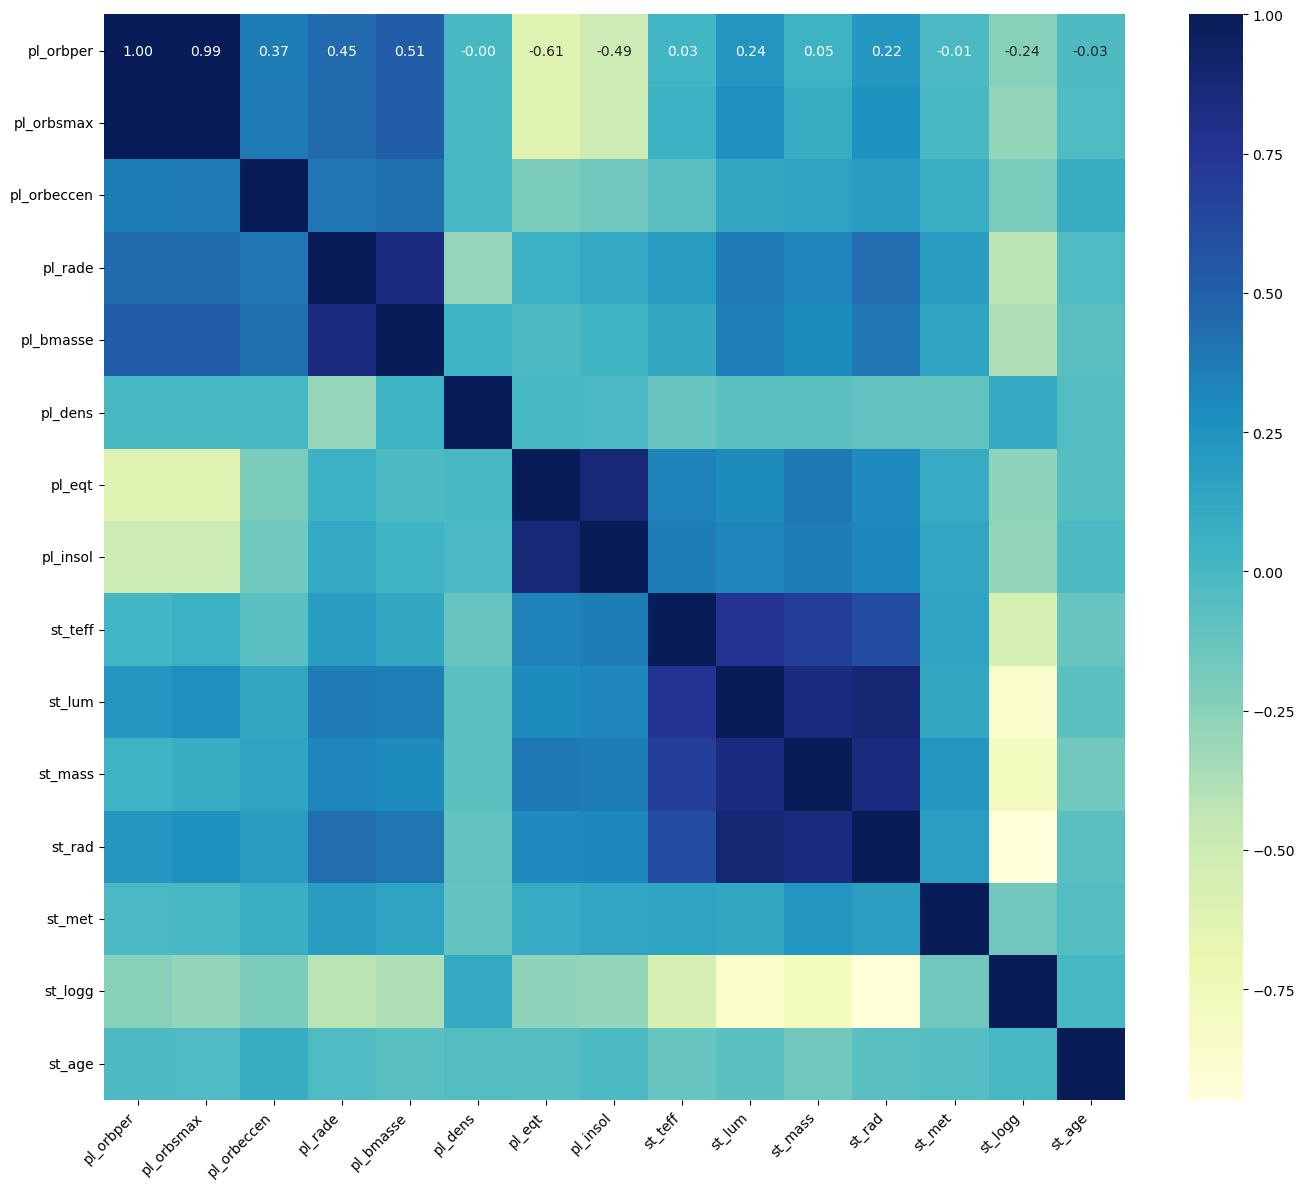

In [99]:
corr = df_final[num_cols].corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f" # Mostramos solo 2 decimales
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


### **Interpretación del Heatmap**

El mapa de calor permite pasar de una lectura numérica puntual a una visión estructural del espacio de variables, mostrando de forma inmediata qué grupos de parámetros se mueven conjuntamente y cuáles permanecen relativamente independientes. Esta lectura global es importante porque permite verificar que el modelo no está construido sobre relaciones arbitrarias, sino sobre un sistema de dependencias que refleja la física subyacente del problema.

A nivel visual se identifican claramente **cuatro bloques principales**:

#### ``Bloque estelar``

Las variables estelares:
* **Masa** (**st_mass**)
* **Radio** (**st_rad**)
* **Temperatura efectiva** (**st_teff**) 
* **luminosidad** (**st_lum**)

forman un bloque compacto de correlaciones positivas.

Esto indica que estas propiedades no varían de forma aislada:

* cuando aumenta la masa de la estrella, también aumenta su radio
* una estrella más grande tiende a ser más caliente
* y ambas cosas se traducen en mayor luminosidad.

Dentro de este mismo bloque:
 
* La **gravedad superficial** (**st_logg**) 

donde aparecen con correlaciones negativas intensas frente a **radio** y **luminosidad**, reflejando que estrellas más grandes y luminosas presentan menor gravedad superficial, lo cual es coherente con su definición física.


#### ``Bloque energético planeta–estrella``

La **temperatura de equilibrio del planeta** (**pl_eqt**) y la **insolación** (**pl_insol**) aparecen como un subbloque claramente definido.

Ambas variables se mueven en paralelo y además se conectan visualmente con las propiedades energéticas de la estrella (st_teff y st_lum), mostrando que:

* estrellas más calientes y luminosas envían más radiación
* los planetas reciben más energía
* y su temperatura de equilibrio aumenta en consecuencia.

Este bloque representa el canal energético completo desde la estrella hasta el planeta.

#### ``Bloque orbital``

El **periodo orbital** (**pl_orbper**) y la **distancia media a la estrella** (**pl_orbsmax**) forman un patrón muy marcado, mientras que su relación con **pl_eqt** y **pl_insol** aparece con signo opuesto.

Visualmente esto se traduce en que:

* planetas más lejanos (mayor pl_orbsmax) orbitan más lentamente (mayor pl_orbper)
* reciben menos energía, resultando en menores temperaturas de equilibrio.

La **excentricidad orbital** (**pl_orbeccen**) presenta colores más suaves frente al resto de variables, lo que indica que la forma de la órbita tiene un impacto secundario comparado con la distancia media.

#### ``Bloque planetario estructural``

El radio del planeta (**pl_rade**) y su masa (**pl_bmasse**) aparecen acoplados, mientras que la densidad (**pl_dens**) se mantiene visualmente mucho más independiente.

Esto sugiere que:

* tamaño y masa describen el volumen global del planeta
* mientras que la densidad aporta información complementaria sobre su composición interna y no simplemente sobre su escala.

#### ``Conclusiones Heatmap``

El heatmap muestra que el dataset está organizado alrededor de tres sistemas físicos acoplados:

* estructura estelar
* canal energético estrella–planeta
* geometría orbital

con un bloque planetario que captura tamaño, masa y composición. 

Esta visualización confirma que las variables seleccionadas representan procesos físicos distintos pero conectados, proporcionando una base coherente para la construcción posterior del índice de habitabilidad.

En conjunto, el heatmap confirma que el espacio de variables no está formado por magnitudes aisladas, sino por bloques físicos parcialmente conectados. Esta estructura no invalida el modelo ni obliga a simplificarlo automáticamente, pero sí aporta contexto para interpretar después cómo se agregan las distintas dimensiones en la construcción del índice de habitabilidad.

### **Identificación de pares con correlación elevada (|r| ≥ 0.70)**

Para disponer de una referencia rápida dentro del conjunto de relaciones observadas, se recogen a continuación los pares de variables con correlación elevada. Este resumen permite localizar de un vistazo qué parámetros están más estrechamente vinculados y actúa como apoyo al heatmap.

Su función aquí no es decidir eliminaciones automáticas ni imponer una selección adicional de variables. Al contrario, sirve para hacer explícitas las dependencias más intensas del sistema y dejar documentado qué relaciones deberán tenerse en cuenta al interpretar posteriormente el índice de habitabilidad y sus resultados.

In [100]:
# Matriz de correlación (Pearson) entre las variables numéricas
corr = df_final[num_cols].corr()

umbral = 0.70  # a partir de este valor (en valor absoluto) consideramos correlación "alta"

# Nos quedamos solo con la mitad superior (sin la diagonal) para evitar duplicados
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

# Convertimos la matriz a formato "lista de pares" y filtramos por |r| >= umbral
pares_altos = (
    corr.where(mask)                 # deja NaN en la parte que no queremos
        .stack()                     # pasa a formato largo: (var_1, var_2) -> r
        .reset_index(name="r")       # lo convierte en DataFrame con columna 'r'
)

pares_altos["abs_r"] = pares_altos["r"].abs()                 # añadimos el valor absoluto
pares_altos = pares_altos[pares_altos["abs_r"] >= umbral]     # filtramos por el umbral
pares_altos = pares_altos.sort_values("abs_r", ascending=False).reset_index(drop=True)

pares_altos.rename(columns={"level_0": "var_1", "level_1": "var_2"}, inplace=True)

pares_altos


,var_1,var_2,r,abs_r
0,pl_orbper,pl_orbsmax,0.992814,0.992814
1,st_rad,st_logg,-0.949039,0.949039
2,st_lum,st_rad,0.890887,0.890887
3,pl_eqt,pl_insol,0.874789,0.874789
4,st_lum,st_logg,-0.860900,0.860900
5,st_mass,st_rad,0.844896,0.844896
6,pl_rade,pl_bmasse,0.837581,0.837581
7,st_lum,st_mass,0.835768,0.835768
8,st_mass,st_logg,-0.778570,0.778570
9,st_teff,st_lum,0.758049,0.758049


## **8. Definición formal del índice de habitabilidad**

El concepto de habitabilidad no es una magnitud directamente observable y depende del marco científico adoptado. Dado que el dataset no proporciona etiquetas explícitas de “planeta habitable” y que la mayoría de propiedades planetarias son estimaciones indirectas (proxies físicos), la habitabilidad no puede tratarse como una variable objetiva ni como un problema de clasificación supervisada.

Tampoco resulta adecuado formular el problema mediante reglas binarias o umbrales rígidos del tipo “habitable / no habitable”, ya que eso obligaría a fijar cortes arbitrarios sobre variables cuya contribución real es gradual y dependiente del contexto físico. Del mismo modo, un enfoque puramente no supervisado permitiría agrupar planetas por similitud interna, pero no ofrecería una medida interpretable de cercanía a la única referencia físicamente conocida: la Tierra.

Por este motivo, se adopta un enfoque relativo. Se asume que el único caso confirmado de planeta habitable es la Tierra y, bajo esta premisa, la forma más razonable de aproximar la habitabilidad consiste en evaluar hasta qué punto cada exoplaneta se parece físicamente a ella dentro del espacio de variables definido en los bloques anteriores.

Este planteamiento permite evitar etiquetas inexistentes, descarta umbrales artificiales y formula el problema como una medida continua de similitud física. El objetivo no es afirmar la existencia de vida, sino construir un criterio cuantitativo, reproducible e interpretable para priorizar exoplanetas potencialmente compatibles con condiciones terrestres.

Bajo este marco, el índice de habitabilidad se define formalmente como:

$$
H_i \;=\; \frac{1}{\,1 + d\!\left(\mathbf{x}_i,\mathbf{x}_\oplus\right)\,}
$$

donde:

- $\mathbf{x}_i$ es el **vector de variables físicas del planeta $i$** (parámetros orbitales, planetarios y estelares seleccionados).

- $\mathbf{x}_\oplus$ es el **vector Tierra**, construido con los valores físicos de referencia del sistema Tierra–Sol en las mismas unidades que el dataset.

- $d(\mathbf{x}_i,\mathbf{x}_\oplus)$ es la **distancia (disimilitud) entre el planeta $i$ y la Tierra** en el espacio multidimensional definido por esas variables.

- $H_i$ es el **índice de habitabilidad relativo** del planeta $i$, acotado entre 0 y 1, donde valores más altos indican mayor similitud con las condiciones terrestres.

Esta formulación se elige porque transforma una distancia en una medida continua, acotada e interpretable: si un planeta coincide exactamente con la Tierra, su distancia es 0 y el índice vale 1; a medida que la distancia aumenta, el índice disminuye de forma monótona hacia 0. Frente a otras posibilidades más arbitrarias o menos transparentes, esta expresión conserva una lectura directa: cuanto más cerca está un planeta de la referencia terrestre en el espacio físico definido, mayor es su habitabilidad relativa dentro del modelo.

## **9. Construcción del vector Tierra**

Una vez definida formalmente la idea de habitabilidad como similitud física relativa, el siguiente paso consiste en construir la referencia concreta respecto a la cual se medirá esa similitud. En este proyecto, esa referencia es el **vector Tierra**.

Este vector representa las condiciones físicas del sistema Tierra–Sol para todas las magnitudes consideradas y actúa como punto de referencia central dentro del espacio de variables del estudio. En otras palabras, establece el estado base frente al cual se compararán los exoplanetas del catálogo.

Dado que el dataset del NASA Exoplanet Archive contiene exclusivamente exoplanetas y no incluye a la Tierra, este vector debe construirse de forma externa a partir de valores físicos estándar. No hacerlo así obligaría a elegir otra referencia menos defendible por ejemplo, un planeta medio del catálogo, el centro de una agrupación o una referencia estadística artificial, pero ninguna de esas alternativas representaría una condición conocida de habitabilidad.

Por este motivo, se utilizan valores físicos de referencia del sistema Tierra–Sol expresados en las mismas unidades que las variables del dataset. De este modo, la comparación posterior conserva coherencia física y permite interpretar cada dimensión como una desviación respecto a una referencia real, no respecto a una media abstracta del conjunto.

A continuación se definen explícitamente los valores físicos de referencia utilizados para construir el vector Tierra. Cada magnitud se introduce en la misma unidad en la que aparece en el dataset, de forma que la comparación posterior entre exoplanetas y referencia terrestre sea directa y consistente.

In [101]:
# Vector Tierra (valores de referencia Tierra-Sol, en las mismas unidades del dataset)
earth_values = {
    # Órbita (Tierra alrededor del Sol)
    "pl_orbper": 365.25,     # días
    "pl_orbsmax": 1.0,       # AU
    "pl_orbeccen": 0.0167,   # adimensional

    # Planeta (Tierra)
    "pl_rade": 1.0,          # radios Tierra
    "pl_bmasse": 1.0,        # masas Tierra
    "pl_dens": 5.51,         # g/cm^3 (densidad media Tierra)
    "pl_eqt": 255.0,         # K (temperatura de equilibrio aproximada)
    "pl_insol": 1.0,         # flujo relativo a la Tierra

    # Estrella (Sol)
    "st_teff": 5778.0,       # K
    "st_lum": 0.0,           # log10(L/Lsun) -> Sol = 0
    "st_mass": 1.0,          # masas solares
    "st_rad": 1.0,           # radios solares
    "st_met": 0.0,           # [Fe/H]
    "st_logg": 4.44,         # log(g) cgs
    "st_age": 4.6            # Gyr
}

# Construimos la Series en el MISMO orden de columnas que df_final
vector_tierra = pd.Series(earth_values)[num_cols]
vector_tierra.name = "Tierra"

vector_tierra


pl_orbper       365.2500
pl_orbsmax        1.0000
pl_orbeccen       0.0167
pl_rade           1.0000
pl_bmasse         1.0000
pl_dens           5.5100
pl_eqt          255.0000
pl_insol          1.0000
st_teff        5778.0000
st_lum            0.0000
st_mass           1.0000
st_rad            1.0000
st_met            0.0000
st_logg           4.4400
st_age            4.6000
Name: Tierra, dtype: float64

Una vez definido el vector Tierra, disponemos de una referencia común frente a la cual evaluar cada registro del catálogo, de modo que la distancia de un exoplaneta a este vector refleje su grado de similitud física respecto a las condiciones terrestres.

Sin embargo, esta comparación no puede realizarse todavía de forma directa sobre los valores brutos. Las variables consideradas operan en escalas numéricas muy distintas por ejemplo, masas, radios, temperaturas, luminosidades o periodos orbitales y si se utilizaran esas magnitudes sin transformación haría que unas dimensiones dominaran artificialmente la comparación solo por su orden de magnitud.

Por ello, el siguiente paso no consiste todavía en calcular distancias, sino en aplicar un escalado relativo que permita expresar todas las variables en una escala comparable antes de medir su alejamiento respecto al vector Tierra.

## 10. Escalado relativo de variables

Una vez definido el vector Tierra como referencia física común, el siguiente paso consiste en expresar todas las variables en términos de **desviación relativa** respecto a ese estado terrestre. El objetivo no es comparar magnitudes en sus unidades originales, sino cuantificar **cuánto se aleja cada planeta de la Tierra** en cada dimensión física dentro de una escala homogénea.

Dado que las variables presentan órdenes de magnitud y unidades muy distintas (radios, masas, temperaturas, luminosidad, etc.), la diferencia directa respecto al valor terrestre no sería interpretable de forma equilibrada: unas magnitudes dominarían la comparación simplemente por su escala numérica. Tampoco sería conveniente aplicar una normalización estándar desligada de la Tierra, ya que eso rompería la lectura física del modelo y desplazaría el centro de la comparación hacia el conjunto de datos en lugar de mantenerlo en la referencia terrestre.

Por este motivo, cada dimensión se reescala utilizando como referencia su rango típico dentro del dataset, definido mediante percentiles robustos (P99–P01). Esta elección evita depender de mínimos y máximos extremos, conserva interpretabilidad física y permite expresar cada variable como una desviación relativa respecto a la Tierra dentro de un rango representativo de la muestra.

$$
x_i^{scaled}=\frac{x_i-x_{\oplus}}{P_{99}(x)-P_{01}(x)}
$$

donde:

- $x_i$ es el valor de la variable para el planeta $i$.
- $x_{\oplus}$ es el valor de referencia de esa misma variable en la Tierra (vector Tierra).
- $P_{99}(x)$ y $P_{01}(x)$ representan respectivamente el percentil 99 y el percentil 1 de dicha variable en el conjunto de datos.
- $x_i^{scaled}$ es la desviación física relativa del planeta $i$ respecto a la Tierra, expresada como fracción del rango típico de la variable.

Aplicando esta transformación a todas las dimensiones consideradas, cada exoplaneta queda representado por un **vector de desviaciones relativas**:

$$
\mathbf{x}_i^{scaled}=\left(\frac{x_{i,1}-x_{\oplus,1}}{P_{99}(x_1)-P_{01}(x_1)},\dots,\frac{x_{i,p}-x_{\oplus,p}}{P_{99}(x_p)-P_{01}(x_p)}\right)
$$

Antes de aplicar el escalado, se calculan los percentiles 1 y 99 de cada variable numérica. Estos percentiles definen el rango típico utilizado como denominador en la transformación y permiten evitar que el reescalado quede condicionado por valores extremos aislados.


In [102]:
# Calculamos los percentiles 1 y 99 para cada variable numérica
p01 = df_final[num_cols].quantile(0.01)
p99 = df_final[num_cols].quantile(0.99)

rango_tipico = p99 - p01

percentiles_df = pd.DataFrame({
    'P01': p01,
    'P99': p99,
    'Rango (P99-P01)': rango_tipico
})

print("Percentiles y rangos típicos por variable:")
percentiles_df

Percentiles y rangos típicos por variable:


,P01,P99,Rango (P99-P01)
pl_orbper,0.659436,134.069154,133.409718
pl_orbsmax,0.012806,0.637000,0.624194
pl_orbeccen,0.000000,0.165000,0.165000
pl_rade,0.750000,18.279612,17.529612
pl_bmasse,0.372200,443.489450,443.117250
pl_dens,0.164000,9.370000,9.206000
pl_eqt,65.707801,2021.998467,1956.290666
pl_insol,0.000538,643.375000,643.374462
st_teff,3551.930000,7204.580000,3652.650000
st_lum,-1.545125,1.402275,2.947400


### **Aplicación del escalado relativo**

Una vez calculados los percentiles P99 y P01 para cada variable, se aplica la fórmula de escalado relativo respecto al vector Tierra a cada exoplaneta del dataset. Esta transformación genera un nuevo dataset donde cada valor representa la **desviación relativa respecto a la Tierra**, expresada como fracción del rango típico de esa variable.

La transformación se aplica variable por variable sobre todo el conjunto de datos. De este modo, se obtiene una representación adimensional donde todas las magnitudes son comparables sin perder la referencia física del modelo. Frente a alternativas como la estandarización clásica o la normalización min–max, este enfoque mantiene explícitamente a la Tierra como punto de comparación y evita que la escala de cada variable dependa de parámetros estadísticos desligados del problema de habitabilidad.

In [103]:
# Aplicamos el escalado relativo respecto al vector Tierra
# Fórmula: (x_i - x_earth) / (P99 - P01)

df_scaled = df_final.copy()

# Escalamos solo las variables numéricas
for col in num_cols:
 
    x_earth = vector_tierra[col]
    rango = rango_tipico[col]
    df_scaled[col] = (df_final[col] - x_earth) / rango

df_scaled.head()

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,-2.672235,-1.471160,-0.101212,0.145919,0.025727,-0.434499,0.299184,0.181583,-0.069265,-0.096295,-0.039191,-0.065933,0.118421,0.101852,-0.078961
1,3.19225,HD 74698 c,HD 74698,-1.732864,-0.581550,0.898788,0.741602,0.282092,-0.571149,-0.052767,-0.001418,0.001369,0.085787,0.031250,0.194759,0.092105,-0.296296,0.413525
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,-1.732864,-0.581550,-0.101212,0.667442,0.998583,0.042364,-0.071170,-0.001504,-0.061325,-0.024293,-0.440705,-0.027489,0.026316,0.012037,-0.078961
3,3.12499,GJ 1061 b,GJ 1061,-2.713790,-1.568423,0.898788,0.005705,0.000835,0.016294,0.068040,0.004352,-0.609440,-0.524233,-0.552885,-0.493624,-0.105263,0.495370,0.305655
4,3.2527,Kepler-102 b,Kepler-102,-2.698177,-1.513616,0.504848,-0.030805,0.000226,0.419292,0.307725,0.138333,-0.237909,-0.198263,-0.157853,-0.161422,0.144737,0.148148,-0.445746


### **Verificación del escalado relativo**

Una vez aplicada la transformación, es importante verificar que el escalado funciona correctamente. Esta comprobación no se introduce como formalidad, sino para asegurar que la nueva representación conserva interpretación física y que las desviaciones relativas pueden leerse de forma coherente antes de pasar al cálculo de distancias.

Para ello:

1. **Comprobamos las estadísticas descriptivas** del dataset escalado, observando que los valores numéricos ahora representan desviaciones relativas (pueden ser positivas o negativas).

2. **Evaluamos el significado físico**: un valor positivo indica que el planeta tiene un valor mayor que la Tierra en esa variable; un valor negativo indica que es menor. La magnitud del valor indica cuántas "veces el rango típico" se aleja de la Tierra.

3. **Verificamos algunos casos concretos**: observando cómo quedan representados diferentes exoplanetas tras el escalado.

In [104]:
df_scaled[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pl_orbper,6021.0,-2.438458,0.380488,-2.737127,-2.703691,-2.645537,-2.315360,-1.732864
pl_orbsmax,6021.0,-1.264633,0.358358,-1.595887,-1.518759,-1.441859,-1.143875,-0.581550
pl_orbeccen,6021.0,0.133412,0.380176,-0.101212,-0.101212,-0.101212,0.298788,0.898788
pl_rade,6021.0,0.272755,0.299417,-0.039373,0.046778,0.104395,0.621805,1.484345
pl_bmasse,6021.0,0.248369,0.382865,-0.002212,0.007131,0.018280,0.403712,0.998583
pl_dens,6021.0,-0.258760,0.256160,-0.597969,-0.455138,-0.320443,-0.105366,0.419292
pl_eqt,6021.0,0.279601,0.242017,-0.129592,0.096442,0.244340,0.419161,0.903239
pl_insol,6021.0,0.272163,0.355348,-0.001554,0.009528,0.088021,0.405095,0.998447
st_teff,6021.0,-0.115377,0.217518,-0.609440,-0.226137,-0.061325,0.029398,0.412700
st_lum,6021.0,-0.040134,0.218733,-0.524233,-0.149233,-0.024293,0.100767,0.475767


In [105]:
# Ejemplo: comparación de algunos planetas antes y después del escalado
# Seleccionamos 3 planetas aleatorios para ilustrar la transformación

ejemplos_idx = df_final.sample(3, random_state=42).index

print("Comparación de valores originales vs. escalados (3 ejemplos):\n")

for idx in ejemplos_idx:
    planeta_nombre = df_final.loc[idx, 'pl_name']
    print(f"\n{'='*70}")
    print(f"Planeta: {planeta_nombre}")
    print(f"{'='*70}")
    
    # Mostramos algunas variables clave
    vars_ejemplo = ['pl_rade', 'pl_bmasse', 'pl_eqt', 'pl_orbsmax', 'st_teff', 'st_mass']
    
    for var in vars_ejemplo:
        val_original = df_final.loc[idx, var]
        val_scaled = df_scaled.loc[idx, var]
        val_tierra = vector_tierra[var]
        print(f"  {var:12s}: Original={val_original:8.2f}  |  Tierra={val_tierra:8.2f}  |  Escalado={val_scaled:7.3f}")
    
print(f"\n{'='*70}")

Comparación de valores originales vs. escalados (3 ejemplos):


Planeta: Kepler-620 b
  pl_rade     : Original=    3.32  |  Tierra=    1.00  |  Escalado=  0.132
  pl_bmasse   : Original=   11.00  |  Tierra=    1.00  |  Escalado=  0.023
  pl_eqt      : Original=  849.00  |  Tierra=  255.00  |  Escalado=  0.304
  pl_orbsmax  : Original=    0.11  |  Tierra=    1.00  |  Escalado= -1.433
  st_teff     : Original= 6155.00  |  Tierra= 5778.00  |  Escalado=  0.103
  st_mass     : Original=    1.15  |  Tierra=    1.00  |  Escalado=  0.120

Planeta: Kepler-603 b
  pl_rade     : Original=    2.65  |  Tierra=    1.00  |  Escalado=  0.094
  pl_bmasse   : Original=    7.51  |  Tierra=    1.00  |  Escalado=  0.015
  pl_eqt      : Original=  731.00  |  Tierra=  255.00  |  Escalado=  0.243
  pl_orbsmax  : Original=    0.16  |  Tierra=    1.00  |  Escalado= -1.345
  st_teff     : Original= 5808.00  |  Tierra= 5778.00  |  Escalado=  0.008
  st_mass     : Original=    1.01  |  Tierra=    1.00  |  Escalado

### **Interpretación del escalado relativo**

El resultado del escalado relativo proporciona una representación adimensional del dataset donde:

- **Valores cercanos a 0**: indican que el planeta tiene un valor similar a la Tierra en esa variable.
- **Valores positivos**: el planeta supera el valor terrestre en esa magnitud (más grande, más caliente, más masivo, etc.).
- **Valores negativos**: el planeta está por debajo del valor terrestre en esa magnitud.
- **Magnitud del valor**: cuanto mayor sea el valor absoluto, mayor es la separación respecto a la Tierra, expresada en términos del rango típico del dataset para esa variable.

Esta transformación homogeneiza todas las variables en una escala común, evitando que magnitudes con valores numéricos grandes dominen el cálculo de distancias frente a otras más pequeñas. Al mismo tiempo, conserva una interpretación física directa: cada componente sigue indicando cuánto se aparta un planeta de la Tierra en esa dimensión concreta.

La alternativa habría sido trabajar con valores brutos o aplicar un reescalado puramente estadístico desvinculado de la referencia terrestre. Sin embargo, eso habría debilitado la interpretabilidad del modelo y dificultado la lectura física de las distancias posteriores. El dataset escalado (`df_scaled`) queda así preparado para el cálculo de desviaciones absolutas y la posterior construcción del índice de habitabilidad en un espacio multidimensional comparable.

## **11. Cálculo de la desviación por variable** (valor absoluto del escalado relativo)

Una vez obtenido el vector de valores escalados $\mathbf{x}_i^{scaled}$ para cada planeta, el siguiente paso consiste en calcular, para cada variable, **cuánto se aleja realmente ese planeta de la Tierra**, sin importar si está por encima o por debajo del valor terrestre.

Para ello se toma el valor absoluto del escalado relativo. De esta forma, cada componente pasa a indicar simplemente **la distancia al estado Tierra en esa variable concreta**: cuanto mayor es el valor, más diferente es el planeta respecto a la Tierra en ese parámetro.

Este paso es importante porque, para la construcción del índice, no interesa distinguir todavía si un planeta está por encima o por debajo de la Tierra en una dimensión determinada, sino cuantificar la magnitud de la diferencia. Mantener el signo en esta fase complicaría la agregación posterior, ya que desviaciones positivas y negativas podrían compensarse artificialmente entre sí.

Formalmente, para cada planeta se define el vector de desviaciones como:

$$
\mathbf{d}_i=\left|\mathbf{x}_i^{scaled}\right|
$$

es decir, componente a componente:

$$
d_{i,j}=\left|x_{i,j}^{scaled}\right|
$$

donde:

- $x_{i,j}^{scaled}$ es el valor escalado relativo de la variable $j$ para el planeta $i$.
- $d_{i,j}$ es **cuánto difiere el planeta de la Tierra en esa variable concreta**.
- $\mathbf{d}_i$ es el **vector de diferencias físicas del planeta respecto a la Tierra**, expresado en una escala común.

La alternativa habría sido conservar las desviaciones con signo hasta el final, pero eso habría permitido cancelaciones artificiales al combinar variables: un planeta muy alejado de la Tierra por exceso en una dimensión y por defecto en otra podría parecer artificialmente “cercano” en el agregado. Al trabajar con valores absolutos, cada dimensión aporta únicamente magnitud de diferencia y se preserva una lectura más coherente con la idea de distancia física global.

Este paso convierte las diferencias físicas en magnitudes directamente comparables y prepara los datos para el cálculo posterior de una distancia global agregada, a partir de la cual se construirá el índice de habitabilidad.

A continuación se genera un nuevo dataset (`df_deviations`) en el que cada variable numérica recoge la desviación absoluta respecto a la Tierra. Esta transformación mantiene intacta la estructura del dataset escalado, pero reemplaza cada desviación con signo por su magnitud absoluta.

In [106]:
df_deviations = df_scaled.copy()
df_deviations[num_cols] = df_scaled[num_cols].abs()

df_deviations.head()

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,2.672235,1.471160,0.101212,0.145919,0.025727,0.434499,0.299184,0.181583,0.069265,0.096295,0.039191,0.065933,0.118421,0.101852,0.078961
1,3.19225,HD 74698 c,HD 74698,1.732864,0.581550,0.898788,0.741602,0.282092,0.571149,0.052767,0.001418,0.001369,0.085787,0.031250,0.194759,0.092105,0.296296,0.413525
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,1.732864,0.581550,0.101212,0.667442,0.998583,0.042364,0.071170,0.001504,0.061325,0.024293,0.440705,0.027489,0.026316,0.012037,0.078961
3,3.12499,GJ 1061 b,GJ 1061,2.713790,1.568423,0.898788,0.005705,0.000835,0.016294,0.068040,0.004352,0.609440,0.524233,0.552885,0.493624,0.105263,0.495370,0.305655
4,3.2527,Kepler-102 b,Kepler-102,2.698177,1.513616,0.504848,0.030805,0.000226,0.419292,0.307725,0.138333,0.237909,0.198263,0.157853,0.161422,0.144737,0.148148,0.445746


### **Estadísticas descriptivas de las desviaciones absolutas**

Una vez calculadas las desviaciones absolutas, es útil analizar su distribución mediante estadísticas descriptivas. Esto permite identificar:

- **Variables con mayor desviación media**: aquellas en las que, en promedio, los exoplanetas se alejan más de las condiciones terrestres.
- **Variabilidad de las desviaciones**: qué variables presentan mayor o menor dispersión en sus desviaciones.
- **Valores extremos**: planetas que se alejan mucho de la Tierra en ciertas dimensiones.

Este análisis no se introduce como un resumen meramente descriptivo, sino como una forma de entender qué dimensiones físicas separan más al conjunto de exoplanetas de la referencia terrestre. Frente a la alternativa de pasar directamente a la agregación global, este paso permite ver primero qué variables están aportando más distancia y cuáles conservan valores relativamente próximos al estado Tierra.

In [107]:
desc_deviations = df_deviations[num_cols].describe().T
desc_deviations_sorted = desc_deviations.sort_values('mean', ascending=False)

desc_deviations_sorted

,count,mean,std,min,25%,50%,75%,max
pl_orbper,6021.0,2.438458,0.380488,1.732864,2.315360,2.645537,2.703691,2.737127
pl_orbsmax,6021.0,1.264633,0.358358,0.581550,1.143875,1.441859,1.518759,1.595887
pl_dens,6021.0,0.321221,0.171423,0.000000,0.183467,0.347599,0.455138,0.597969
pl_eqt,6021.0,0.291101,0.228052,0.000000,0.101068,0.244340,0.419161,0.903239
pl_rade,6021.0,0.273570,0.298671,0.000000,0.046778,0.104395,0.621805,1.484345
pl_insol,6021.0,0.272486,0.355101,0.000003,0.009528,0.088021,0.405095,0.998447
pl_orbeccen,6021.0,0.267704,0.301095,0.000000,0.101212,0.101212,0.298788,0.898788
pl_bmasse,6021.0,0.248440,0.382819,0.000023,0.007131,0.018280,0.403712,0.998583
st_age,6021.0,0.214306,0.164112,0.000000,0.078961,0.164289,0.369333,0.585838
st_mass,6021.0,0.180330,0.154137,0.000000,0.056090,0.132334,0.264423,0.552885


### **Visualización de desviaciones absolutas por variable**

Para complementar el análisis estadístico, se representan mediante boxplots las distribuciones de las desviaciones absolutas en cada variable. Esta visualización permite identificar de forma intuitiva:

- La **tendencia central** de las desviaciones en cada dimensión física.
- La **variabilidad** de las desviaciones entre planetas.
- La presencia de **planetas con desviaciones extremas** respecto a la Tierra.

La utilidad de esta visualización no es solo descriptiva. Permite comprobar si la distancia al estado Tierra se distribuye de manera homogénea entre variables o si, por el contrario, ciertas dimensiones concentran gran parte de la separación física del catálogo respecto a la referencia terrestre.

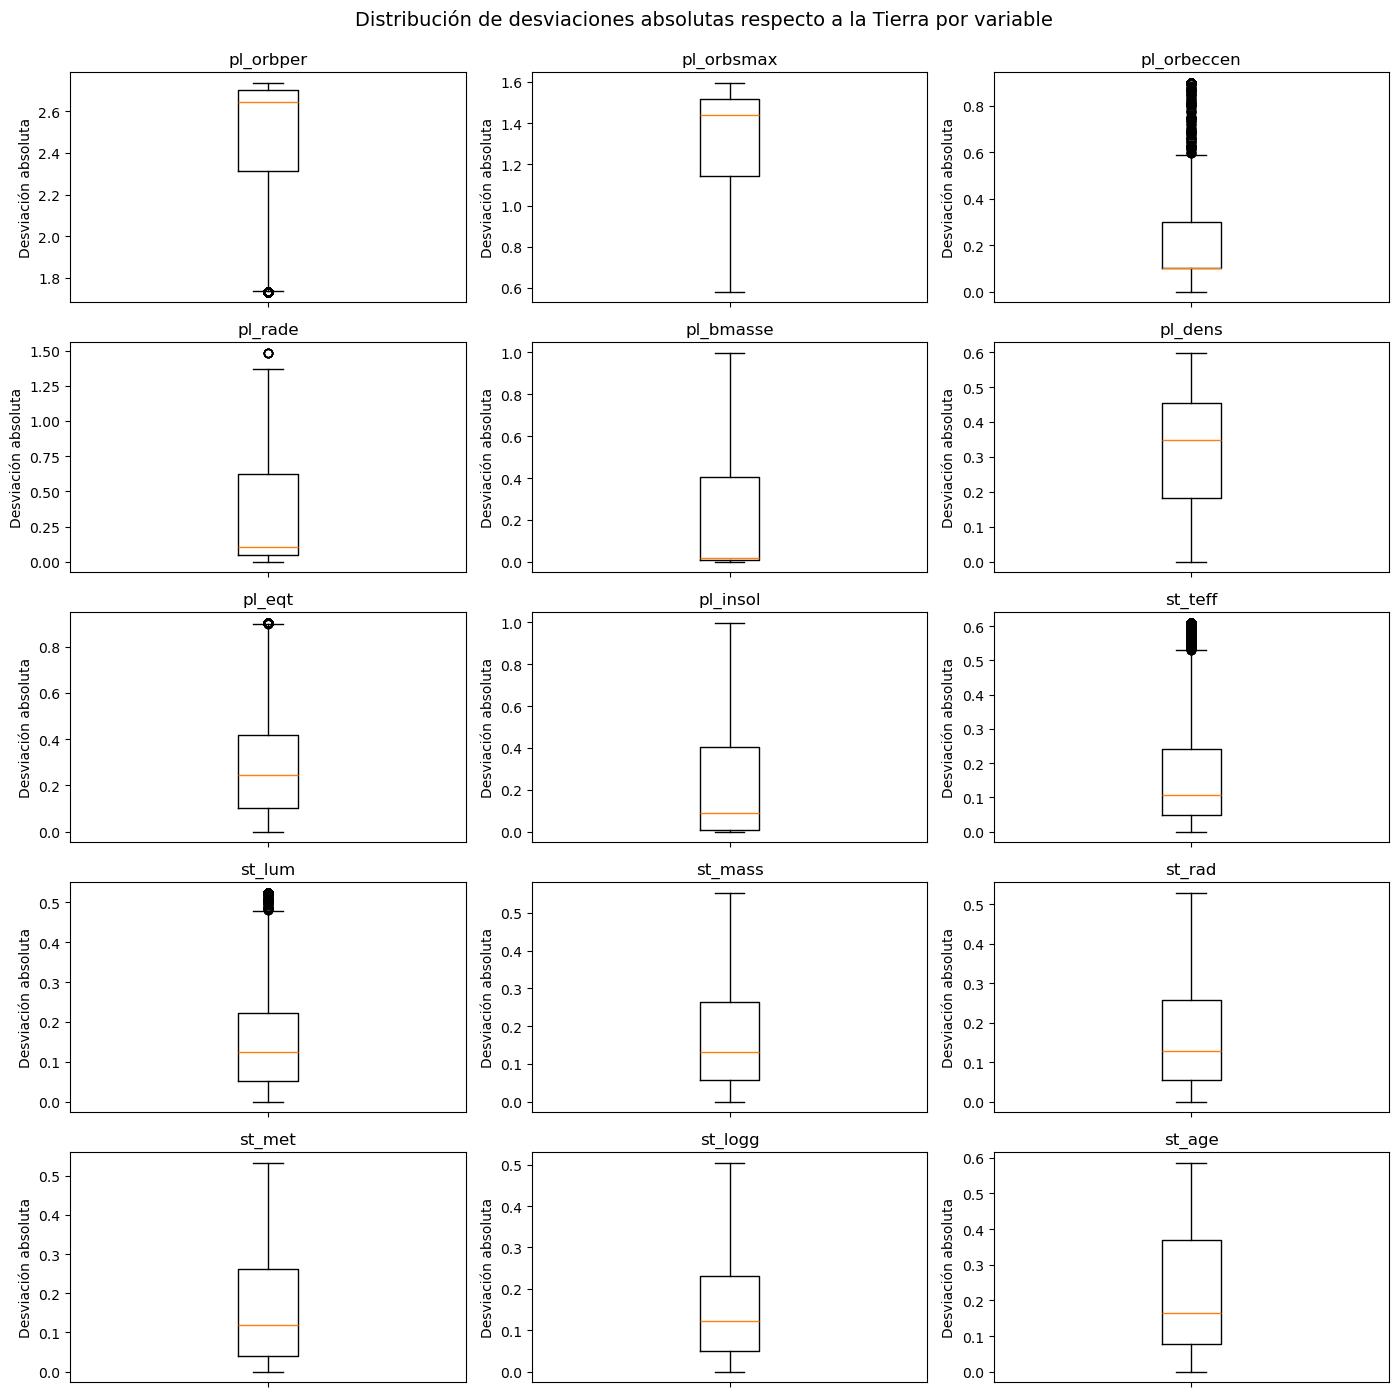

In [108]:
fig, axes = plt.subplots(5, 3, figsize=(14, 14))
axes = axes.flatten()

i = 0
for col in num_cols:
    axes[i].boxplot(df_deviations[col])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Desviación absoluta')
    axes[i].tick_params(axis='x', labelbottom=False)
    i += 1

plt.suptitle('Distribución de desviaciones absolutas respecto a la Tierra por variable', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

### **Interpretación de las desviaciones absolutas**

Los resultados obtenidos permiten identificar patrones relevantes en las desviaciones de los exoplanetas respecto a las condiciones terrestres.

**Variables con mayores desviaciones medias.** Las variables que muestran desviaciones medias más altas indican las dimensiones físicas en las que el conjunto de exoplanetas conocidos se aleja más significativamente de las condiciones terrestres. En este caso destacan especialmente `pl_orbper`, `pl_orbsmax`, `pl_rade`, `pl_bmasse` y `pl_insol`, es decir, magnitudes asociadas a la escala orbital del sistema y al tamaño, masa y radiación recibida por el planeta.

Este resultado es coherente con la naturaleza del catálogo: muchos exoplanetas detectados hasta la fecha pertenecen a configuraciones físicas muy distintas de la Tierra, ya sea por estar mucho más cerca o más lejos de su estrella, por tener tamaños mayores o por recibir niveles de irradiación muy alejados del entorno terrestre.

**Variables con menores desviaciones.** Otras magnitudes presentan desviaciones medias relativamente más bajas, como algunas variables estelares (`st_lum`, `st_teff`, `st_mass`, `st_rad` o `st_age`). Esto sugiere que, al menos en esas dimensiones, una parte del catálogo se mantiene en órdenes de magnitud más próximos a la referencia Tierra–Sol, ya sea por sesgos observacionales o por la mayor estabilidad estructural de muchas estrellas anfitrionas respecto a las propiedades planetarias.

La alternativa habría sido pasar directamente a la agregación global de distancias sin detenerse en esta lectura por variable. Sin embargo, hacerlo así habría ocultado qué dimensiones físicas están separando más al catálogo de la Tierra y cuáles aportan diferencias relativamente menores. Este bloque permite precisamente descomponer la futura distancia global en contribuciones interpretables antes de combinarlas en una única medida agregada.

## **12. Agregación de desviaciones (distancia euclídea)**

Una vez calculadas las desviaciones absolutas por variable, el siguiente paso consiste en combinarlas en una única medida global que cuantifique el alejamiento total de cada planeta respecto al vector Tierra.

Esta agregación se realiza mediante la **distancia euclídea** en el espacio multidimensional definido por las variables físicas seleccionadas. La elección de esta métrica responde a que permite integrar todas las discrepancias parciales en un único valor escalar, conservando una interpretación geométrica directa: cuanto mayor es la distancia, mayor es la disimilitud física global respecto a la Tierra.

No se opta aquí por una simple suma de desviaciones, porque eso trataría todas las diferencias de forma lineal y no reflejaría adecuadamente la acumulación conjunta de discrepancias en múltiples dimensiones. Tampoco se utiliza distancia Manhattan, ya que en este contexto interesa que las desviaciones grandes tengan un peso creciente y que la agregación refleje de forma natural la separación geométrica en el espacio físico ya escalado. La distancia euclídea es, por tanto, más coherente con la idea de proximidad global al vector Tierra dentro de un modelo basado en magnitudes continuas y comparables.

Formalmente, para cada planeta \(i\), la distancia al vector Tierra se define como:

$$
D_i = \sqrt{\sum_{j=1}^{p} \left| x_{ij}^{\text{scaled}} \right|^2}
$$

donde:

- $x_{ij}^{\text{scaled}}$ es la desviación relativa escalada (en valor absoluto) de la variable $j$ para el planeta $i$.
- $p$ es el número total de variables consideradas.
- $D_i$ representa la **distancia euclídea al vector Tierra**, interpretada como una medida global de disimilitud física.

Este valor sintetiza todas las desviaciones individuales en una única distancia por planeta, permitiendo ordenar directamente los exoplanetas según su proximidad al estado terrestre y sirviendo como base para la construcción posterior del índice de habitabilidad.

La métrica resultante no pretende afirmar nada por sí sola sobre la existencia de vida, sino ofrecer una medida continua y reproducible de similitud física global. Su utilidad dentro del modelo consiste en traducir múltiples diferencias parciales en una sola cantidad agregada, manteniendo la referencia terrestre como centro explícito de la comparación.


Una vez fijada la métrica de agregación, se calcula la distancia euclídea al vector Tierra para cada exoplaneta. El resultado se almacena en un nuevo dataset (`df_distance`) que conserva las variables anteriores y añade una medida global de disimilitud física respecto a la referencia terrestre.

In [109]:
# Calculamos la distancia euclídea al vector Tierra para cada planeta
# Fórmula: D_i = sqrt(sum(x_ij^2)) donde x_ij son las desviaciones escaladas

df_distance = df_deviations.copy()
df_distance['distancia_tierra'] = np.sqrt((df_deviations[num_cols] ** 2).sum(axis=1))

df_distance[['pl_name', 'hostname', 'distancia_tierra']].head(10)

,pl_name,hostname,distancia_tierra
0,K2-178 b,K2-178,3.114355
1,HD 74698 c,HD 74698,2.328289
2,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,2.237671
3,GJ 1061 b,GJ 1061,3.490395
4,Kepler-102 b,Kepler-102,3.241160
5,Kepler-1446 b,Kepler-1446,3.415971
6,HD 13908 b,HD 13908,3.223060
7,HIP 9618 b,HIP 9618,2.984074
8,HD 202696 c,HD 202696,2.372298
9,Kepler-1697 b,Kepler-1697,2.842466


### **Estadísticas descriptivas de la distancia euclídea**

Una vez calculada la distancia euclídea para cada exoplaneta, se analiza su distribución mediante estadísticas descriptivas. Este paso permite comprobar cómo se reparte la disimilitud global respecto a la Tierra dentro del catálogo y si la agregación produce una métrica razonablemente interpretable antes de transformarla en índice de habitabilidad.

In [110]:
print(df_distance['distancia_tierra'].describe())

count    6021.000000
mean        3.003984
std         0.434522
min         1.844252
25%         2.724459
50%         3.116834
75%         3.302543
max         3.943040
Name: distancia_tierra, dtype: float64


### **Visualización de la distribución de distancias**

Para comprender mejor cómo se distribuyen las distancias euclídeas al vector Tierra en el conjunto de exoplanetas, se representa su distribución mediante un histograma y un boxplot. Estas visualizaciones permiten:

- Identificar la **forma de la distribución** (simétrica, asimétrica, multimodal).
- Detectar la presencia de **grupos diferenciados** de planetas según su similitud con la Tierra.
- Localizar **valores atípicos** que representen planetas extremadamente similares o diferentes.

La visualización cumple aquí una función importante: comprobar si la métrica agregada concentra la mayor parte de los planetas en rangos razonables y si la distancia euclídea produce una estructura interpretable del catálogo, en lugar de un reparto arbitrario o difícil de leer.

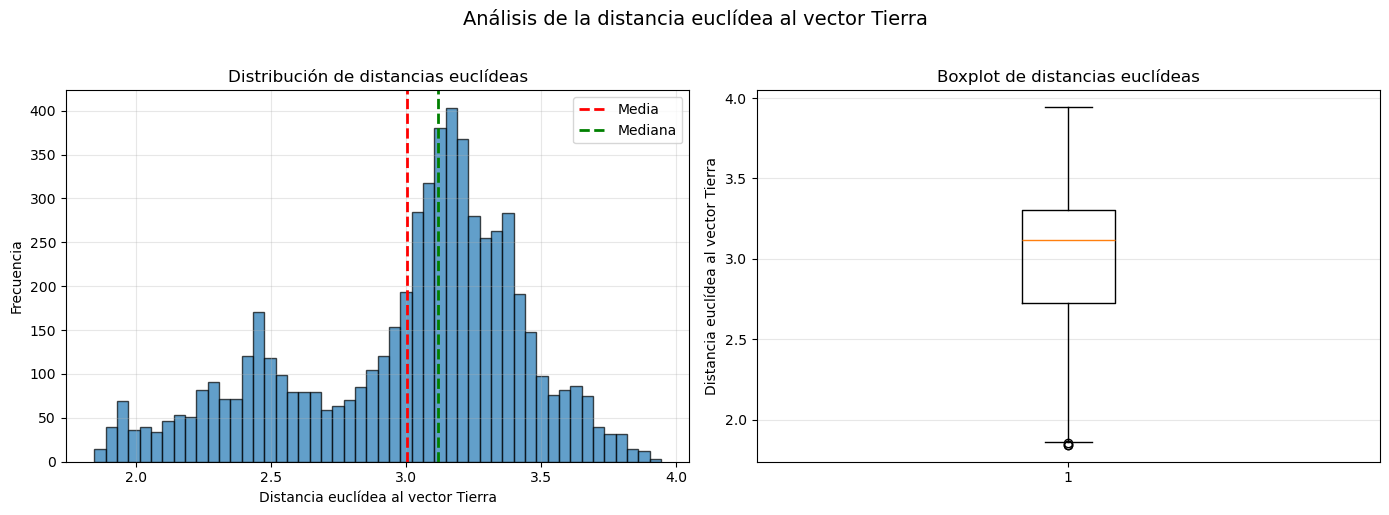

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_distance['distancia_tierra'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Distancia euclídea al vector Tierra')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de distancias euclídeas')
axes[0].axvline(df_distance['distancia_tierra'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0].axvline(df_distance['distancia_tierra'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(df_distance['distancia_tierra'], vert=True)
axes[1].set_ylabel('Distancia euclídea al vector Tierra')
axes[1].set_title('Boxplot de distancias euclídeas')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Análisis de la distancia euclídea al vector Tierra', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### **Análisis detallado de planetas extremos**

Para entender qué hace que un planeta sea similar o diferente a la Tierra, se comparan las características físicas de:

- El planeta **más similar** (menor distancia euclídea)
- El planeta **más diferente** (mayor distancia euclídea)
- La **Tierra** (referencia)

Esta comparación permite identificar en qué variables concretas se producen las mayores diferencias y comprobar si la métrica agregada está señalando casos coherentes con la lógica física del modelo. Frente a la alternativa de aceptar la distancia como un resultado puramente matemático, este contraste ayuda a verificar que los extremos del ranking responden a configuraciones comprensibles en términos orbitales, planetarios y estelares.

In [112]:
idx_mas_similar = df_distance['distancia_tierra'].idxmin()
idx_mas_diferente = df_distance['distancia_tierra'].idxmax()

planeta_similar = df_final.loc[idx_mas_similar, 'pl_name']
planeta_diferente = df_final.loc[idx_mas_diferente, 'pl_name']

print(f"\nPlaneta más similar: {planeta_similar} (distancia = {df_distance.loc[idx_mas_similar, 'distancia_tierra']:.4f})")
print(f"Planeta más diferente: {planeta_diferente} (distancia = {df_distance.loc[idx_mas_diferente, 'distancia_tierra']:.4f})")
print("\n" + "-"*90)
print(f"{'Variable':15s} {'Más similar':>15s} {'Tierra':>15s} {'Más diferente':>15s}")
print("-"*90)

for var in num_cols:
    val_similar = df_final.loc[idx_mas_similar, var]
    val_tierra = vector_tierra[var]
    val_diferente = df_final.loc[idx_mas_diferente, var]
    print(f"{var:15s} {val_similar:15.2f} {val_tierra:15.2f} {val_diferente:15.2f}")

print("-"*90)


Planeta más similar: KMT-2021-BLG-0912L b (distancia = 1.8443)
Planeta más diferente: KELT-9 b (distancia = 3.9430)

------------------------------------------------------------------------------------------
Variable            Más similar          Tierra   Más diferente
------------------------------------------------------------------------------------------
pl_orbper                134.07          365.25            1.48
pl_orbsmax                 0.64            1.00            0.03
pl_orbeccen                0.00            0.02            0.00
pl_rade                    1.49            1.00           21.20
pl_bmasse                  2.81            1.00          443.49
pl_dens                    4.67            5.51            0.53
pl_eqt                   147.54          255.00         2022.00
pl_insol                   0.09            1.00          643.38
st_teff                 5554.00         5778.00         7285.45
st_lum                    -0.07            0.00            1

### **Interpretación de la agregación mediante distancia euclídea**

La distancia euclídea calculada para cada exoplaneta representa una **medida sintética de disimilitud física global** respecto a las condiciones terrestres. Sus principales características son:

**Propiedades de la métrica**:
- **Valores bajos** (cercanos a 0): indican que el planeta presenta características físicas muy similares a la Tierra en el conjunto de variables consideradas.
- **Valores altos**: indican que el planeta se aleja significativamente de las condiciones terrestres en múltiples dimensiones físicas.
- **Escala comparable**: al estar calculada sobre variables previamente escaladas mediante percentiles, todas las dimensiones contribuyen de forma equilibrada, sin que magnitudes numéricamente grandes dominen el resultado.

**Información agregada**:
- La distancia euclídea integra las desviaciones parciales de todas las variables (orbitales, planetarias y estelares) en un único valor escalar.
- Un planeta puede tener desviaciones moderadas en muchas variables o desviaciones extremas en pocas; ambos casos se reflejarán en la distancia global.
- La métrica es **simétrica** y coherente con la representación geométrica del problema: cuanto más lejos queda un planeta del vector Tierra en el espacio físico definido, mayor será su distancia.

La alternativa habría sido utilizar una agregación lineal más simple o una métrica menos sensible a grandes discrepancias. Sin embargo, en este proyecto interesa precisamente que las separaciones importantes respecto a la referencia terrestre tengan un peso creciente en la distancia global, porque forman parte central del criterio de similitud física adoptado.

Por ello, la distancia euclídea funciona aquí como una síntesis coherente del modelo: no reemplaza la interpretación por variable, pero sí permite pasar de un conjunto de desviaciones parciales a una única medida agregada sobre la que podrá construirse el índice de habitabilidad.

## **13. Cálculo del índice de habitabilidad** 

Una vez obtenida la distancia euclídea global $D_i$ de cada planeta respecto al **vector Tierra** en el espacio de variables físicas escaladas, se define el **índice de habitabilidad relativo** como una transformación directa de dicha distancia.

El objetivo es convertir la medida de disimilitud física en un índice acotado entre 0 y 1, donde valores más altos indiquen mayor similitud con la Tierra y donde la lectura del resultado siga siendo sencilla e interpretable.

$$
H_i = \frac{1}{1 + D_i}
$$

donde:

- $H_i$ es el **índice de habitabilidad relativo** del planeta $i$.
- $D_i$ es la **distancia euclídea al vector Tierra**, calculada a partir del vector de desviaciones absolutas escaladas.
- El índice queda acotado en el intervalo $(0,1)$, siendo:
  - $H_i = 1$: planeta idéntico a la Tierra en el espacio físico definido.
  - $H_i \to 0$: planeta físicamente muy distinto.

Esta transformación se elige porque cumple simultáneamente varias propiedades útiles para el modelo: es **monótona decreciente** (a mayor distancia, menor índice), está **acotada** entre 0 y 1, conserva una **interpretación directa** y no introduce parámetros adicionales que requieran calibración arbitraria.

No se opta por dejar la distancia euclídea como resultado final, porque la distancia es una medida de disimilitud y su lectura es menos intuitiva como índice de habitabilidad. Tampoco se utilizan transformaciones más agresivas —por ejemplo exponenciales del tipo $e^{-D_i}$ o funciones logísticas— porque, aunque también serían válidas matemáticamente, introducirían una sensibilidad más difícil de justificar sin un criterio físico externo para calibrarla. Del mismo modo, una transformación lineal simple podría producir valores poco acotados o depender demasiado del rango observado en el dataset.

La elección de $H_i = \frac{1}{1 + D_i}$ permite transformar la distancia multivariante en una métrica directa de similitud: cuanto menor es la distancia al estado terrestre, mayor es el valor del índice, y cuanto más se aleja un planeta, más se aproxima el índice a 0 de forma suave y continua.

El enfoque evita introducir ponderaciones arbitrarias entre variables y trata todas las dimensiones físicas de forma equivalente. De este modo, la habitabilidad se evalúa exclusivamente en función de la cercanía conjunta al estado terrestre, manteniendo un criterio objetivo, reproducible y físicamente interpretable.

El índice resultante no pretende modelar procesos biológicos o climáticos complejos, sino proporcionar una métrica sintética de similitud planetaria útil para construir un ranking interpretable dentro del marco físico adoptado.

Una vez fijada la transformación del modelo, se aplica la fórmula a la distancia euclídea de cada planeta para obtener el índice de habitabilidad relativo. El resultado se incorpora al dataset como una nueva variable sintética que resume la similitud física global respecto a la Tierra en una escala acotada e interpretable.

In [113]:
# Calculamos el índice de habitabilidad aplicando la transformación H_i = 1 / (1 + D_i)
# Esta fórmula convierte la distancia euclídea en un índice acotado entre 0 y 1

df_exoplanetas_habitabilidad = df_distance.copy()

df_exoplanetas_habitabilidad['indice_habitabilidad'] = 1 / (1 + df_exoplanetas_habitabilidad['distancia_tierra'])
df_exoplanetas_habitabilidad[['pl_name', 'hostname', 'distancia_tierra', 'indice_habitabilidad']].head(10)

,pl_name,hostname,distancia_tierra,indice_habitabilidad
0,K2-178 b,K2-178,3.114355,0.243051
1,HD 74698 c,HD 74698,2.328289,0.300455
2,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,2.237671,0.308864
3,GJ 1061 b,GJ 1061,3.490395,0.222698
4,Kepler-102 b,Kepler-102,3.241160,0.235785
5,Kepler-1446 b,Kepler-1446,3.415971,0.226451
6,HD 13908 b,HD 13908,3.223060,0.236795
7,HIP 9618 b,HIP 9618,2.984074,0.250999
8,HD 202696 c,HD 202696,2.372298,0.296534
9,Kepler-1697 b,Kepler-1697,2.842466,0.260250


### **Estadísticas descriptivas del índice de habitabilidad**

Una vez calculado el índice de habitabilidad para todos los exoplanetas, se analiza su distribución mediante estadísticas descriptivas. Este índice representa la **similitud física global** respecto a la Tierra:

- **Valores cercanos a 1**: planeta muy similar a la Tierra en el conjunto de variables consideradas.
- **Valores cercanos a 0**: planeta físicamente muy diferente de la Tierra.
- **Rango intermedio**: grados variables de similitud parcial.

El índice permite ordenar de forma directa los exoplanetas según su proximidad al estado terrestre. Esta revisión estadística sirve además para comprobar si la transformación elegida produce una escala razonable, con suficiente capacidad de discriminación entre planetas y sin concentrar artificialmente todos los valores en una región estrecha del intervalo.

In [114]:
print(df_exoplanetas_habitabilidad['indice_habitabilidad'].describe())

print(f"Índice máximo (planeta más similar): {df_exoplanetas_habitabilidad['indice_habitabilidad'].max():.6f}")
print(f"Índice mínimo (planeta más diferente): {df_exoplanetas_habitabilidad['indice_habitabilidad'].min():.6f}")
print(f"Índice medio: {df_exoplanetas_habitabilidad['indice_habitabilidad'].mean():.6f}")
print(f"Índice mediano: {df_exoplanetas_habitabilidad['indice_habitabilidad'].median():.6f}")
print(f"Desviación estándar: {df_exoplanetas_habitabilidad['indice_habitabilidad'].std():.6f}")

count    6021.000000
mean        0.253029
std         0.030463
min         0.202305
25%         0.232421
50%         0.242905
75%         0.268495
max         0.351586
Name: indice_habitabilidad, dtype: float64
Índice máximo (planeta más similar): 0.351586
Índice mínimo (planeta más diferente): 0.202305
Índice medio: 0.253029
Índice mediano: 0.242905
Desviación estándar: 0.030463


### **Visualización de la distribución del índice de habitabilidad**

Para comprender mejor cómo se distribuye el índice de habitabilidad en el conjunto de exoplanetas, se representa su distribución mediante un histograma y un boxplot. Estas visualizaciones permiten:

- Identificar la **forma de la distribución** del índice.
- Detectar la presencia de **planetas con índices excepcionalmente altos** (muy similares a la Tierra).
- Observar si existe **separación clara** entre grupos de planetas según su similitud con la Tierra.
- Evaluar la **concentración** de planetas en distintos rangos del índice.

La visualización cumple aquí una función de comprobación del modelo: verificar que la transformación elegida convierte las distancias en una escala legible, continua y útil para ordenar el catálogo sin introducir comportamientos extraños o saltos artificiales.

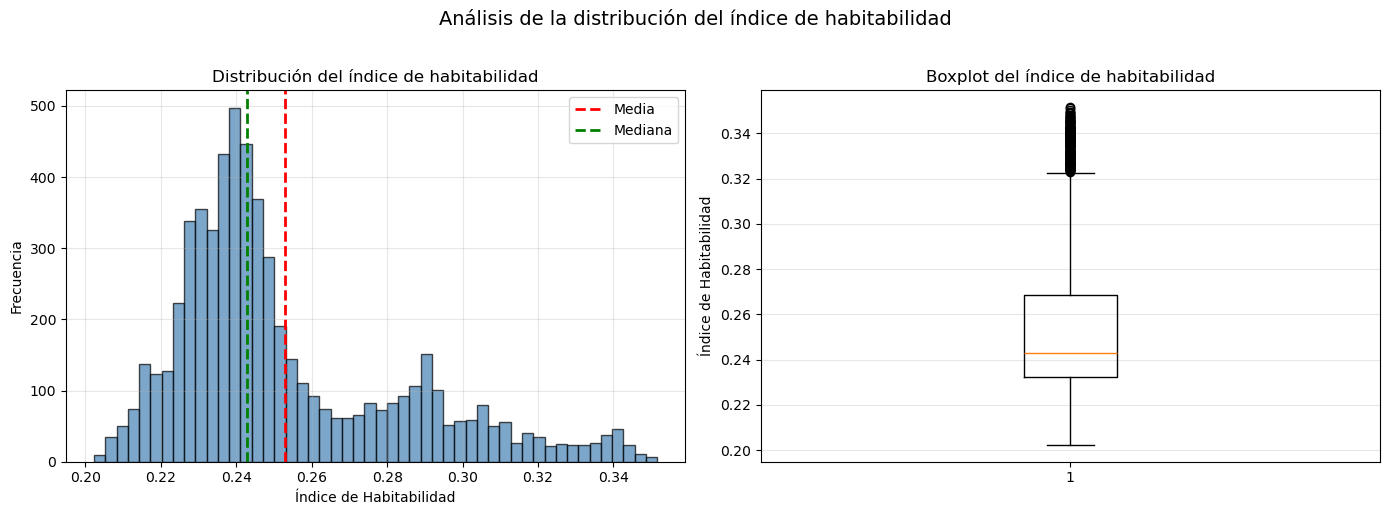

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_exoplanetas_habitabilidad['indice_habitabilidad'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Índice de Habitabilidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del índice de habitabilidad')
axes[0].axvline(df_exoplanetas_habitabilidad['indice_habitabilidad'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0].axvline(df_exoplanetas_habitabilidad['indice_habitabilidad'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(df_exoplanetas_habitabilidad['indice_habitabilidad'], vert=True)
axes[1].set_ylabel('Índice de Habitabilidad')
axes[1].set_title('Boxplot del índice de habitabilidad')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Análisis de la distribución del índice de habitabilidad', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(ruta_imagenes, "distribucion_indice.png"), dpi=300, bbox_inches="tight")
plt.show()

### **Relación entre distancia euclídea e índice de habitabilidad**

Para visualizar la transformación aplicada, se representa la relación funcional entre la distancia euclídea al vector Tierra y el índice de habitabilidad resultante.

Esta gráfica muestra cómo la función $H_i = \frac{1}{1 + D_i}$ convierte las distancias en un índice acotado entre 0 y 1:

- **Distancias pequeñas** se mapean a **índices cercanos a 1** (alta similitud).
- **Distancias grandes** se mapean a **índices cercanos a 0** (baja similitud).
- La transformación es **no lineal**: pequeñas variaciones en distancia se reflejan más en el índice cuando estamos cerca del origen.

Esta no linealidad es deliberada. Permite diferenciar mejor a los planetas que están relativamente cerca de la referencia terrestre y comprime progresivamente las diferencias entre objetos ya muy alejados, algo coherente con el objetivo del índice: priorizar la cercanía física a la Tierra y no ampliar innecesariamente la separación entre planetas que ya son claramente disímiles.

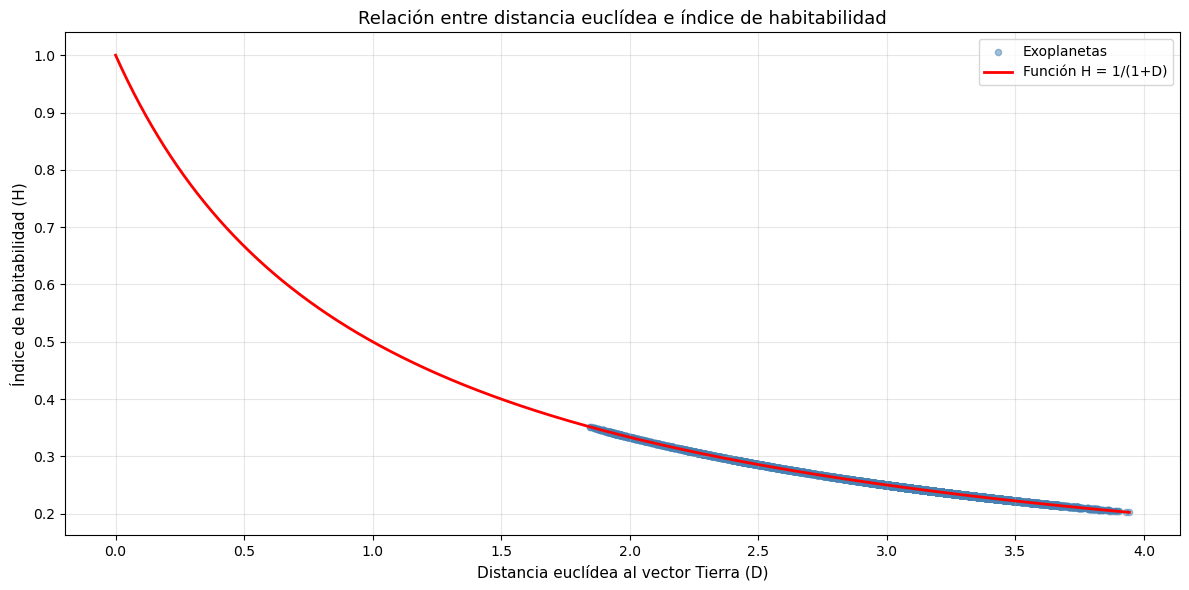

In [116]:
plt.figure(figsize=(12, 6))

plt.scatter(df_exoplanetas_habitabilidad['distancia_tierra'], 
            df_exoplanetas_habitabilidad['indice_habitabilidad'], 
            alpha=0.5, 
            s=20, 
            color='steelblue',
            label='Exoplanetas')

d_teorica = np.linspace(0, df_exoplanetas_habitabilidad['distancia_tierra'].max(), 1000)
h_teorica = 1 / (1 + d_teorica)
plt.plot(d_teorica, h_teorica, 'r-', linewidth=2, label='Función H = 1/(1+D)')

plt.xlabel('Distancia euclídea al vector Tierra (D)', fontsize=11)
plt.ylabel('Índice de habitabilidad (H)', fontsize=11)
plt.title('Relación entre distancia euclídea e índice de habitabilidad', fontsize=13)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### **Interpretación del índice de habitabilidad**

El índice de habitabilidad calculado mediante la transformación $H_i = \frac{1}{1 + D_i}$ presenta las siguientes características fundamentales:

- **Acotado**: el índice está siempre en el intervalo $(0, 1)$, lo que facilita la comparación directa entre planetas.
- **Monotonía decreciente**: a mayor distancia euclídea, menor índice de habitabilidad.
- **Máximo teórico**: cuando $D_i = 0$, el índice vale 1, lo que correspondería a un planeta idéntico a la Tierra dentro del espacio físico definido.
- **Comportamiento asintótico**: cuando la distancia crece mucho, el índice se aproxima a 0 sin necesidad de fijar un umbral artificial de “no habitabilidad”.

Estas propiedades hacen que el índice sea útil como medida relativa de similitud, no como veredicto absoluto sobre la existencia de vida. Su valor no debe interpretarse como una probabilidad física o biológica, sino como una puntuación sintética que resume cuán cerca queda un planeta de la referencia terrestre en el marco concreto del modelo construido.

La alternativa habría sido usar directamente la distancia como salida final o aplicar transformaciones más complejas con parámetros ajustables. Sin embargo, dejar la distancia sin transformar haría menos intuitiva la lectura del resultado, mientras que fórmulas más sofisticadas exigirían justificar por qué se elige una determinada curvatura o sensibilidad. La transformación adoptada aquí mantiene simplicidad, continuidad e interpretabilidad sin introducir supuestos adicionales difíciles de defender.

Por ello, el índice funciona como la salida natural del modelo: traduce una distancia física global en una escala de similitud legible, acotada y directamente utilizable para ordenar el catálogo de exoplanetas.

## **14. Generación del ranking**

Una vez calculado el índice de habitabilidad para cada exoplaneta, el siguiente paso consiste en ordenar el conjunto completo de planetas en función de dicho valor. Esta operación transforma una medida continua de similitud en una herramienta práctica de priorización, generando un ranking descendente desde los candidatos más próximos a la Tierra hasta los más alejados dentro del marco del modelo.

El objetivo de este bloque no es añadir nueva información al índice, sino convertirlo en una salida operativa y legible. Un valor numérico aislado permite medir similitud, pero el ranking permite comparar de forma inmediata todos los objetos del catálogo bajo un mismo criterio y responder a la pregunta central del proyecto: **qué exoplanetas aparecen más próximos a las condiciones terrestres según el índice construido**.

Tampoco se opta por clasificar los planetas en categorías discretas del tipo “alta”, “media” o “baja” habitabilidad, ya que eso introduciría umbrales arbitrarios sobre una magnitud que aquí se ha definido como continua. El ranking conserva toda la información ordinal del índice y evita forzar cortes artificiales donde el modelo no los ha definido.

De este modo, el ranking convierte el índice en una herramienta útil para:

* identificar de forma inmediata los exoplanetas con mayor similitud relativa a la Tierra
* comparar cuantitativamente todos los objetos del dataset bajo un mismo marco de referencia
* priorizar candidatos para análisis posteriores o estudios más detallados

En otras palabras, este bloque no redefine la habitabilidad, sino que ordena de forma explícita el resultado del modelo para hacerlo interpretable y utilizable.

A continuación se genera una copia del dataset con el índice de habitabilidad ya calculado, se ordenan los registros de forma descendente y se asigna una posición ordinal a cada planeta. El resultado es un nuevo dataframe (`df_exoplanetas_ranking`) que conserva la información original relevante y añade una lectura directa del posicionamiento relativo de cada exoplaneta dentro del catálogo.

In [117]:
#creamos una copia
df_exoplanetas_ranking = df_exoplanetas_habitabilidad.copy()

#creamos el índice de habitabilidad
df_exoplanetas_ranking["orig_idx"] = df_exoplanetas_ranking.index
df_exoplanetas_ranking = df_exoplanetas_ranking.sort_values('indice_habitabilidad', ascending=False).reset_index(drop=True)
df_exoplanetas_ranking.insert(0, 'ranking', range(1, len(df_exoplanetas_ranking) + 1))

#filtramos por las columnas para observar los reultados
columnas_ranking = ['ranking', 'pl_name', 'hostname', 'distancia_tierra', 'indice_habitabilidad']
df_exoplanetas_ranking[columnas_ranking].head(30)

,ranking,pl_name,hostname,distancia_tierra,indice_habitabilidad
0,1,KMT-2021-BLG-0912L b,KMT-2021-BLG-0912L,1.844252,0.351586
1,2,Kepler-1638 b,Kepler-1638,1.845849,0.351389
2,3,Kepler-1040 b,Kepler-1040,1.852877,0.350523
3,4,Kepler-1606 b,Kepler-1606,1.860648,0.349571
4,5,OGLE-2019-BLG-1053L b,OGLE-2019-BLG-1053L,1.861756,0.349436
5,6,KMT-2019-BLG-1806L b,KMT-2019-BLG-1806L,1.864254,0.349131
6,7,OGLE-2016-BLG-0007L b,OGLE-2016-BLG-0007L,1.865285,0.349005
7,8,Kepler-452 b,Kepler-452,1.870869,0.348327
8,9,Kepler-1090 b,Kepler-1090,1.873577,0.347998
9,10,KMT-2018-BLG-0029L b,KMT-2018-BLG-0029L,1.876084,0.347695


## **15. Interpretación del Top**

Una vez generado el ranking, el siguiente paso consiste en interpretar físicamente los exoplanetas mejor posicionados. El objetivo de este bloque no es recalcular el índice ni introducir nuevas reglas de selección, sino entender por qué ciertos planetas aparecen en las primeras posiciones y qué variables están contribuyendo de forma más importante a su proximidad relativa con la Tierra.

Este bloque es necesario porque el ranking, por sí solo, solo ordena. Para que el resultado del modelo sea realmente interpretable, hay que leer qué configuraciones físicas están siendo favorecidas por el índice y en qué dimensiones concretas se concentran las similitudes y diferencias con la referencia terrestre.

Tampoco se pretende aquí validar experimentalmente la habitabilidad de los candidatos ni extrapolar conclusiones astrobiológicas fuertes. El propósito es más acotado: interpretar físicamente el Top del ranking, identificar patrones comunes entre los primeros puestos y comprobar si la lógica de los resultados es coherente con las decisiones metodológicas adoptadas en los bloques anteriores.

### **Comparación detallada: Planeta #1 vs. Tierra**

Para entender concretamente por qué el índice del planeta mejor clasificado no alcanza valores próximos a 1, se comparan sus características físicas con las de la Tierra, variable por variable.

Esta comparación cumple una función interpretativa central: mostrar que una buena posición en el ranking no significa equivalencia física con la Tierra, sino cercanía relativa dentro del espacio de variables definido por el modelo. Frente a la alternativa de quedarse solo con el valor agregado del índice, este contraste permite ver en qué dimensiones concretas se concentra la similitud y en cuáles persisten las mayores discrepancias.

A continuación se recupera el planeta situado en la primera posición del ranking y se comparan sus valores originales con la referencia terrestre, junto con sus desviaciones escaladas. Esta lectura conjunta permite pasar del índice agregado a una interpretación variable a variable del resultado.

In [118]:
planeta_top1 = df_exoplanetas_ranking.iloc[0]
orig_idx = int(planeta_top1["orig_idx"])

# Comparación detallada del planeta #1 con la Tierra
print(f"COMPARACIÓN DETALLADA: {planeta_top1['pl_name']} vs. TIERRA")
print(f"\n{'Variable':20s} {'Planeta #1':>15s} {'Tierra':>15s} {'Desv. Escalada':>18s} {'Diferencia %':>15s}")
print("-"*100)

for var in num_cols:
        # Valores originales
    val_planeta = df_final.loc[orig_idx, var]
    val_tierra = vector_tierra[var]
    # Desviación escalada (con signo)
    desv_escalada = df_scaled.loc[orig_idx, var]
    
    # Diferencia porcentual respecto a Tierra (evitando división por 0)
    if val_tierra != 0:
        diff_pct = ((val_planeta - val_tierra) / abs(val_tierra)) * 100
    else:
        diff_pct = 0 if val_planeta == 0 else float('inf')

    print(f"{var:20s} {val_planeta:15.2f} {val_tierra:15.2f} {desv_escalada:15.2f} {diff_pct:12.1f}%")


COMPARACIÓN DETALLADA: KMT-2021-BLG-0912L b vs. TIERRA

Variable                  Planeta #1          Tierra     Desv. Escalada    Diferencia %
----------------------------------------------------------------------------------------------------
pl_orbper                     134.07          365.25           -1.73        -63.3%
pl_orbsmax                      0.64            1.00           -0.58        -36.3%
pl_orbeccen                     0.00            0.02           -0.10       -100.0%
pl_rade                         1.49            1.00            0.03         49.0%
pl_bmasse                       2.81            1.00            0.00        181.0%
pl_dens                         4.67            5.51           -0.09        -15.2%
pl_eqt                        147.54          255.00           -0.05        -42.1%
pl_insol                        0.09            1.00           -0.00        -91.4%
st_teff                      5554.00         5778.00           -0.06         -3.9%
st_lum  

### **Visualización de desviaciones: Top 1 vs. Tierra**

Se representan gráficamente las desviaciones escaladas del planeta mejor clasificado respecto a la Tierra para visualizar en qué variables específicas se concentran las diferencias.

La primera gráfica permite observar en qué dimensiones el planeta se sitúa por encima o por debajo de la Tierra. La segunda muestra qué variables están contribuyendo más a la distancia global y, por tanto, al valor final del índice. Esta visualización es importante porque evita interpretar el Top únicamente como una lista ordenada y permite identificar de forma directa qué rasgos físicos explican realmente la posición del candidato mejor clasificado.

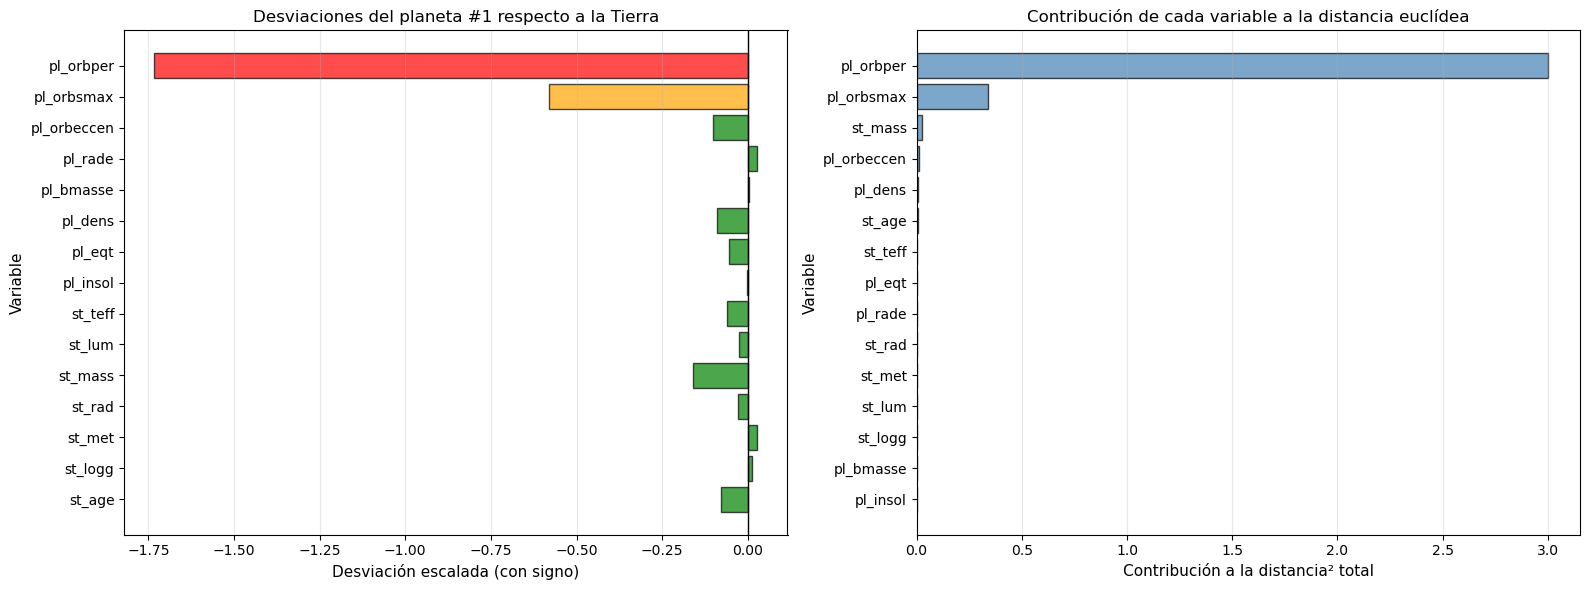

In [119]:
idx_top1 = int(planeta_top1["orig_idx"])
desviaciones_top1 = df_scaled.loc[idx_top1, num_cols]
desviaciones_abs_top1 = df_deviations.loc[idx_top1, num_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['green' if abs(x) < 0.3 else 'orange' if abs(x) < 0.6 else 'red' for x in desviaciones_top1]
axes[0].barh(num_cols, desviaciones_top1, color=colors, alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Desviación escalada (con signo)', fontsize=11)
axes[0].set_ylabel('Variable', fontsize=11)
axes[0].set_title(f'Desviaciones del planeta #{1} respecto a la Tierra', fontsize=12)
axes[0].grid(alpha=0.3, axis='x')
axes[0].invert_yaxis()

contribuciones = desviaciones_abs_top1 ** 2
contribuciones_sorted = contribuciones.sort_values(ascending=True)
axes[1].barh(contribuciones_sorted.index, contribuciones_sorted.values, 
             color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Contribución a la distancia² total', fontsize=11)
axes[1].set_ylabel('Variable', fontsize=11)
axes[1].set_title('Contribución de cada variable a la distancia euclídea', fontsize=12)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### **Visualización del ranking: decaimiento del índice de habitabilidad**

Para entender mejor cómo se distribuyen los exoplanetas a lo largo del ranking, se representa gráficamente el índice de habitabilidad en función de la posición ordinal.

Esta visualización permite identificar:
- La **tasa de decaimiento** del índice a lo largo del ranking.
- Si existen **saltos bruscos** o **grupos diferenciados** de planetas.
- La **separación** entre los candidatos más prometedores y el resto del catálogo.

Su utilidad aquí no es meramente descriptiva. Permite comprobar si el ranking produce una gradación continua y razonable de similitud o si, por el contrario, concentra demasiado valor en un pequeño grupo de objetos y pierde capacidad de discriminación en el resto del catálogo.

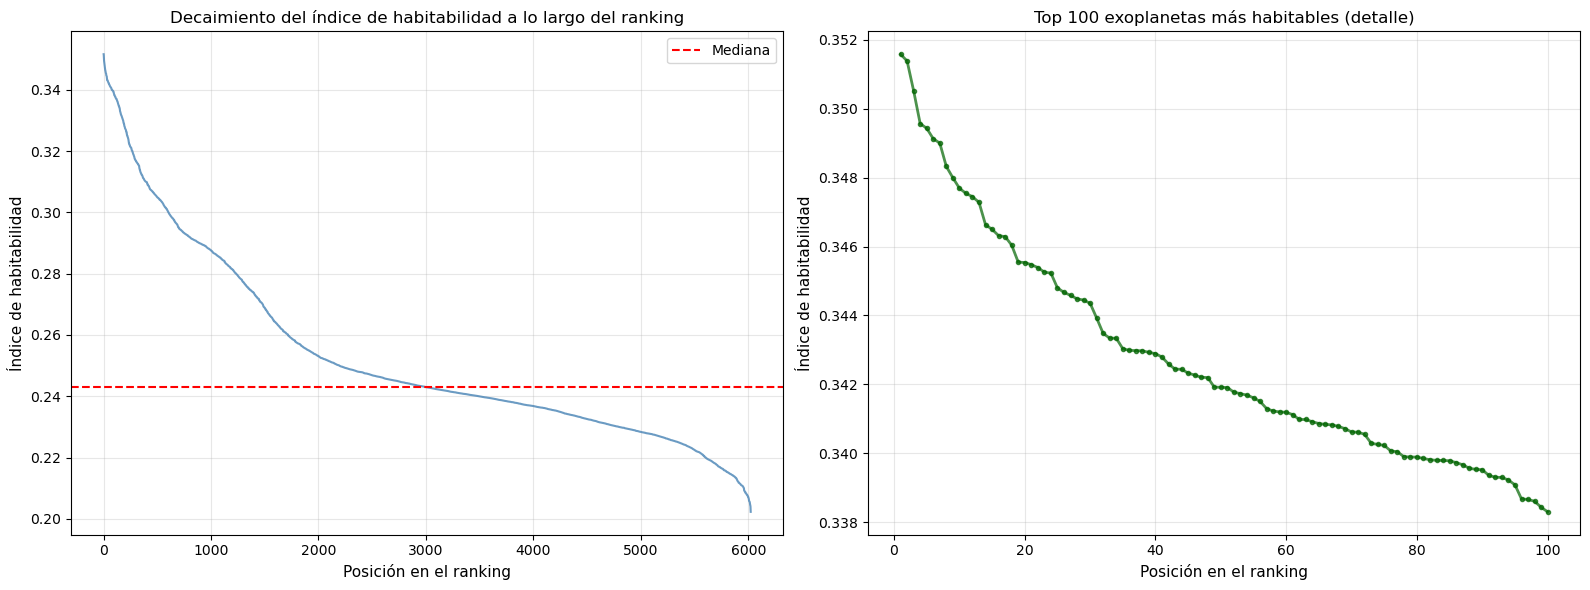

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df_exoplanetas_ranking['ranking'], df_exoplanetas_ranking['indice_habitabilidad'], 
             linewidth=1.5, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Posición en el ranking', fontsize=11)
axes[0].set_ylabel('Índice de habitabilidad', fontsize=11)
axes[0].set_title('Decaimiento del índice de habitabilidad a lo largo del ranking', fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].axhline(y=df_exoplanetas_ranking['indice_habitabilidad'].median(), 
                color='red', linestyle='--', linewidth=1.5, label='Mediana')
axes[0].legend()

top_100 = df_exoplanetas_ranking.head(100)
axes[1].plot(top_100['ranking'], top_100['indice_habitabilidad'], 
             linewidth=2, color='darkgreen', marker='o', markersize=3, alpha=0.7)
axes[1].set_xlabel('Posición en el ranking', fontsize=11)
axes[1].set_ylabel('Índice de habitabilidad', fontsize=11)
axes[1].set_title('Top 100 exoplanetas más habitables (detalle)', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_imagenes, "indice_vs_ranking.png"), dpi=300, bbox_inches="tight")
plt.show()

La distribución del ranking muestra un comportamiento **continuo y suave**, sin saltos bruscos ni cortes naturales que permitan separar grupos claramente diferenciados de planetas. Esto refuerza la idea de que el índice está funcionando como una medida **gradual de similitud física**, no como un criterio binario que divida el catálogo en clases discretas.

En la gráfica global se observa que el índice desciende desde valores en torno a **0.35** en las primeras posiciones hasta aproximadamente **0.20** en la parte final del ranking, con una mediana situada alrededor de **0.24**. Esto indica que, dentro del catálogo, la mayoría de exoplanetas se mantienen a una distancia apreciable de la referencia terrestre y que incluso los mejores candidatos siguen lejos de reproducir sus condiciones de forma global.

La ampliación del **Top 100** resulta especialmente informativa: los valores están muy comprimidos en un intervalo estrecho, aproximadamente entre **0.338 y 0.352**. Esto significa que las diferencias entre los primeros puestos existen, pero son relativamente pequeñas. Por tanto, el Top no debe leerse como una jerarquía de candidatos radicalmente distintos entre sí, sino como una zona alta del ranking en la que pequeñas variaciones multidimensionales producen cambios ordinales en la clasificación.

Esta lectura encaja con la lógica del modelo: no aparecen “planetas gemelos de la Tierra”, sino un conjunto de objetos relativamente próximos dentro de una escala exigente y continua de similitud física.

### **Análisis del índice máximo de habitabilidad obtenido**

El valor máximo del índice obtenido en el ranking se sitúa en torno a **0.35**. En una primera lectura, este valor puede parecer bajo, pero resulta coherente tanto con la formulación matemática del índice como con la exigencia física del modelo.

**1. La escala del índice es restrictiva por construcción**

Con la fórmula $H_i = \frac{1}{1 + D_i}$, un índice igual a 1 solo sería posible para un planeta idéntico a la Tierra en todas las dimensiones del modelo. En cuanto aparecen discrepancias acumuladas en varias variables, la distancia crece y el índice desciende de forma continua. Por tanto, no es esperable obtener valores cercanos a 1 salvo en casos prácticamente idénticos a la referencia terrestre.

**2. La comparación se realiza en 15 dimensiones físicas**

La distancia euclídea se calcula sobre **15 variables orbitales, planetarias y estelares**. Esto hace que incluso diferencias moderadas en varias dimensiones se acumulen en una distancia global apreciable. Alcanzar un índice alto no depende de parecerse a la Tierra en una sola propiedad, sino de mantener cercanía simultánea en muchas dimensiones a la vez.

**3. El mejor candidato sigue estando lejos en variables clave**

La interpretación del Top 1 muestra además que las mayores diferencias se concentran en el bloque orbital, especialmente en **`pl_orbper`** y **`pl_orbsmax`**, que dominan claramente la contribución a la distancia total. Esto significa que incluso el mejor planeta del ranking conserva discrepancias físicas relevantes respecto a la Tierra en variables muy influyentes del modelo.

**4. El Top del ranking está comprimido en un rango estrecho**

La gráfica del **Top 100** muestra que los mejores candidatos se agrupan aproximadamente entre **0.338 y 0.352**. Esto sugiere que el modelo distingue una zona alta del ranking, pero no identifica un pequeño conjunto de objetos extraordinariamente superiores al resto. Más bien, encuentra varios candidatos relativamente próximos entre sí dentro de una escala de similitud exigente.

**5. Qué significa realmente un máximo de ~0.35**

Dentro de este marco, un máximo de aproximadamente **0.35** no debe interpretarse como un fallo del índice, sino como una consecuencia lógica del criterio adoptado. El modelo no está diseñado para “inflar” puntuaciones ni para fabricar candidatos casi terrestres, sino para ordenar el catálogo según proximidad física relativa a la Tierra. Por ello, el resultado más honesto no es un valor alto artificial, sino una escala en la que incluso los mejores candidatos siguen mostrando diferencias importantes respecto a la referencia.

En conjunto, este resultado refuerza la lectura correcta del Top: el ranking no identifica planetas equivalentes a la Tierra, sino planetas relativamente más próximos a ella dentro del catálogo disponible y bajo un criterio físico explícito.

En conjunto, la interpretación del Top muestra que el ranking no debe entenderse como una lista de planetas equivalentes a la Tierra, sino como una ordenación relativa dentro de un marco físico restrictivo. Los primeros puestos reflejan combinaciones más cercanas a la referencia terrestre que el resto del catálogo, pero siguen acumulando diferencias relevantes en varias dimensiones del modelo.

Esta lectura es importante porque conecta el resultado final con el planteamiento inicial del proyecto: la habitabilidad no se ha tratado como una etiqueta binaria ni como una propiedad directamente observable, sino como una medida gradual de similitud física con la Tierra. El Top, por tanto, no “demuestra” habitabilidad, pero sí permite identificar de forma interpretable qué candidatos resultan más compatibles con el criterio definido.

## **16. Coherencia interna y plausibilidad empírica del índice**

Una vez construido el índice de habitabilidad y generado el ranking, conviene comprobar si su comportamiento global resulta coherente con la lógica física del modelo. Este bloque no pretende validar el índice en sentido experimental fuerte, sino someterlo a una serie de comprobaciones internas y exploratorias para ver si sus resultados son plausibles y consistentes con las decisiones adoptadas en los bloques anteriores.

La revisión se organiza en tres pasos. En primer lugar, se analiza la distribución global del índice para observar cómo se reparte la similitud física respecto a la Tierra en el catálogo. En segundo lugar, se compara el **Top 5%** del ranking con el resto del dataset en un pequeño conjunto de variables clave para ver si los exoplanetas mejor puntuados presentan, en promedio, configuraciones más próximas a la referencia terrestre. En tercer lugar, se exploran relaciones bivariantes entre el índice y varias magnitudes físicas relevantes con el fin de identificar en qué regiones del espacio de parámetros tienden a concentrarse los valores altos del indicador.

Este bloque debe leerse, por tanto, como una comprobación de **coherencia interna** y **plausibilidad empírica exploratoria**. Frente a la alternativa de aceptar el índice únicamente por su formulación matemática, aquí se examina si sus salidas muestran patrones razonables y físicamente interpretables.

=== MÉTRICAS DESCRIPTIVAS ===
Media: 0.2530
Mediana: 0.2429
Skewness: 1.1340
Curtosis: 0.6094


d:\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


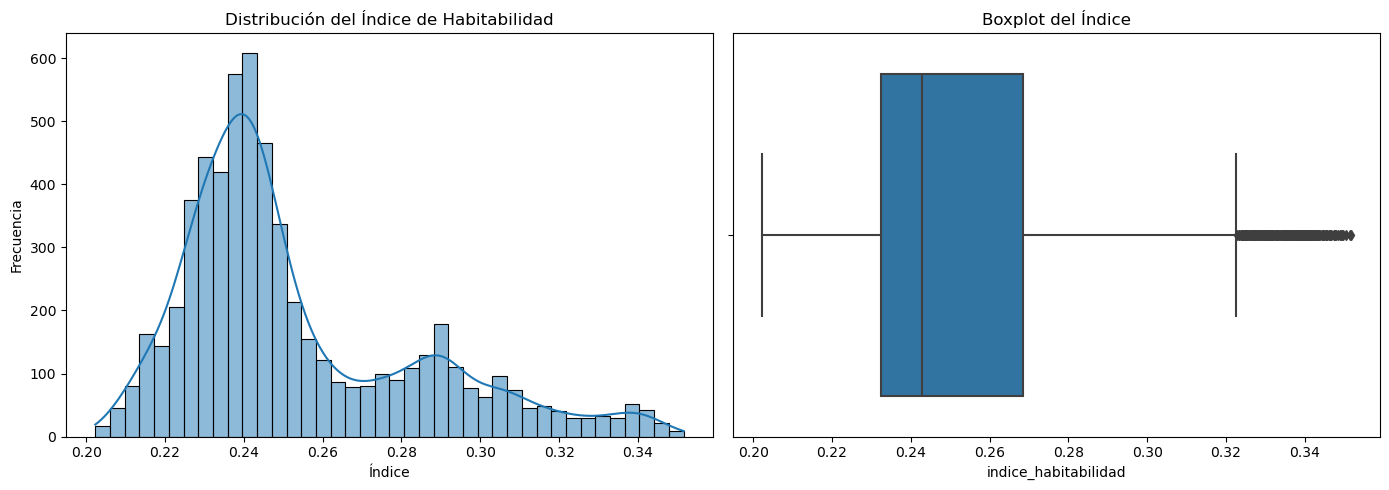


=== COMPARACIÓN TOP 5% vs RESTO ===


,Media Top,Media Resto
pl_rade,0.264883,0.274029
pl_bmasse,0.098577,0.256354
pl_orbsmax,0.626603,1.298325
st_teff,0.089606,0.179225
pl_eqt,0.041252,0.304295


In [121]:
#impirmimos algunas métricas descriptivas

indice = df_exoplanetas_ranking["indice_habitabilidad"]

media = np.mean(indice)
mediana = np.median(indice)
sk = skew(indice)
curt = kurtosis(indice)

print("=== MÉTRICAS DESCRIPTIVAS ===")
print(f"Media: {media:.4f}")
print(f"Mediana: {mediana:.4f}")
print(f"Skewness: {sk:.4f}")
print(f"Curtosis: {curt:.4f}")

# # Análisis distributivo del índice - Histograma y Boxplot

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histograma
sns.histplot(indice, bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribución del Índice de Habitabilidad")
axes[0].set_xlabel("Índice")
axes[0].set_ylabel("Frecuencia")

# Boxplot
sns.boxplot(x=indice, ax=axes[1])
axes[1].set_title("Boxplot del Índice")

plt.tight_layout()
plt.show()

# comparando el TOP vs el resto
#definimos un límite

limite = indice.quantile(0.95)

top = df_exoplanetas_ranking[
    df_exoplanetas_ranking["indice_habitabilidad"] >= limite
]

resto = df_exoplanetas_ranking[
    df_exoplanetas_ranking["indice_habitabilidad"] < limite
]

#seleccionamos las variables físicas
vars_fisicas = ["pl_rade", "pl_bmasse", "pl_orbsmax", "st_teff", "pl_eqt"]


#hacemos la comparación
comparacion = pd.DataFrame({
    "Media Top": top[vars_fisicas].mean(),
    "Media Resto": resto[vars_fisicas].mean(),
})

print("\n=== COMPARACIÓN TOP 5% vs RESTO ===")
display(comparacion)

Las métricas descriptivas y las gráficas muestran que el índice no se distribuye de forma uniforme en el catálogo. La media (**0.2530**) queda por encima de la mediana (**0.2429**) y la asimetría es positiva (**skewness = 1.1340**), lo que indica una cola hacia valores altos del índice. Esto es coherente con un escenario en el que la mayor parte de los exoplanetas se concentra en niveles bajos o intermedios de similitud con la Tierra y solo una fracción reducida alcanza puntuaciones relativamente altas.

El histograma confirma esta lectura: la mayor densidad de planetas se agrupa aproximadamente entre **0.23 y 0.25**, mientras que los valores altos aparecen como una cola menos poblada que se extiende hasta alrededor de **0.35**. El boxplot refuerza esta interpretación al mostrar observaciones altas separadas del cuerpo central de la distribución. Más que hablar de “validación”, lo que esto sugiere es que el índice genera una jerarquía exigente, en la que los valores elevados son escasos y no dominan artificialmente el catálogo.

La comparación entre el **Top 5%** y el resto también aporta una señal coherente, aunque debe leerse con cautela. En las cinco variables seleccionadas (`pl_rade`, `pl_bmasse`, `pl_orbsmax`, `st_teff` y `pl_eqt`), el grupo Top presenta medias inferiores a las del resto del dataset. Esto sugiere que los planetas mejor clasificados tienden, en promedio, a situarse en valores más contenidos de tamaño, masa, distancia orbital, temperatura estelar y temperatura de equilibrio, es decir, en regiones más cercanas a la referencia Tierra–Sol que el grueso del catálogo.

Aun así, esta comparación no debe sobredimensionarse: el corte del **Top 5%** es una decisión exploratoria razonable, pero no única ni necesariamente óptima, y el conjunto de variables comparadas es parcial. Por ello, este contraste no demuestra que el índice sea “correcto”, pero sí aporta una comprobación interna útil: el ranking no parece arbitrario y favorece configuraciones físicas más próximas a la referencia terrestre en variables relevantes del modelo.

Para complementar la lectura global del índice, se exploran ahora relaciones bivariantes entre la puntuación de habitabilidad y cuatro variables físicas particularmente relevantes dentro del modelo: `pl_rade`, `pl_insol`, `st_teff` y `pl_eqt`. El objetivo no es establecer relaciones causales estrictas ni agotar la interpretación del índice, sino observar en qué regiones de estos parámetros tienden a concentrarse los valores altos y comprobar si los patrones visuales son compatibles con la lógica física del ranking.

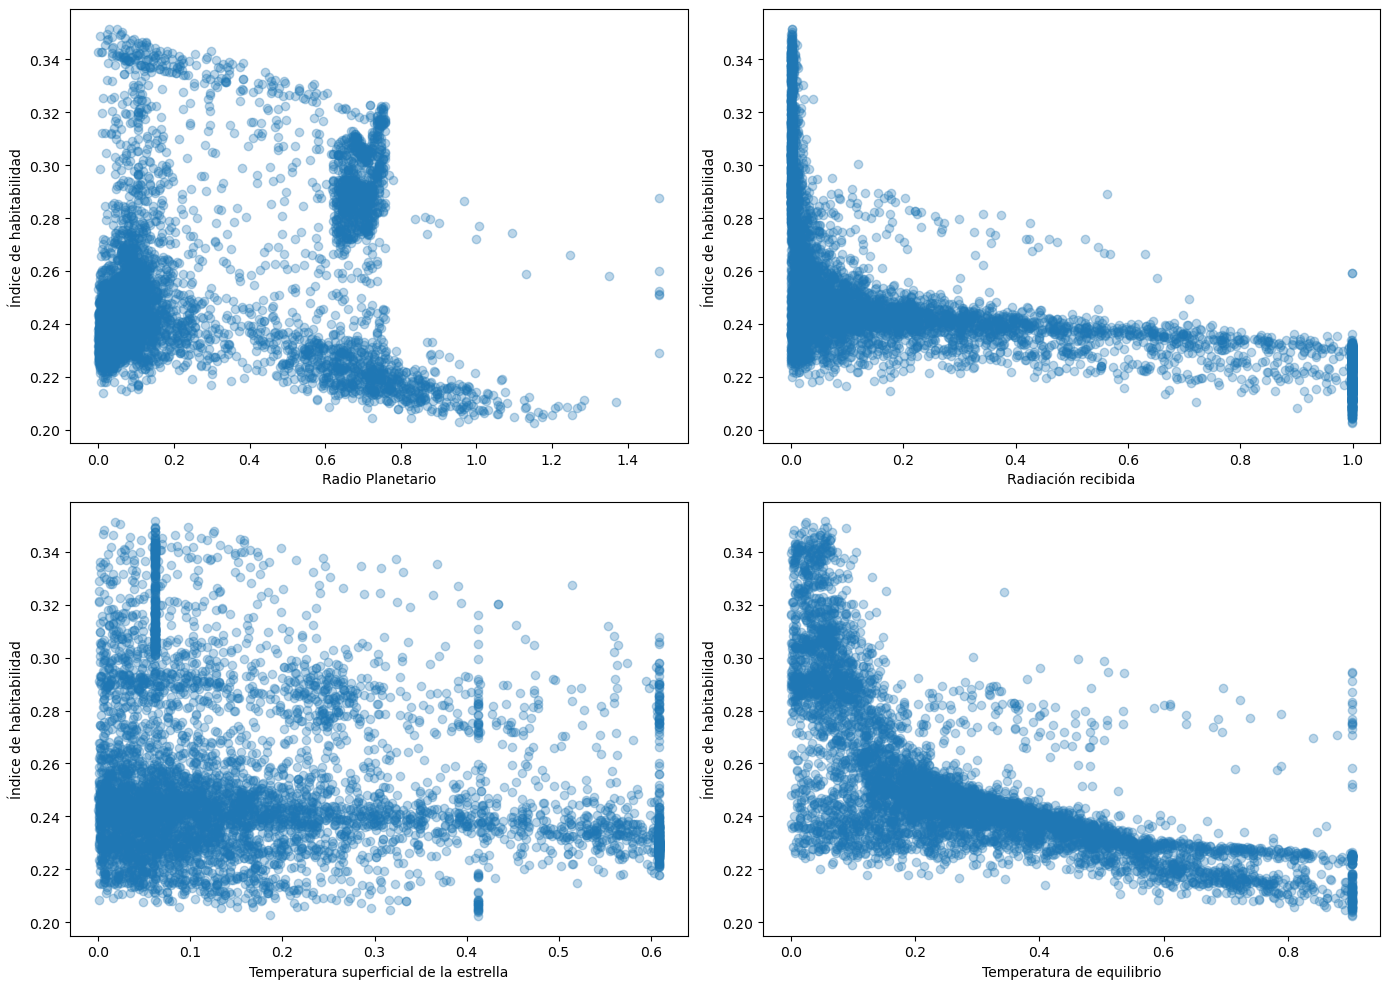

In [122]:
# Relaciones bivariantes

fig, axes = plt.subplots(2, 2, figsize=(14,10))

#índice vs rádio
axes[0,0].scatter(df_exoplanetas_ranking["pl_rade"],
                  df_exoplanetas_ranking["indice_habitabilidad"], alpha=0.3)
axes[0,0].set_xlabel("Radio Planetario")
axes[0,0].set_ylabel("Índice de habitabilidad")

#índice vs Radiación recibida
axes[0,1].scatter(df_exoplanetas_ranking["pl_insol"],
                  df_exoplanetas_ranking["indice_habitabilidad"], alpha=0.3)
axes[0,1].set_xlabel("Radiación recibida")
axes[0,1].set_ylabel("Índice de habitabilidad")

#índice vs Temperatura superficial de la estrella
axes[1,0].scatter(df_exoplanetas_ranking["st_teff"],
                  df_exoplanetas_ranking["indice_habitabilidad"], alpha=0.3)
axes[1,0].set_xlabel("Temperatura superficial de la estrella")
axes[1,0].set_ylabel("Índice de habitabilidad")

#índice vs temperatura de equilibrio 
axes[1,1].scatter(df_exoplanetas_ranking["pl_eqt"],
                  df_exoplanetas_ranking["indice_habitabilidad"], alpha=0.3)
axes[1,1].set_xlabel("Temperatura de equilibrio")
axes[1,1].set_ylabel("Índice de habitabilidad")

plt.tight_layout()
plt.show()

Los gráficos bivariantes permiten una lectura más precisa del comportamiento del índice. En **radio planetario (`pl_rade`)**, los valores altos de habitabilidad se concentran sobre todo en radios pequeños o moderados, mientras que a medida que el radio aumenta la puntuación tiende a descender. La relación no es perfectamente lineal, pero sí sugiere que los tamaños muy alejados de la escala terrestre quedan penalizados por el modelo.

En **radiación recibida (`pl_insol`)** y en **temperatura de equilibrio (`pl_eqt`)** aparece un patrón más claro: los índices más altos se concentran en valores bajos o intermedios, y la puntuación cae de forma apreciable conforme aumentan estas magnitudes. Este comportamiento es especialmente relevante porque indica que el índice penaliza de manera consistente situaciones de irradiación y temperatura muy alejadas del entorno terrestre.

La relación con la **temperatura superficial de la estrella (`st_teff`)** es más dispersa y menos nítida. Esto sugiere que esta variable sí participa en el modelo, pero no actúa por sí sola como un eje dominante del ranking. Su efecto parece más contextual, combinándose con otras dimensiones orbitales y planetarias para determinar la puntuación final.

En conjunto, estas gráficas no prueban que el índice sea “verdadero”, pero sí muestran que su comportamiento no es arbitrario: los valores altos tienden a concentrarse en regiones concretas del espacio de parámetros y el indicador penaliza progresivamente configuraciones extremas en variables clave. Esa lectura es coherente con la lógica general del proyecto, en la que la habitabilidad relativa emerge solo cuando varias dimensiones del sistema planeta–estrella se mantienen próximas a la referencia terrestre al mismo tiempo.

## **17. Análisis de sensibilidad del esquema de reescalado**

En este bloque se evalúa hasta qué punto el ranking depende del esquema de reescalado utilizado en la construcción del índice. En concreto, no se revisa aquí todo el modelo, sino un componente muy específico: el rango típico con el que se escalan las variables respecto a la Tierra.

En la versión original del índice, el escalado se construyó con percentiles **1–99**. La idea de este análisis es repetir exactamente el mismo procedimiento sustituyendo ese intervalo por un recorte más exigente, **5–95**, para comprobar si una modificación razonable del tratamiento de extremos altera de forma importante el ranking resultante.

Este diseño sí tiene sentido como chequeo de robustez local: aísla una decisión concreta del modelo y permite observar cuánto depende de ella el resultado final. Sin embargo, no debe venderse como un análisis de sensibilidad completo del índice, porque no examina otros elementos potencialmente relevantes como la selección de variables, la métrica de distancia o la fórmula final de transformación del índice.

El procedimiento consiste en reconstruir el ranking dos veces: una con percentiles **1–99** y otra con **5–95** y comparar después ambos resultados. El interés no está solo en ver si cambian algunos nombres del Top, sino en evaluar el grado de estabilidad ordinal del ranking bajo una variación razonable del esquema de reescalado.

Para realizar la comparación de forma limpia, se encapsula todo el procedimiento de construcción del ranking en una única función. Esto permite repetir exactamente la misma secuencia metodológica —reescalado, cálculo de desviaciones, distancia, índice y ordenación final— variando únicamente los percentiles utilizados en el rango típico de cada variable.

In [123]:
def construir_ranking_habitabilidad(df_final, num_cols, vector_tierra, p_low=0.01, p_high=0.99):
    # Calculamos los percentiles para cada variable numérica
    pL = df_final[num_cols].quantile(p_low)
    pH = df_final[num_cols].quantile(p_high)

    rango_tipico = pH - pL

    percentiles_df = pd.DataFrame({
        'PL': pL,
        'PH': pH,
        'Rango (PH-PL)': rango_tipico
    })

    # Aplicamos el escalado relativo respecto al vector Tierra
    df_scaled = df_final.copy()

    for col in num_cols:
        x_earth = vector_tierra[col]
        rango = rango_tipico[col]
        df_scaled[col] = (df_final[col] - x_earth) / rango

    df_deviations = df_scaled.copy()
    df_deviations[num_cols] = df_scaled[num_cols].abs()

    df_distance = df_deviations.copy()
    df_distance['distancia_tierra'] = np.sqrt((df_deviations[num_cols] ** 2).sum(axis=1))

    df_hab = df_distance.copy()
    df_hab['indice_habitabilidad'] = 1 / (1 + df_hab['distancia_tierra'])

    df_ranking = df_hab.sort_values('indice_habitabilidad', ascending=False).reset_index(drop=True)
    df_ranking.insert(0, 'ranking', range(1, len(df_ranking) + 1))

    return df_ranking, df_scaled, percentiles_df


A continuación se generan dos rankings comparables: el original, basado en percentiles **1–99**, y una versión alternativa basada en **5–95**. Como todo lo demás permanece constante, cualquier diferencia observada entre ambas salidas podrá atribuirse al cambio en el esquema de reescalado.

In [124]:
#construimos para la comparación el índice con 99
ranking_01_99, scaled_01_99, percs_01_99 = construir_ranking_habitabilidad(
    df_final=df_final,
    num_cols=num_cols,
    vector_tierra=vector_tierra,
    p_low=0.01,
    p_high=0.99
)

# y con 95
ranking_05_95, scaled_05_95, percs_05_95 = construir_ranking_habitabilidad(
    df_final=df_final,
    num_cols=num_cols,
    vector_tierra=vector_tierra,
    p_low=0.05,
    p_high=0.95
)


La primera comparación se centra en la estabilidad de los primeros puestos. En lugar de revisar todo el ranking de una vez, se comprueba cuántos planetas coinciden en el **Top 5** y en el **Top 10**, y cuáles entran o salen al modificar el recorte de percentiles.

In [125]:
#vemos las comparativas y los planetas que se hayan podido modificar
top5_a = set(ranking_01_99.head(5)["pl_name"])
top5_b = set(ranking_05_95.head(5)["pl_name"])

top10_a = set(ranking_01_99.head(10)["pl_name"])
top10_b = set(ranking_05_95.head(10)["pl_name"])

print("Coincidencia Top 5:", len(top5_a & top5_b), "de 5")
print("Coincidencia Top 10:", len(top10_a & top10_b), "de 10")

print("\nTop 5 comunes:", sorted(list(top5_a & top5_b)))
print("En Top 5 (1–99) pero no en (5–95):", sorted(list(top5_a - top5_b)))
print("En Top 5 (5–95) pero no en (1–99):", sorted(list(top5_b - top5_a)))


Coincidencia Top 5: 4 de 5
Coincidencia Top 10: 10 de 10

Top 5 comunes: ['KMT-2021-BLG-0912L b', 'Kepler-1040 b', 'Kepler-1606 b', 'Kepler-1638 b']
En Top 5 (1–99) pero no en (5–95): ['OGLE-2019-BLG-1053L b']
En Top 5 (5–95) pero no en (1–99): ['KMT-2019-BLG-1806L b']


Este primer contraste muestra una estabilidad alta del núcleo del ranking. El **Top 10 se conserva íntegro** al pasar de **1–99** a **5–95**, y en el **Top 5** solo se produce una sustitución puntual entre dos planetas. Esto indica que el cambio de reescalado no reorganiza profundamente los candidatos principales, aunque sí introduce pequeñas variaciones en los puestos más altos.

Este resultado ya permite una primera lectura importante: el ranking no parece depender de forma crítica de esta decisión concreta de percentiles, aunque el orden fino de los primeros puestos sí muestra cierta sensibilidad local.

Además de la coincidencia por conjuntos, conviene observar los cambios concretos de posición en los primeros puestos. Para ello se construye una tabla comparativa que permite ver, planeta a planeta, cómo cambian el ranking y el valor del índice al pasar de **1–99** a **5–95**.

In [126]:
#visualizamos en una tabla para ver las principales métricas
rA = ranking_01_99[["pl_name", "ranking", "indice_habitabilidad"]].rename(
    columns={"ranking":"rank_01_99", "indice_habitabilidad":"idx_01_99"}
)
rB = ranking_05_95[["pl_name", "ranking", "indice_habitabilidad"]].rename(
    columns={"ranking":"rank_05_95", "indice_habitabilidad":"idx_05_95"}
)

cmp = rA.merge(rB, on="pl_name", how="inner")
cmp["delta_rank"] = cmp["rank_05_95"] - cmp["rank_01_99"]

cmp_top = cmp.sort_values("rank_01_99").head(30)
cmp_top[["pl_name", "rank_01_99", "rank_05_95", "delta_rank", "idx_01_99", "idx_05_95"]]


,pl_name,rank_01_99,rank_05_95,delta_rank,idx_01_99,idx_05_95
0,KMT-2021-BLG-0912L b,1,2,1,0.351586,0.349257
1,Kepler-1638 b,2,1,-1,0.351389,0.349337
2,Kepler-1040 b,3,3,0,0.350523,0.348440
3,Kepler-1606 b,4,4,0,0.349571,0.347043
4,OGLE-2019-BLG-1053L b,5,6,1,0.349436,0.346517
5,KMT-2019-BLG-1806L b,6,5,-1,0.349131,0.346575
6,OGLE-2016-BLG-0007L b,7,7,0,0.349005,0.345948
7,Kepler-452 b,8,10,2,0.348327,0.344734
8,Kepler-1090 b,9,9,0,0.347998,0.345143
9,KMT-2018-BLG-0029L b,10,8,-2,0.347695,0.345207


Este primer contraste muestra una estabilidad alta del núcleo del ranking. El **Top 10 se conserva íntegro** al pasar de **1–99** a **5–95**, y en el **Top 5** solo se produce una sustitución puntual entre dos planetas. Esto indica que el cambio de reescalado no reorganiza profundamente los candidatos principales, aunque sí introduce pequeñas variaciones en los puestos más altos.

Este resultado ya permite una primera lectura importante: el ranking no parece depender de forma crítica de esta decisión concreta de percentiles, aunque el orden fino de los primeros puestos sí muestra cierta sensibilidad local.

Después de comparar coincidencias y cambios de posición, conviene comprobar si el cambio de percentiles altera también la composición del **Top 10**. Esta verificación permite distinguir entre dos situaciones distintas: que el ranking cambie solo en el orden interno de los mismos candidatos, o que entren y salgan planetas del grupo principal al modificar el esquema de reescalado.

In [127]:

top10_only_a = top10_a - top10_b
top10_only_b = top10_b - top10_a

print("Desaparecen del Top 10 al pasar 1–99 -> 5–95:", sorted(list(top10_only_a)))
print("Aparecen nuevos en el Top 10 al pasar 1–99 -> 5–95:", sorted(list(top10_only_b)))


Desaparecen del Top 10 al pasar 1–99 -> 5–95: []
Aparecen nuevos en el Top 10 al pasar 1–99 -> 5–95: []


El resultado muestra que el cambio de percentiles **no altera la composición del Top 10**: no desaparece ningún planeta ni entra ningún candidato nuevo al pasar de **1–99** a **5–95**. Esto refuerza la idea de que la sensibilidad observada hasta ahora afecta sobre todo al **orden interno** de los primeros puestos, pero no al núcleo principal de planetas mejor clasificados.

Esta comprobación es importante porque confirma que la estabilidad del ranking no se limita a una alta coincidencia agregada, sino que también se mantiene cuando se examina directamente la pertenencia al grupo de candidatos más relevantes.

In [128]:
#comprobamos la correlación entre los índices con la modificación del percentil
corr_spearman = spearmanr(cmp["rank_01_99"], cmp["rank_05_95"]).correlation
print("Spearman (rankings):", round(corr_spearman, 4))


Spearman (rankings): 0.9971


La correlación de Spearman entre ambos rankings (**0.9971**) resume de forma muy clara la estabilidad observada en las comparaciones anteriores: el orden relativo entre planetas apenas cambia cuando se modifica el recorte de percentiles de **1–99** a **5–95**.

Si se integran todos los resultados del bloque, la conclusión es consistente. El **Top 10 se conserva completo**, el **Top 5 solo cambia en un caso**, la tabla comparativa muestra desplazamientos pequeños y la correlación ordinal es casi perfecta. En conjunto, esto indica que el índice es **robusto frente a esta variación concreta del esquema de reescalado**.

Aun así, esta conclusión debe formularse con precisión. Lo que este bloque respalda no es una robustez global del modelo en todos sus componentes, sino una robustez **local** frente a una modificación razonable de los percentiles usados en el escalado. Es decir, el índice parece estable ante el paso de **1–99** a **5–95**, pero eso no sustituye otros posibles análisis de sensibilidad sobre variables, métricas de distancia o formulaciones alternativas del índice.

## **18. Conclusiones**

Este trabajo no ha pretendido resolver de forma definitiva el problema de la habitabilidad exoplanetaria, sino construir un marco cuantitativo, interpretable y metodológicamente coherente para aproximarse a él desde los datos disponibles. Las conclusiones, por tanto, no deben leerse como una validación de vida potencial ni como una certificación física de habitabilidad, sino como una síntesis de lo que el modelo permite afirmar de manera razonable sobre la **similitud relativa con la Tierra** dentro del catálogo analizado.

A partir del índice construido, del ranking obtenido y de los análisis posteriores, es posible extraer conclusiones sobre cuatro planos distintos: el **enfoque metodológico adoptado**, el **comportamiento global del índice**, la **lectura física del Top del ranking** y el **grado de robustez del resultado** frente a cambios razonables en decisiones concretas del modelo. A ello se añade una reflexión final sobre las limitaciones del enfoque y sobre el alcance real de las afirmaciones que este proyecto permite sostener.

### 1. Síntesis del enfoque

El trabajo ha desarrollado un índice cuantitativo de similitud con la Tierra a partir de un conjunto de variables orbitales, planetarias y estelares, seleccionadas por criterio de dominio y tratadas con el objetivo de preservar su interpretación física dentro del modelo. La lógica general del proyecto no ha sido predictiva ni clasificatoria, sino comparativa: dado que no existe una etiqueta observable de “habitabilidad real”, el problema se ha formulado como una medición de proximidad física relativa al sistema Tierra–Sol.

Esta decisión metodológica ha condicionado todo el desarrollo posterior. La selección de variables se ha realizado priorizando trazabilidad física frente a reducciones automáticas de dimensionalidad; la imputación de faltantes se ha abordado de forma diferenciada según el tipo de variable y su relación con otras magnitudes; el tratamiento de valores extremos se ha diseñado para estabilizar el espacio de trabajo sin destruir su estructura; y la agregación final se ha construido sobre un escalado relativo respecto a la Tierra, una distancia euclídea y una transformación continua a índice acotado.

En conjunto, el proyecto no ha buscado maximizar sofisticación algorítmica, sino construir un procedimiento coherente, explicable y reproducible en cada una de sus decisiones. Esa es, en último término, la principal conclusión metodológica del trabajo: el valor del modelo no reside solo en el ranking final, sino en que cada paso del proceso mantiene una justificación explícita dentro del problema planteado.

### 2. Comportamiento global del índice

El índice resultante muestra un comportamiento distributivo coherente con la exigencia del criterio adoptado. La mayor parte del catálogo se concentra en valores relativamente bajos o intermedios de similitud, mientras que solo una fracción reducida alcanza puntuaciones altas. Las métricas descriptivas y las visualizaciones realizadas muestran una distribución con asimetría positiva, con media superior a la mediana y una cola menos poblada hacia los valores altos, lo que indica que los candidatos relativamente más parecidos a la Tierra son escasos dentro del conjunto analizado.

Este resultado es importante porque descarta dos escenarios problemáticos. Por un lado, no aparece una proliferación artificial de planetas con puntuaciones muy elevadas, algo que habría puesto en cuestión la exigencia del índice. Por otro, el comportamiento no es caótico ni errático: la distribución conserva una estructura legible y jerarquizable, lo que permite interpretar el ranking como una salida ordenada y no como una simple dispersión de puntuaciones sin criterio claro.

En otras palabras, el índice parece comportarse como cabría esperar de una medida restrictiva de similitud multidimensional con la Tierra: la cercanía alta existe, pero se concentra en pocos objetos y dentro de un rango relativamente estrecho de valores.

### 3. Patrones observados en el Top del ranking

El ranking identifica un conjunto reducido de exoplanetas relativamente más próximos a la referencia terrestre, entre los que aparecen nombres como KMT-2021-BLG-0912L b, Kepler-1638 b, Kepler-1040 b o Kepler-1606 b. Sin embargo, la interpretación del Top muestra con claridad que estos candidatos no deben leerse como “análogos terrestres”, sino como los objetos que, dentro del catálogo disponible y bajo el criterio definido, minimizan mejor la distancia global respecto al vector Tierra.

El análisis detallado del planeta mejor clasificado refuerza esta idea. Su buena posición no proviene de una coincidencia casi perfecta con la Tierra, sino de una combinación de similitudes parciales con discrepancias todavía importantes en variables clave. En particular, las mayores contribuciones a la distancia global se concentran en el bloque orbital, especialmente en pl_orbper y pl_orbsmax, lo que muestra que incluso el mejor candidato conserva diferencias relevantes respecto a la referencia terrestre en dimensiones muy influyentes del modelo.

Además, la visualización del decaimiento del ranking y la inspección del Top 100 muestran que los mejores candidatos están muy comprimidos en un intervalo estrecho de índices. Esto significa que el modelo distingue una zona alta del ranking, pero no identifica unos pocos objetos radicalmente superiores al resto. El Top debe interpretarse, por tanto, como un conjunto de candidatos relativamente próximos entre sí dentro de una escala exigente de similitud física.

### 4. Estabilidad frente al recorte de percentiles

El análisis de sensibilidad realizado sobre el esquema de reescalado muestra una estabilidad muy alta del ranking frente al paso de percentiles 1–99 a 5–95. El Top 10 se conserva íntegro, el Top 5 solo cambia en un caso, los desplazamientos observados en los primeros puestos son pequeños y la correlación de Spearman entre ambos rankings alcanza un valor muy próximo a 1 (0.9971). Todo ello indica que la estructura principal del ranking no depende críticamente de esta decisión concreta del tratamiento de extremos.

Esta conclusión debe formularse con precisión. Lo que el bloque de sensibilidad respalda es una estabilidad local del modelo frente a una modificación razonable del esquema de reescalado, no una robustez absoluta frente a cualquier cambio metodológico imaginable. Aun así, el resultado es importante, porque muestra que el ranking no se reorganiza profundamente cuando se modifica una decisión técnica relevante del pipeline.

En términos de interpretación, esto refuerza la confianza en que el índice no está produciendo sus resultados únicamente por una calibración accidental del recorte elegido, sino por una estructura más estable del espacio de similitud construido.

### 5. Lectura conceptual del resultado

Una de las conclusiones más importantes del proyecto es que el valor máximo del índice —en torno a 0.35— no debe interpretarse como una debilidad del modelo, sino como una consecuencia directa de su exigencia. Con la formulación adoptada, un índice cercano a 1 solo sería alcanzable por un planeta prácticamente idéntico a la Tierra en todas las dimensiones consideradas, algo extremadamente improbable cuando la comparación se realiza simultáneamente sobre múltiples variables orbitales, planetarias y estelares.

La baja densidad de objetos con puntuaciones altas no es, por tanto, un fallo del índice, sino una expresión de la dificultad estructural de reunir a la vez muchas condiciones próximas al sistema terrestre. El modelo no está diseñado para “inflar” valores ni para fabricar candidatos casi terrestres, sino para ordenar de manera honesta qué configuraciones aparecen relativamente más próximas dentro del catálogo disponible.

Desde este punto de vista, el resultado más valioso del trabajo no es encontrar un planeta “habitable”, sino mostrar que la similitud física con la Tierra, entendida como alineación simultánea de múltiples dimensiones relevantes, constituye una región muy reducida del espacio de parámetros.

### 6. Limitaciones del modelo

A pesar de su coherencia interna, el modelo presenta limitaciones importantes que deben reconocerse explícitamente.

**Primera**, la habitabilidad se ha aproximado mediante similitud estructural con la Tierra, no mediante procesos físicos completos. El índice no incorpora dinámica atmosférica, geoquímica, actividad estelar detallada, composición atmosférica real, campos magnéticos ni otros mecanismos que serían decisivos en una evaluación física exhaustiva.

**Segunda**, aunque se ha trabajado para preservar la interpretación física de las variables, la agregación mediante distancia euclídea sigue imponiendo una determinada forma de combinar discrepancias. Eso implica aceptar una geometría concreta del problema y asumir que las diferencias en dimensiones distintas pueden integrarse dentro de una misma medida global.

**Tercera**, el catálogo está condicionado por sesgos observacionales muy fuertes. Los exoplanetas disponibles no constituyen una muestra neutra del universo, sino el resultado de los métodos de detección actualmente dominantes. Por ello, parte de los patrones observados en el ranking refleja también la estructura del sesgo de observación y no solo la física intrínseca de los sistemas.

**Cuarta**, el tratamiento de incertidumbre sigue siendo limitado. Aunque el modelo ha sido cuidadoso en la gestión de faltantes, extremos y estabilidad del ranking, no incorpora una propagación formal del error de medida ni intervalos de confianza sobre el índice resultante.

**Quinta**, la interpretación del índice es necesariamente relativa. El resultado permite ordenar exoplanetas por proximidad estructural a la Tierra dentro del marco definido, pero no traducir esa puntuación en probabilidad de vida ni en habitabilidad confirmada.

Estas limitaciones no invalidan el trabajo, pero sí delimitan con claridad el alcance de sus conclusiones.

### 7. Conclusión final sintética

En conjunto, el proyecto ha construido una medida de similitud con la Tierra metodológicamente coherente, físicamente interpretable y estable frente a variaciones razonables en algunas decisiones técnicas del modelo, como el esquema de percentiles utilizado en el reescalado. El índice no resuelve el problema de la habitabilidad exoplanetaria en sentido fuerte, pero sí ofrece una herramienta cuantitativa sólida para ordenar, comparar e interpretar exoplanetas dentro de un marco explícito de referencia terrestre.

La principal aportación del trabajo no es haber identificado un planeta “habitable”, sino haber mostrado que el problema puede abordarse de forma estructurada: seleccionando variables con sentido físico, justificando cada transformación del dato, construyendo una referencia clara y cerrando el proceso con un ranking cuya lógica puede leerse, explicarse y someterse a comprobaciones de coherencia.

Por eso, la conclusión más importante del proyecto es doble. En el plano técnico, el índice funciona como una medida razonable de similitud relativa con la Tierra. En el plano metodológico, el trabajo demuestra una forma de hacer problem framing aplicada a datos complejos: no limitarse a calcular una puntuación, sino diseñar un criterio, defenderlo, tensionarlo con los resultados y explicarlo con rigor hasta el final.

## **19. Posibles mejoras y líneas de ampliación**

El modelo desarrollado en este trabajo cumple su objetivo principal: construir un índice interpretable de similitud relativa con la Tierra a partir de variables físicas observables y generar un ranking coherente dentro de ese marco. Sin embargo, precisamente porque el enfoque ha sido explícito y trazable, también permite identificar con claridad qué partes podrían mejorarse, tensionarse o ampliarse en una versión posterior del proyecto.

Las mejoras posibles no son todas del mismo tipo. Algunas permitirían **refinar el modelo sin cambiar su filosofía general**; otras servirían para **poner a prueba la robustez** de las decisiones tomadas; y otras abrirían la puerta a una **versión científicamente más ambiciosa** del trabajo. Esta distinción es importante, porque no todas las líneas de ampliación tienen el mismo coste ni responden a la misma pregunta.


### 1. Mejoras dentro del mismo marco metodológico

La primera familia de mejoras consiste en fortalecer el modelo actual sin abandonar su planteamiento central de similitud relativa con la Tierra.

Una mejora clara sería profundizar en el análisis de **redundancia entre variables** antes de la agregación final. A lo largo del trabajo ya se ha reconocido que algunas magnitudes están físicamente relacionadas —por ejemplo, variables orbitales o determinadas propiedades estelares—, pero una evaluación más sistemática permitiría cuantificar hasta qué punto ciertas dimensiones están aportando información parcialmente solapada dentro de la distancia global.

Otra mejora natural sería ampliar el estudio de **sensibilidad local**. En este proyecto se ha analizado la estabilidad del ranking frente al cambio de percentiles **1–99** a **5–95**, y el resultado ha sido favorable. Pero ese análisis podría extenderse a otras decisiones concretas: el tratamiento de outliers, el criterio de imputación en variables específicas, la exclusión o inclusión de determinadas columnas o incluso la sustitución puntual de una variable por otra físicamente próxima.

Estas ampliaciones no cambiarían la lógica del modelo, pero sí reforzarían su capacidad de defenderse frente a objeciones metodológicas razonables.

Además, sería especialmente interesante realizar un análisis de influencia estructural de cada bloque de variables. Esto consistiría en recalcular el índice eliminando temporalmente conjuntos completos de variables (por ejemplo, solo variables orbitales, solo planetarias o solo estelares) y observar cómo cambia el ranking. Este procedimiento permitiría identificar qué dimensiones del modelo tienen mayor capacidad de modificar la priorización final y cuáles actúan como factores secundarios. Desde el punto de vista metodológico, este análisis permitiría entender no solo el resultado del modelo, sino también su estructura interna.



### 2. Tratamiento explícito de incertidumbre observacional

Una limitación importante del trabajo es que las variables se han tratado como valores puntuales, cuando en realidad muchas de ellas proceden de estimaciones astronómicas con incertidumbre asociada. Una línea de ampliación especialmente valiosa sería incorporar esta dimensión de forma explícita.

La opción más directa no tendría por qué ser excesivamente compleja: podrían utilizarse intervalos de error, simulaciones Monte Carlo simples o perturbaciones repetidas de los valores observados para estudiar cómo varía el ranking cuando las magnitudes de entrada se mueven dentro de sus márgenes plausibles. Esto permitiría responder a una pregunta que ahora solo queda planteada de forma implícita: **qué parte del ranking es estructural y qué parte depende del error de medida**.

Desde el punto de vista del proyecto, esta mejora sería muy potente porque trasladaría el trabajo desde una lógica puramente determinista hacia una lectura más realista de los datos astronómicos, sin necesidad de abandonar el marco general del índice.

Más allá de observar cómo cambia el valor del índice, sería especialmente relevante analizar cómo cambia la posición relativa en el ranking cuando se introducen perturbaciones dentro de los márgenes de error observacional. Esto permitiría distinguir entre exoplanetas cuya posición es muy estable frente a la incertidumbre y otros cuya posición depende fuertemente de pequeñas variaciones en los datos. De este modo, el ranking podría complementarse con una medida de estabilidad asociada a cada candidato.


### 3. Comparación con formulaciones alternativas del índice

Otra línea de ampliación relevante consistiría en comparar el modelo actual con **versiones alternativas construidas sobre supuestos distintos**, no para sustituirlo necesariamente, sino para entender mejor qué parte del resultado depende de cada decisión metodológica.

Aquí hay varias posibilidades concretas:

- comparar la distancia euclídea con otras métricas de agregación como **Manhattan** u otras distancias robustas;
- estudiar el efecto de introducir **ponderaciones** entre variables, siempre que esas ponderaciones se justifiquen físicamente y no de forma arbitraria;
- probar otras transformaciones finales del índice distintas de $H_i = \frac{1}{1 + D_i}$;
- estudiar qué ocurre si la agregación se realiza por bloques (órbita, planeta, estrella) antes de la combinación global.

Estas comparaciones serían muy valiosas por una razón metodológica: obligarían a mostrar que el ranking no solo funciona con la formulación elegida, sino también qué cambia y qué se mantiene cuando se tensiona el diseño del modelo. Es decir, permitirían pasar de un índice “razonable” a un índice “comparado críticamente con sus alternativas”.

El objetivo de estas comparaciones no sería encontrar una única formulación “correcta”, sino analizar qué candidatos aparecen de forma consistente en distintas formulaciones razonables del índice. Los exoplanetas que se mantienen en posiciones altas bajo múltiples definiciones del modelo podrían considerarse candidatos estructuralmente robustos dentro del marco de similitud con la Tierra, mientras que aquellos cuya posición cambia significativamente revelarían una mayor dependencia de decisiones metodológicas concretas.



### 4. Comparación con enfoques externos y con la literatura

Una ampliación especialmente interesante sería comparar los resultados de este proyecto con otros enfoques ya existentes en la literatura o en trabajos previos de priorización de exoplanetas. No se trataría de adoptar sin más otro índice, sino de situar el modelo dentro de un contexto más amplio.

Por ejemplo, podría analizarse hasta qué punto el ranking obtenido coincide o diverge de métricas ya conocidas de **similitud terrestre** o de listados de candidatos habitables frecuentemente citados en la literatura. El objetivo aquí no sería validar el modelo por coincidencia, sino responder a preguntas más finas:

- qué candidatos aparecen de forma consistente en distintos marcos;
- cuáles suben o bajan específicamente en este modelo;
- y qué decisiones metodológicas explican esas diferencias.

Esta comparación aportaría mucho valor porque convertiría el proyecto en algo más que un ejercicio autónomo: lo colocaría en diálogo explícito con otros criterios de priorización y permitiría defender mejor cuál es la aportación específica del enfoque construido aquí.


### 5. Enriquecimiento del espacio de variables

El modelo actual ha trabajado con un conjunto de **15 variables físicas** seleccionadas por su trazabilidad e interpretabilidad. Esa decisión ha sido adecuada para construir una primera versión sólida del índice, pero también deja abierta una línea de crecimiento natural: enriquecer el espacio de variables.

Las ampliaciones más interesantes no serían necesariamente “meter más columnas”, sino incorporar magnitudes que añadan información físicamente relevante hoy ausente del modelo. Entre las posibilidades más claras estarían:

- indicadores de **actividad estelar** o variabilidad de la estrella anfitriona;
- información más fina sobre **composición planetaria** o estructura interna;
- variables atmosféricas, cuando estén disponibles;
- proxies adicionales relacionados con estabilidad orbital o entorno radiativo.

Eso sí, esta ampliación exigiría mantener el mismo nivel de rigor que en la versión actual: no añadir variables por acumulación, sino justificar por qué mejoran realmente la definición de habitabilidad relativa y cómo se integran sin romper la coherencia del índice.



### 6. Lectura probabilística o por escenarios

Una ampliación más ambiciosa sería abandonar parcialmente la lógica de un único ranking fijo y pasar a una lectura por **escenarios** o incluso a una formulación **probabilística**.

Por ejemplo, el modelo podría generar varios rankings según diferentes supuestos razonables:
- escenario conservador,
- escenario con mayor peso planetario,
- escenario con mayor tolerancia a extremos,
- escenario con distinta definición del rango típico.

Esto tendría dos ventajas. Primero, mostraría que la priorización de exoplanetas no depende de una sola “verdad numérica”, sino de una familia de supuestos interpretables. Segundo, permitiría identificar qué candidatos son robustos en casi cualquier escenario y cuáles dependen mucho de decisiones concretas del modelo.

Desde la perspectiva de problem framing, esta sería una ampliación especialmente rica, porque convertiría el proyecto en una herramienta no solo de ordenación, sino también de exploración estructurada de hipótesis.



### 7. Valor del proyecto como plataforma metodológica

Más allá de sus posibles extensiones técnicas, una de las principales fortalezas de este trabajo es que ya funciona como una **plataforma metodológica reusable**. El pipeline está suficientemente estructurado como para permitir nuevas comparaciones, nuevas decisiones de modelado y nuevas pruebas de robustez sin tener que reconstruir el proyecto desde cero.

Esa es, de hecho, una de las líneas de ampliación más valiosas: no pensar el proyecto como un índice cerrado, sino como una base analítica sobre la que se pueden seguir formulando preguntas. Por ejemplo:

- ¿qué parte del ranking depende más de la selección de variables que de la métrica de distancia?
- ¿qué candidatos son robustos a casi cualquier modificación razonable del pipeline?
- ¿qué bloques del modelo generan más sensibilidad?
- ¿qué diferencias aparecen al compararlo con otros criterios publicados?

Planteado así, el proyecto deja de ser solo un resultado y pasa a ser también un marco de experimentación.

### 8. Validación estructural del índice

Una línea de ampliación especialmente relevante consistiría en realizar una validación estructural del índice. Esto implicaría analizar cómo se comporta el ranking cuando se modifican de forma controlada distintos elementos del modelo: la métrica de distancia, el esquema de escalado, el conjunto de variables o la forma de agregación.

Este tipo de análisis permitiría responder a una pregunta metodológica fundamental: qué parte del resultado depende de los datos y qué parte depende del diseño del modelo. Si los candidatos mejor posicionados se mantienen relativamente estables bajo distintas configuraciones razonables, el índice podría considerarse estructuralmente estable dentro del marco adoptado.

Este enfoque transformaría el proyecto de la construcción de un único ranking a la construcción de un marco de análisis de rankings, donde el interés no se centra únicamente en la posición final, sino en la estabilidad y coherencia de esa posición bajo distintos supuestos metodológicos.

### Conclusión del bloque

Las posibles mejoras del trabajo no apuntan a una única carencia, sino a una dirección general de crecimiento: pasar de un índice bien planteado y coherente a un modelo progresivamente más contrastado, más comparado y más rico en información. Algunas de estas ampliaciones son relativamente accesibles y fortalecerían mucho la solidez metodológica del proyecto; otras exigirían más datos, más tiempo o un cambio de escala analítica.

En cualquier caso, la principal conclusión de este apartado es que el proyecto no se agota en su versión actual. Precisamente porque el framing del problema ha sido explícito, el trabajo permite identificar con claridad qué decisiones podrían tensionarse, qué partes podrían refinarse y qué nuevas preguntas puede soportar una versión posterior del modelo.

## Anexo: Exportacion de Resultados

En este bloque se generan y guardan algunos outputs finales del proyecto destinados a su uso fuera del cuaderno, concretamente en la aplicación de Streamlit y en la página web del portfolio.

Se exportan, por un lado, una tabla con el Top 10 de exoplanetas mejor posicionados. Además, se guarda el dataset final con el ranking completo e índice de habitabilidad, que servirá como fuente de datos para la aplicación interactiva.

Este bloque no forma parte del análisis principal del TFM, sino del proceso de empaquetado de resultados para su reutilización en otros componentes del proyecto.

In [129]:

df_top10_web = df_exoplanetas_ranking[columnas_ranking].head(10)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

tabla = ax.table(
    cellText=df_top10_web.values,
    colLabels=df_top10_web.columns,
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.5)

plt.tight_layout()
plt.savefig(os.path.join(ruta_imagenes, "top10.png"), dpi=300, bbox_inches="tight")
plt.close()


df_exoplanetas_ranking.to_csv(
    os.path.join(ruta_datasets, "exoplanetas_final.csv"),
    index=False
)

print("Exportación completada:")
print("- top10.png guardado en Images")
print("- top20.png guardado en Images")
print("- exoplanetas_final.csv guardado en DataSets")

Exportación completada:
- top10.png guardado en Images
- top20.png guardado en Images
- exoplanetas_final.csv guardado en DataSets
